<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/VIB_ELAPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TRAINING LIGHTGBM

In [ ]:
# ==========================================================
# LIGHTGBM WITH 5 SAMPLING STRATEGIES
# TARGET: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

from lightgbm import LGBMClassifier

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(
    "final_dataset_no_auto_job.csv",
    low_memory=False
)

df.columns = df.columns.str.strip()

# =========================
# TARGET AND ID
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# X, y
y = df[target_col].astype(int)

X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# =========================
# FIX MIXED DATA TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].astype(str)

# =========================
# NUMERIC / CATEGORICAL COLUMNS
# =========================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

# =========================
# PREPROCESSOR
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop"
)

# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# SAMPLING METHODS
# =========================
sampling_methods = {
    "No Sampling": None,
    "ROS": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

# =========================
# LIGHTGBM MODEL
# =========================
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# =========================
# CROSS VALIDATION
# =========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc",
    "accuracy": "accuracy"
}

results = []

# =========================
# TRAINING AND EVALUATION
# =========================
for sampling_name, sampler in sampling_methods.items():

    steps = [("preprocess", preprocessor)]

    if sampler is not None:
        steps.append(("sampler", sampler))

    steps.append(("model", lgbm_model))

    pipeline = Pipeline(steps=steps)

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Sampling": sampling_name,
        "Model": "LightGBM",
        "Recall": round(cv_scores["test_recall"].mean(), 4),
        "F1-score": round(cv_scores["test_f1"].mean(), 4),
        "AUC": round(cv_scores["test_auc"].mean(), 4),
        "Accuracy": round(cv_scores["test_accuracy"].mean(), 4),
        "Std (CV AUC)": round(cv_scores["test_auc"].std(), 4),
        "Test Recall": round(recall_score(y_test, y_pred), 4),
        "Test F1-score": round(f1_score(y_test, y_pred), 4),
        "Test AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 4)
    })

# =========================
# RESULT TABLE
# =========================
result_df = pd.DataFrame(results)

print(result_df)

result_df.to_csv("lightgbm_5_sampling_results.csv", index=False)

print("\nSaved: lightgbm_5_sampling_results.csv")


Numeric columns: 14
Categorical columns: 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

           Sampling     Model  Recall  F1-score     AUC  Accuracy  \
0       No Sampling  LightGBM  0.6600    0.6806  0.9507    0.9042   
1               ROS  LightGBM  0.9267    0.6856  0.9503    0.8685   
2             SMOTE  LightGBM  0.8540    0.6932  0.9462    0.8831   
3  Borderline-SMOTE  LightGBM  0.8696    0.6847  0.9379    0.8761   
4            ADASYN  LightGBM  0.8644    0.6849  0.9433    0.8770   

   Std (CV AUC)  Test Recall  Test F1-score  Test AUC  Test Accuracy  
0        0.0014       0.6584         0.6779    0.9510         0.9032  
1        0.0014       0.9277         0.6891    0.9507         0.8705  
2        0.0011       0.8600         0.6989    0.9468         0.8854  
3        0.0008       0.8740         0.6858    0.9388         0.8762  
4        0.0013       0.8704         0.6898    0.9438         0.8789  

Saved: lightgbm_5_sampling_results.csv


*CHẠY* HUẤN LUYỆN MÔ HÌNH


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv")
df.columns = df.columns.str.strip()

# =========================
# TARGET
# =========================
y = df["COUNT_CREDITCARD"]
X = df.drop(["CUSTOMER_NUMBER", "COUNT_CREDITCARD"], axis=1).copy()

# =========================
# ENCODE CATEGORICAL
# =========================
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category").cat.codes

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GBDT": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# =========================
# SAMPLING METHODS
# None = No sampling
# =========================
samplers = {
    "No sampling": None,
    "RandomOverSampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

# =========================
# CROSS VALIDATION ON TRAIN
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for sampler_name, sampler in samplers.items():
    for model_name, model in models.items():

        recall_scores = []
        f1_scores = []
        auc_scores = []
        acc_scores = []

        for train_index, val_index in skf.split(X_train, y_train):
            X_tr = X_train.iloc[train_index].copy()
            X_val = X_train.iloc[val_index].copy()
            y_tr = y_train.iloc[train_index].copy()
            y_val = y_train.iloc[val_index].copy()

            # Impute only on train fold
            imputer = SimpleImputer(strategy="median")
            X_tr = pd.DataFrame(
                imputer.fit_transform(X_tr),
                columns=X_tr.columns,
                index=X_tr.index
            )
            X_val = pd.DataFrame(
                imputer.transform(X_val),
                columns=X_val.columns,
                index=X_val.index
            )

            # Resample only on train fold
            if sampler is None:
                X_tr_res, y_tr_res = X_tr, y_tr
            else:
                X_tr_res, y_tr_res = sampler.fit_resample(X_tr, y_tr)

            # Fit
            model.fit(X_tr_res, y_tr_res)

            # Validate
            y_pred = model.predict(X_val)
            y_prob = model.predict_proba(X_val)[:, 1]

            recall_scores.append(recall_score(y_val, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_val, y_pred, zero_division=0))
            auc_scores.append(roc_auc_score(y_val, y_prob))
            acc_scores.append(accuracy_score(y_val, y_pred))

        cv_results.append({
            "Sampling": sampler_name,
            "Model": model_name,
            "Recall": np.mean(recall_scores),
            "F1-score": np.mean(f1_scores),
            "AUC": np.mean(auc_scores),
            "Accuracy": np.mean(acc_scores),
            "Std (CV AUC)": np.std(auc_scores)
        })

cv_result_df = pd.DataFrame(cv_results)
cv_result_df = cv_result_df.sort_values(["Sampling", "AUC"], ascending=[True, False])

print("===== CV RESULTS =====")
print(cv_result_df)

# =========================
# TEST EVALUATION
# =========================
test_results = []

for sampler_name, sampler in samplers.items():
    for model_name, model in models.items():

        # Impute on full train, transform test
        imputer = SimpleImputer(strategy="median")
        X_train_imp = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_test_imp = pd.DataFrame(
            imputer.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )

        # Resample only training set
        if sampler is None:
            X_train_res, y_train_res = X_train_imp, y_train
        else:
            X_train_res, y_train_res = sampler.fit_resample(X_train_imp, y_train)

        # Fit on full train
        model.fit(X_train_res, y_train_res)

        # Predict on test
        y_test_pred = model.predict(X_test_imp)
        y_test_prob = model.predict_proba(X_test_imp)[:, 1]

        test_results.append({
            "Sampling": sampler_name,
            "Model": model_name,
            "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
            "Test F1-score": f1_score(y_test, y_test_pred, zero_division=0),
            "Test AUC": roc_auc_score(y_test, y_test_prob),
            "Test Accuracy": accuracy_score(y_test, y_test_pred)
        })

test_result_df = pd.DataFrame(test_results)
test_result_df = test_result_df.sort_values(["Sampling", "Test AUC"], ascending=[True, False])

print("===== TEST RESULTS =====")
print(test_result_df)

# =========================
# SAVE
# =========================
final_result_df = cv_result_df.merge(
    test_result_df,
    on=["Sampling", "Model"],
    how="left"
)

final_result_df.to_csv("model_comparison_final_results.csv", index=False)

print("Saved: model_comparison_final_results.csv")

/tmp/ipykernel_944/1562968304.py:18: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("final_dataset_no_auto_job.csv")


===== CV RESULTS =====
              Sampling                Model    Recall  F1-score       AUC  \
29              ADASYN              XGBoost  0.871473  0.685957  0.944129   
26              ADASYN                 GBDT  0.899309  0.675563  0.942186   
28              ADASYN             AdaBoost  0.913512  0.667467  0.936551   
25              ADASYN        Random Forest  0.826073  0.674514  0.934089   
27              ADASYN          Extra Trees  0.806353  0.666559  0.925922   
24              ADASYN  Logistic Regression  0.599023  0.396971  0.812934   
20    Borderline-SMOTE                 GBDT  0.910278  0.678275  0.940108   
23    Borderline-SMOTE              XGBoost  0.875024  0.686384  0.939627   
22    Borderline-SMOTE             AdaBoost  0.920487  0.667621  0.934753   
19    Borderline-SMOTE        Random Forest  0.799695  0.669822  0.928948   
21    Borderline-SMOTE          Extra Trees  0.779088  0.660992  0.921261   
18    Borderline-SMOTE  Logistic Regression  0.613238

THÊM CHỈ SỐ KS

In [ ]:
# ==========================================================
# CALCULATE KS ONLY FOR ALL SAMPLING × MODEL SCENARIOS
# Target: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    BorderlineSMOTE,
    ADASYN
)

# =========================
# 1. LOAD DATA
# =========================

df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# Binary target: 1 if customer owns credit card, 0 otherwise
y = (df[target_col] > 0).astype(int)

X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# =========================
# 2. ENCODE CATEGORICAL VARIABLES
# =========================

for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes

# =========================
# 3. TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# =========================
# 4. MEDIAN IMPUTATION
# =========================

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# =========================
# 5. KS FUNCTION
# =========================

def calculate_ks(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = np.max(tpr - fpr)
    return ks

# =========================
# 6. SAMPLING METHODS
# =========================

samplers = {
    "ADASYN": ADASYN(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "No sampling": None,
    "Random Oversampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42)
}

# =========================
# 7. MODELS
# =========================

models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "GBDT": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# =========================
# 8. REQUIRED SCENARIOS
# =========================

scenarios = [
    ("ADASYN", "XGBoost"),
    ("ADASYN", "GBDT"),
    ("ADASYN", "AdaBoost"),
    ("ADASYN", "Random Forest"),
    ("ADASYN", "Extra Trees"),
    ("ADASYN", "LightGBM"),
    ("ADASYN", "Logistic Regression"),

    ("Borderline-SMOTE", "GBDT"),
    ("Borderline-SMOTE", "XGBoost"),
    ("Borderline-SMOTE", "AdaBoost"),
    ("Borderline-SMOTE", "Random Forest"),
    ("Borderline-SMOTE", "Extra Trees"),
    ("Borderline-SMOTE", "LightGBM"),
    ("Borderline-SMOTE", "Logistic Regression"),

    ("No sampling", "XGBoost"),
    ("No sampling", "GBDT"),
    ("No sampling", "Random Forest"),
    ("No sampling", "AdaBoost"),
    ("No sampling", "Extra Trees"),
    ("No sampling", "LightGBM"),
    ("No sampling", "Logistic Regression"),

    ("Random Oversampling", "XGBoost"),
    ("Random Oversampling", "GBDT"),
    ("Random Oversampling", "Random Forest"),
    ("Random Oversampling", "AdaBoost"),
    ("Random Oversampling", "Extra Trees"),
    ("Random Oversampling", "LightGBM"),
    ("Random Oversampling", "Logistic Regression"),

    ("SMOTE", "XGBoost"),
    ("SMOTE", "GBDT"),
    ("SMOTE", "Random Forest"),
    ("SMOTE", "AdaBoost"),
    ("SMOTE", "Extra Trees"),
    ("SMOTE", "LightGBM"),
    ("SMOTE", "Logistic Regression")
]

# =========================
# 9. RUN KS ONLY
# =========================

ks_results = []

for sampling_name, model_name in scenarios:

    print(f"Running: {sampling_name} - {model_name}")

    sampler = samplers[sampling_name]
    model = models[model_name]

    if sampler is None:
        X_resampled = X_train_imp
        y_resampled = y_train
    else:
        X_resampled, y_resampled = sampler.fit_resample(
            X_train_imp,
            y_train
        )

    model.fit(X_resampled, y_resampled)

    y_prob = model.predict_proba(X_test_imp)[:, 1]

    ks = calculate_ks(y_test, y_prob)

    ks_results.append({
        "Sampling": sampling_name,
        "Model": model_name,
        "KS": round(ks, 4)
    })

# =========================
# 10. DISPLAY KS RESULTS ONLY
# =========================

ks_df = pd.DataFrame(ks_results)

print("\n===== KS STATISTIC RESULTS =====")
print(ks_df.to_string(index=False))

# Save result
ks_df.to_excel("ks_results_only.xlsx", index=False)

print("\nSaved: ks_results_only.xlsx")

Running: ADASYN - XGBoost
Running: ADASYN - GBDT
Running: ADASYN - AdaBoost
Running: ADASYN - Random Forest
Running: ADASYN - Extra Trees
Running: ADASYN - LightGBM
Running: ADASYN - Logistic Regression
Running: Borderline-SMOTE - GBDT
Running: Borderline-SMOTE - XGBoost
Running: Borderline-SMOTE - AdaBoost
Running: Borderline-SMOTE - Random Forest
Running: Borderline-SMOTE - Extra Trees
Running: Borderline-SMOTE - LightGBM
Running: Borderline-SMOTE - Logistic Regression
Running: No sampling - XGBoost
Running: No sampling - GBDT
Running: No sampling - Random Forest
Running: No sampling - AdaBoost
Running: No sampling - Extra Trees
Running: No sampling - LightGBM
Running: No sampling - Logistic Regression
Running: Random Oversampling - XGBoost
Running: Random Oversampling - GBDT
Running: Random Oversampling - Random Forest
Running: Random Oversampling - AdaBoost
Running: Random Oversampling - Extra Trees
Running: Random Oversampling - LightGBM
Running: Random Oversampling - Logistic Reg

NEW DELONGTEST

In [ ]:
# ==========================================================
# DELONG TEST FOR TOP MODELS
# 1. XGBoost + No Sampling
# 2. XGBoost + RandomOverSampling
# 3. LightGBM + RandomOverSampling
# 4. LightGBM + SMOTE
# TARGET: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# Encode categorical columns
for col in X.select_dtypes(include="object").columns:
    X[col] = (
        X[col]
        .astype(str)
        .astype("category")
        .cat.codes
    )

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# IMPUTATION
# =========================
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# =========================
# MODEL CONFIGURATIONS
# =========================
models = {

    # ------------------------------------------------------
    # NEW: XGBoost without resampling
    # ------------------------------------------------------
    "XGBoost + No Sampling": {
        "model": XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ),
        "sampler": None
    },

    # ------------------------------------------------------
    # XGBoost + ROS
    # ------------------------------------------------------
    "XGBoost + ROS": {
        "model": XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ),
        "sampler": RandomOverSampler(random_state=42)
    },

    # ------------------------------------------------------
    # LightGBM + ROS
    # ------------------------------------------------------
    "LightGBM + ROS": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
        "sampler": RandomOverSampler(random_state=42)
    },

    # ------------------------------------------------------
    # LightGBM + SMOTE
    # ------------------------------------------------------
    "LightGBM + SMOTE": {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ),
        "sampler": SMOTE(random_state=42)
    }
}

# =========================
# TRAIN AND SAVE PROBABILITIES
# =========================
pred_probs = {}
auc_scores = {}

for name, cfg in models.items():

    print(f"Training {name}...")

    model = cfg["model"]
    sampler = cfg["sampler"]

    # -----------------------------------------
    # No Sampling
    # -----------------------------------------
    if sampler is None:
        X_fit = X_train_imp
        y_fit = y_train

    # -----------------------------------------
    # Resampling
    # -----------------------------------------
    else:
        X_fit, y_fit = sampler.fit_resample(
            X_train_imp,
            y_train
        )

    model.fit(X_fit, y_fit)

    y_prob = model.predict_proba(X_test_imp)[:, 1]

    pred_probs[name] = y_prob
    auc_scores[name] = roc_auc_score(
        y_test,
        y_prob
    )

print("\n===== TEST AUC =====")

for name, auc in auc_scores.items():
    print(f"{name}: {auc:.6f}")

# ==========================================================
# DELONG TEST FUNCTIONS
# ==========================================================

def compute_midrank(x):

    J = np.argsort(x)
    Z = x[J]
    N = len(x)

    T = np.zeros(N, dtype=float)

    i = 0

    while i < N:

        j = i

        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = 0.5 * (i + j - 1) + 1

        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T

    return T2


def fast_delong(
    predictions_sorted_transposed,
    label_1_count
):

    m = label_1_count
    n = (
        predictions_sorted_transposed.shape[1]
        - m
    )

    positive_examples = (
        predictions_sorted_transposed[:, :m]
    )

    negative_examples = (
        predictions_sorted_transposed[:, m:]
    )

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))

    for r in range(k):

        tx[r, :] = compute_midrank(
            positive_examples[r, :]
        )

        ty[r, :] = compute_midrank(
            negative_examples[r, :]
        )

        tz[r, :] = compute_midrank(
            predictions_sorted_transposed[r, :]
        )

    aucs = (
        tz[:, :m].sum(axis=1)
        / m
        / n
        - (m + 1.0) / (2.0 * n)
    )

    v01 = (
        tz[:, :m] - tx
    ) / n

    v10 = (
        1.0
        - (tz[:, m:] - ty) / m
    )

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = (
        sx / m
        + sy / n
    )

    return aucs, delongcov


def calc_pvalue(aucs, sigma):

    l = np.array([[1, -1]])

    variance = np.dot(
        np.dot(l, sigma),
        l.T
    )

    variance = float(variance)

    if variance <= 0:
        return 1.0

    z = (
        np.abs(aucs[0] - aucs[1])
        / np.sqrt(variance)
    )

    pvalue = 2 * (
        1 - stats.norm.cdf(z)
    )

    return float(pvalue)


def delong_roc_test(
    y_true,
    pred1,
    pred2
):

    y_true = np.asarray(y_true)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)

    # Put positive samples first
    order = np.argsort(-y_true)

    label_1_count = int(
        np.sum(y_true)
    )

    predictions = np.vstack(
        (pred1, pred2)
    )

    predictions_sorted_transposed = (
        predictions[:, order]
    )

    aucs, delongcov = fast_delong(
        predictions_sorted_transposed,
        label_1_count
    )

    pvalue = calc_pvalue(
        aucs,
        delongcov
    )

    return aucs, pvalue


# ==========================================================
# RUN DELONG TEST
# ==========================================================

comparisons = [

    # ======================================================
    # MOST IMPORTANT NEW COMPARISON
    # ======================================================
    (
        "XGBoost + No Sampling",
        "XGBoost + ROS"
    ),

    # ======================================================
    # Compare highest-AUC XGB with LightGBM models
    # ======================================================
    (
        "XGBoost + No Sampling",
        "LightGBM + ROS"
    ),

    (
        "XGBoost + No Sampling",
        "LightGBM + SMOTE"
    ),

    # ======================================================
    # Existing comparisons
    # ======================================================
    (
        "XGBoost + ROS",
        "LightGBM + ROS"
    ),

    (
        "XGBoost + ROS",
        "LightGBM + SMOTE"
    ),

    (
        "LightGBM + ROS",
        "LightGBM + SMOTE"
    )
]

delong_results = []

for m1, m2 in comparisons:

    aucs, p_value = delong_roc_test(
        y_test.values,
        pred_probs[m1],
        pred_probs[m2]
    )

    delta_auc = aucs[0] - aucs[1]

    delong_results.append({

        "Model 1": m1,

        "AUC Model 1": round(
            aucs[0],
            6
        ),

        "Model 2": m2,

        "AUC Model 2": round(
            aucs[1],
            6
        ),

        # Signed difference
        "Delta AUC": round(
            delta_auc,
            6
        ),

        "Absolute Delta AUC": round(
            abs(delta_auc),
            6
        ),

        "p-value": round(
            p_value,
            8
        ),

        "Significant (p<0.05)": (
            "Yes"
            if p_value < 0.05
            else "No"
        )
    })

delong_df = pd.DataFrame(
    delong_results
)

print(
    "\n===== DELONG TEST RESULTS ====="
)

print(
    delong_df.to_string(index=False)
)

# =========================
# SAVE RESULTS
# =========================
delong_df.to_csv(
    "delong_test_top_models_with_no_sampling_xgb.csv",
    index=False
)

print(
    "\nSaved: "
    "delong_test_top_models_with_no_sampling_xgb.csv"
)

Training XGBoost + No Sampling...
Training XGBoost + ROS...
Training LightGBM + ROS...
Training LightGBM + SMOTE...

===== TEST AUC =====
XGBoost + No Sampling: 0.951855
XGBoost + ROS: 0.951179
LightGBM + ROS: 0.950550
LightGBM + SMOTE: 0.946510

===== DELONG TEST RESULTS =====
              Model 1  AUC Model 1          Model 2  AUC Model 2  Delta AUC  Absolute Delta AUC  p-value Significant (p<0.05)
XGBoost + No Sampling     0.951855    XGBoost + ROS     0.951179   0.000675            0.000675 0.001379                  Yes
XGBoost + No Sampling     0.951855   LightGBM + ROS     0.950550   0.001305            0.001305 0.000014                  Yes
XGBoost + No Sampling     0.951855 LightGBM + SMOTE     0.946510   0.005344            0.005344 0.000000                  Yes
        XGBoost + ROS     0.951179   LightGBM + ROS     0.950550   0.000630            0.000630 0.006145                  Yes
        XGBoost + ROS     0.951179 LightGBM + SMOTE     0.946510   0.004669            0.00

Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']
Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']
Dataset shape: (127460, 20)
Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64
Fold 1 | Recall=0.9325 | F1=0.6883 | AUC=0.9526 | Accuracy=0.8694
Fold 2 | Recall=0.9296 | F1=0.6837 | AUC=0.9498 | Accuracy=0.8670
Fold 3 | Recall=0.9277 | F1=0.6817 | AUC=0.9504 | Accuracy=0.8660
Fold 4 | Recall=0.9236 | F1=0.6857 | AUC=0.9488 | Accuracy=0.8690
Fold 5 | Recall=0.9268 | F1=0.6873 | AUC=0.9523 | Accuracy=0.8696

===== CV RESULTS: XGBOOST + ROS =====
                                Model  CV Recall  CV F1-score    CV AUC  \
0  XGBoost + RandomOverSampling (ROS)   0.928032     0.685325  0.950

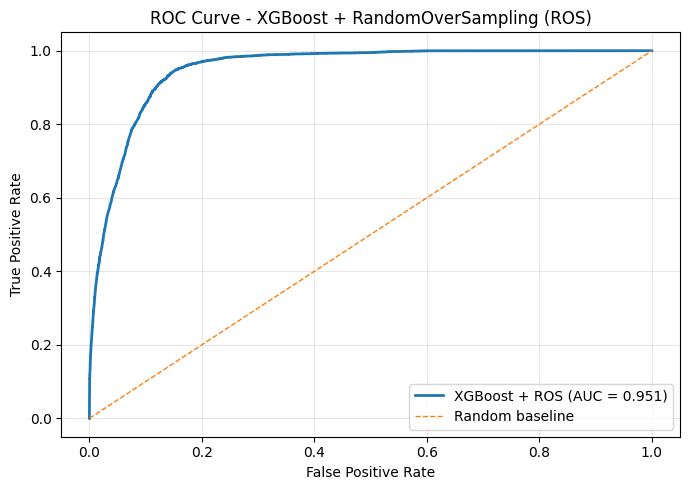


===== DECILE TABLE: XGBOOST + ROS =====
  Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob      Lift
0     D1       2550       1994       0.781961       0.942680  5.055477
1     D2       2549       1229       0.482150       0.828917  3.117161
2     D3       2549        572       0.224402       0.542442  1.450786
3     D4       2549         95       0.037270       0.145080  0.240952
4     D5       2549         24       0.009415       0.046865  0.060872
5     D6       2549         16       0.006277       0.022127  0.040581
6     D7       2549         12       0.004708       0.011137  0.030436
7     D8       2549          1       0.000392       0.006098  0.002536
8     D9       2549          0       0.000000       0.003001  0.000000
9    D10       2550          0       0.000000       0.000645  0.000000


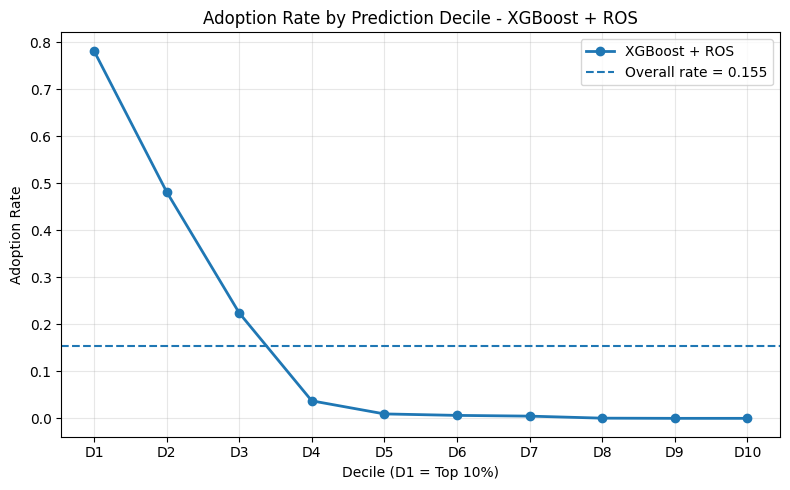

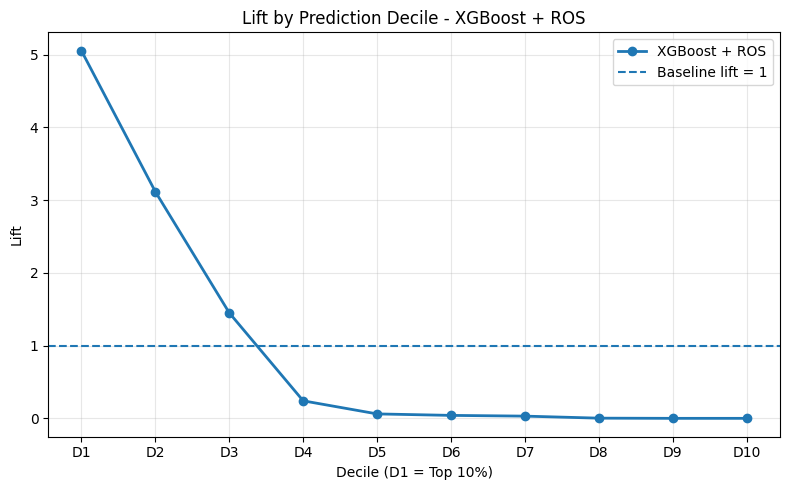


===== PRECISION@TOP-K: XGBOOST + ROS =====
                                Model    Top_K  Customers  Precision  \
0  XGBoost + RandomOverSampling (ROS)  Top 10%       2550   0.781961   
1  XGBoost + RandomOverSampling (ROS)  Top 20%       5099   0.632085   
2  XGBoost + RandomOverSampling (ROS)  Top 30%       7648   0.496208   

   Captured_Positives  Capture_Rate  
0                1994      0.505706  
1                3223      0.817398  
2                3795      0.962465  


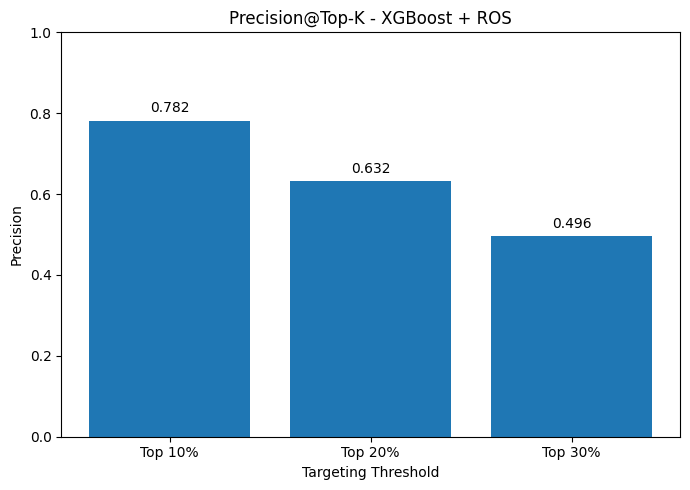

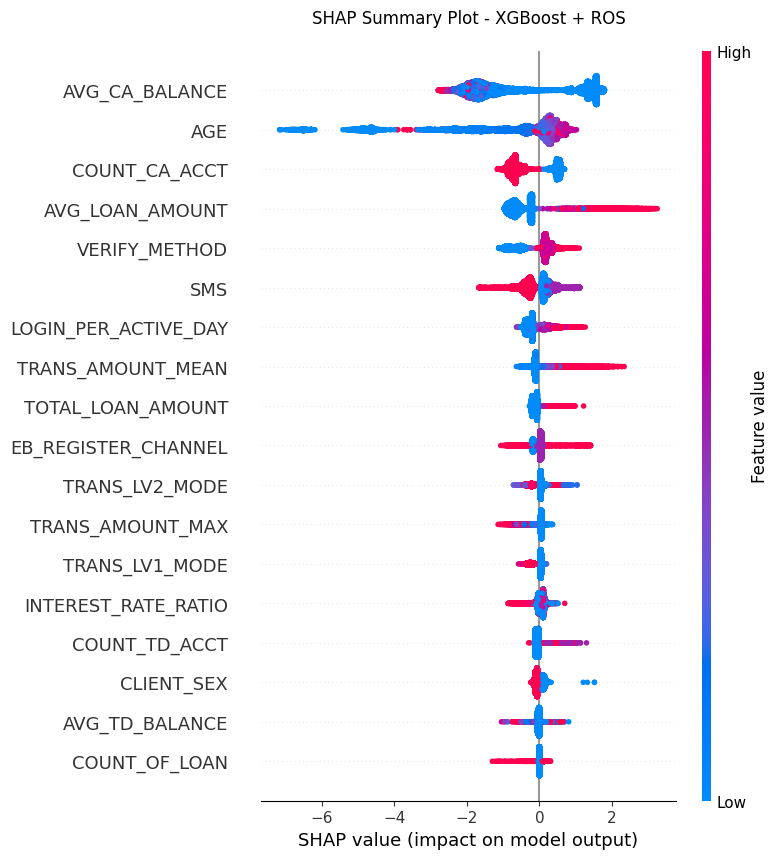

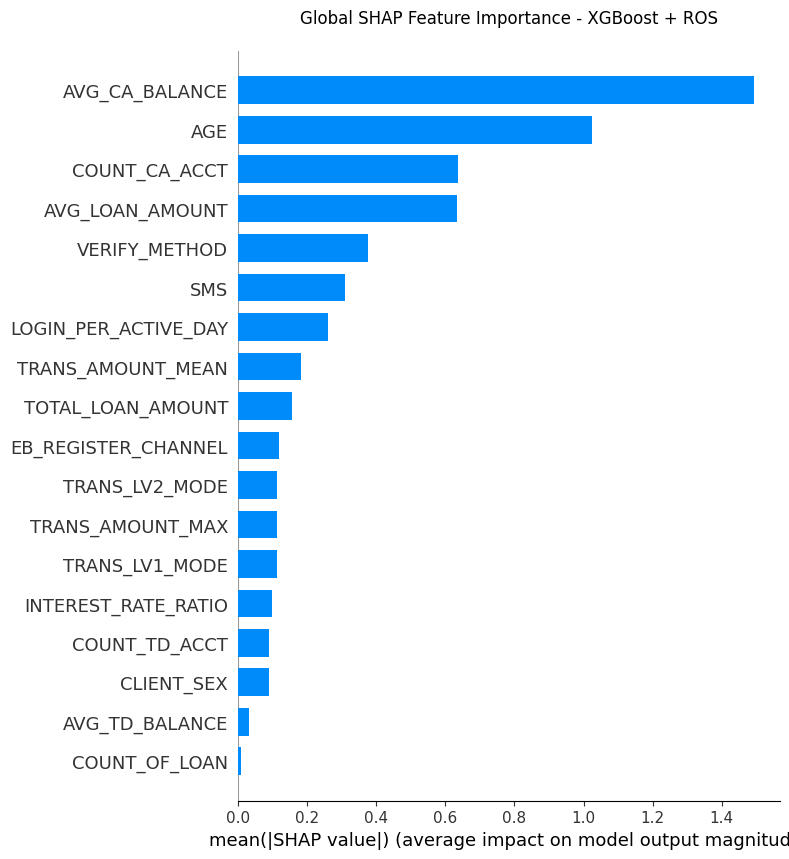


===== TOP SHAP FEATURES: XGBOOST + ROS =====
                 Feature  MeanAbsSHAP
12        AVG_CA_BALANCE     1.493691
4                    AGE     1.023381
11         COUNT_CA_ACCT     0.635745
16       AVG_LOAN_AMOUNT     0.633748
3          VERIFY_METHOD     0.375662
2                    SMS     0.311380
5   LOGIN_PER_ACTIVE_DAY     0.260939
10     TRANS_AMOUNT_MEAN     0.181686
17     TOTAL_LOAN_AMOUNT     0.157301
1    EB_REGISTER_CHANNEL     0.117651

Top SHAP feature: AVG_CA_BALANCE


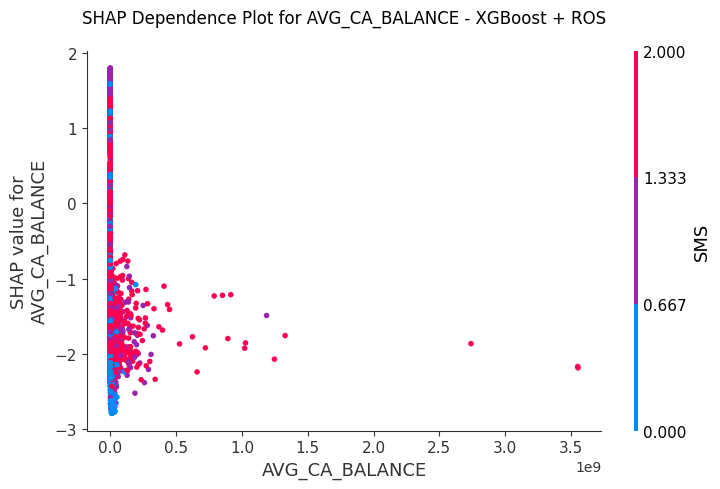


===== SAVED FILES =====
xgboost_ros_cv_results.csv
xgboost_ros_test_results.csv
roc_curve_xgboost_ros.png
decile_table_xgboost_ros.csv
decile_adoption_rate_xgboost_ros.png
decile_lift_xgboost_ros.png
precision_at_k_xgboost_ros.csv
precision_at_k_xgboost_ros.png
shap_summary_xgboost_ros.png
shap_bar_xgboost_ros.png
shap_feature_importance_xgboost_ros.csv
shap_dependence_AVG_CA_BALANCE_xgboost_ros.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, recall_score, f1_score, accuracy_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler

# =========================
# 1. LOAD DATA
# =========================
# Nếu dùng file đã xóa AUTO-JOB:
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)

# Nếu dùng file gốc thì đổi thành:
# df = pd.read_csv("final_dataset1.csv", low_memory=False)

df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# =========================
# 2. TARGET
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# =========================
# 3. FEATURES
# =========================
drop_cols = [c for c in [id_col, target_col] if c in df.columns]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# =========================
# 4. HARMONIZE COLUMN TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 6. MODEL: XGBOOST + ROS
# =========================
model_name = "XGBoost + RandomOverSampling (ROS)"

def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

ros = RandomOverSampler(random_state=42)

# =========================
# 7. PREPROCESS FUNCTION
# =========================
def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    encoder = None
    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# =========================
# 8. CROSS-VALIDATION FOR XGBOOST + ROS
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recall_scores = []
f1_scores = []
auc_scores = []
acc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx].copy()
    y_val = y_train.iloc[val_idx].copy()

    X_tr_prep, X_val_prep, _, _ = fit_preprocess(X_tr, X_val, cat_cols)

    X_tr_res, y_tr_res = ros.fit_resample(X_tr_prep, y_tr)

    model = get_xgb_model()
    model.fit(X_tr_res, y_tr_res)

    y_val_prob = model.predict_proba(X_val_prep)[:, 1]
    y_val_pred = (y_val_prob >= 0.5).astype(int)

    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_val_prob)
    acc = accuracy_score(y_val, y_val_pred)

    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)
    acc_scores.append(acc)

    print(f"Fold {fold} | Recall={recall:.4f} | F1={f1:.4f} | AUC={auc:.4f} | Accuracy={acc:.4f}")

cv_summary = pd.DataFrame([{
    "Model": model_name,
    "CV Recall": np.mean(recall_scores),
    "CV F1-score": np.mean(f1_scores),
    "CV AUC": np.mean(auc_scores),
    "CV Accuracy": np.mean(acc_scores),
    "Std (CV AUC)": np.std(auc_scores)
}])

print("\n===== CV RESULTS: XGBOOST + ROS =====")
print(cv_summary)

cv_summary.to_csv("xgboost_ros_cv_results.csv", index=False)

# =========================
# 9. FINAL TRAINING ON FULL TRAIN
# =========================
X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

final_model = get_xgb_model()
final_model.fit(X_train_res, y_train_res)

# =========================
# 10. TEST EVALUATION
# =========================
y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

test_summary = pd.DataFrame([{
    "Model": model_name,
    "Test Recall": test_recall,
    "Test F1-score": test_f1,
    "Test AUC": test_auc,
    "Test Accuracy": test_acc
}])

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print(test_summary)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

test_summary.to_csv("xgboost_ros_test_results.csv", index=False)

# =========================
# 11. ROC CURVE - GHI RÕ MÔ HÌNH
# =========================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost + ROS (AUC = {test_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost + RandomOverSampling (ROS)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 12. DECILE ANALYSIS
# =========================
def create_decile_table(y_true, y_prob, n_groups=10):
    decile_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    decile_df["Decile"] = pd.qcut(
        decile_df.index + 1,
        q=n_groups,
        labels=[f"D{i}" for i in range(1, n_groups + 1)]
    )

    decile_summary = decile_df.groupby("Decile", observed=False).agg(
        Customers=("y_true", "count"),
        Positives=("y_true", "sum"),
        Adoption_Rate=("y_true", "mean"),
        Avg_Pred_Prob=("y_prob", "mean")
    ).reset_index()

    overall_rate = decile_df["y_true"].mean()
    decile_summary["Lift"] = decile_summary["Adoption_Rate"] / overall_rate

    return decile_summary, overall_rate

decile_table_df, overall_rate = create_decile_table(y_test, y_test_prob)

print("\n===== DECILE TABLE: XGBOOST + ROS =====")
print(decile_table_df)

decile_table_df.to_csv("decile_table_xgboost_ros.csv", index=False)

# Adoption rate by decile
plt.figure(figsize=(8, 5))
plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Adoption_Rate"],
    marker="o",
    linewidth=2,
    label="XGBoost + ROS"
)
plt.axhline(
    y=overall_rate,
    linestyle="--",
    label=f"Overall rate = {overall_rate:.3f}"
)
plt.xlabel("Decile (D1 = Top 10%)")
plt.ylabel("Adoption Rate")
plt.title("Adoption Rate by Prediction Decile - XGBoost + ROS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("decile_adoption_rate_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# Lift by decile
plt.figure(figsize=(8, 5))
plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Lift"],
    marker="o",
    linewidth=2,
    label="XGBoost + ROS"
)
plt.axhline(
    y=1.0,
    linestyle="--",
    label="Baseline lift = 1"
)
plt.xlabel("Decile (D1 = Top 10%)")
plt.ylabel("Lift")
plt.title("Lift by Prediction Decile - XGBoost + ROS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("decile_lift_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 13. PRECISION@TOP-K
# =========================
def precision_at_k(y_true, y_prob, top_rates=[0.10, 0.20, 0.30]):
    result_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    rows = []
    n = len(result_df)

    for rate in top_rates:
        k = int(np.ceil(n * rate))
        top_df = result_df.iloc[:k]

        rows.append({
            "Model": model_name,
            "Top_K": f"Top {int(rate * 100)}%",
            "Customers": k,
            "Precision": top_df["y_true"].mean(),
            "Captured_Positives": top_df["y_true"].sum(),
            "Capture_Rate": top_df["y_true"].sum() / result_df["y_true"].sum()
        })

    return pd.DataFrame(rows)

precision_k_df = precision_at_k(y_test, y_test_prob)

print("\n===== PRECISION@TOP-K: XGBOOST + ROS =====")
print(precision_k_df)

precision_k_df.to_csv("precision_at_k_xgboost_ros.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    precision_k_df["Top_K"],
    precision_k_df["Precision"]
)
plt.ylim(0, 1)
plt.xlabel("Targeting Threshold")
plt.ylabel("Precision")
plt.title("Precision@Top-K - XGBoost + ROS")

for i, v in enumerate(precision_k_df["Precision"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("precision_at_k_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 14. SHAP ANALYSIS
# =========================
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_prep)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_prep,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost + ROS", pad=20)
plt.tight_layout()
plt.savefig("shap_summary_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# SHAP bar plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_prep,
    plot_type="bar",
    show=False
)
plt.title("Global SHAP Feature Importance - XGBoost + ROS", pad=20)
plt.tight_layout()
plt.savefig("shap_bar_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_prep.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n===== TOP SHAP FEATURES: XGBOOST + ROS =====")
print(shap_importance_df.head(10))

shap_importance_df.to_csv("shap_feature_importance_xgboost_ros.csv", index=False)

# Dependence plot for top feature
top_feature = shap_importance_df.iloc[0]["Feature"]
print("\nTop SHAP feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_prep,
    show=False
)
plt.title(f"SHAP Dependence Plot for {top_feature} - XGBoost + ROS", pad=20)
plt.tight_layout()
plt.savefig(f"shap_dependence_{top_feature}_xgboost_ros.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n===== SAVED FILES =====")
print("xgboost_ros_cv_results.csv")
print("xgboost_ros_test_results.csv")
print("roc_curve_xgboost_ros.png")
print("decile_table_xgboost_ros.csv")
print("decile_adoption_rate_xgboost_ros.png")
print("decile_lift_xgboost_ros.png")
print("precision_at_k_xgboost_ros.csv")
print("precision_at_k_xgboost_ros.png")
print("shap_summary_xgboost_ros.png")
print("shap_bar_xgboost_ros.png")
print("shap_feature_importance_xgboost_ros.csv")
print(f"shap_dependence_{top_feature}_xgboost_ros.png")

SHAP, DELICE, LIFT,ROC

Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']
Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']
Dataset shape: (127460, 20)
Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64
Fold 1 | Recall=0.9325 | F1=0.6883 | AUC=0.9526 | Accuracy=0.8694
Fold 2 | Recall=0.9296 | F1=0.6837 | AUC=0.9498 | Accuracy=0.8670
Fold 3 | Recall=0.9277 | F1=0.6817 | AUC=0.9504 | Accuracy=0.8660
Fold 4 | Recall=0.9236 | F1=0.6857 | AUC=0.9488 | Accuracy=0.8690
Fold 5 | Recall=0.9268 | F1=0.6873 | AUC=0.9523 | Accuracy=0.8696

===== CV RESULTS: XGBOOST + ROS =====
                                Model  CV Recall  CV F1-score    CV AUC  \
0  XGBoost + RandomOverSampling (ROS)   0.928032     0.685325  0.950

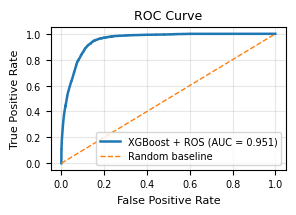


===== DECILE TABLE: XGBOOST + ROS =====
  Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob      Lift
0     D1       2550       1994       0.781961       0.942680  5.055477
1     D2       2549       1229       0.482150       0.828917  3.117161
2     D3       2549        572       0.224402       0.542442  1.450786
3     D4       2549         95       0.037270       0.145080  0.240952
4     D5       2549         24       0.009415       0.046865  0.060872
5     D6       2549         16       0.006277       0.022127  0.040581
6     D7       2549         12       0.004708       0.011137  0.030436
7     D8       2549          1       0.000392       0.006098  0.002536
8     D9       2549          0       0.000000       0.003001  0.000000
9    D10       2550          0       0.000000       0.000645  0.000000


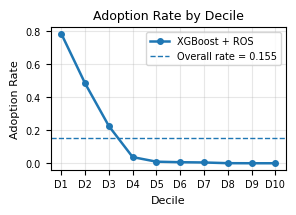

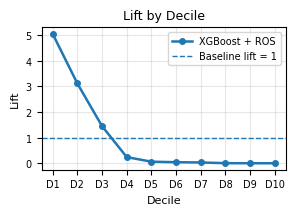


===== PRECISION@TOP-K: XGBOOST + ROS =====
                                Model    Top_K  Customers  Precision  \
0  XGBoost + RandomOverSampling (ROS)  Top 10%       2550   0.781961   
1  XGBoost + RandomOverSampling (ROS)  Top 20%       5099   0.632085   
2  XGBoost + RandomOverSampling (ROS)  Top 30%       7648   0.496208   

   Captured_Positives  Capture_Rate  
0                1994      0.505706  
1                3223      0.817398  
2                3795      0.962465  


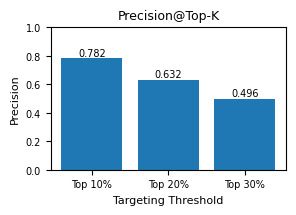

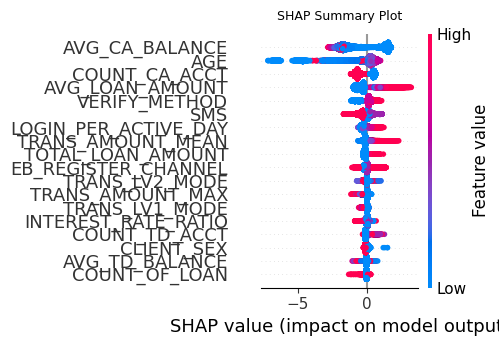

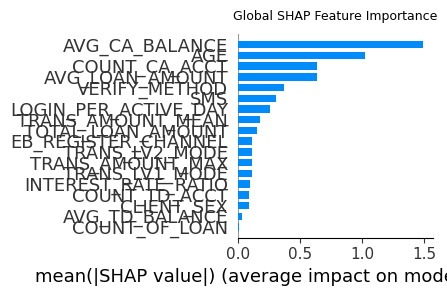


===== TOP SHAP FEATURES: XGBOOST + ROS =====
                 Feature  MeanAbsSHAP
12        AVG_CA_BALANCE     1.493691
4                    AGE     1.023381
11         COUNT_CA_ACCT     0.635745
16       AVG_LOAN_AMOUNT     0.633748
3          VERIFY_METHOD     0.375662
2                    SMS     0.311380
5   LOGIN_PER_ACTIVE_DAY     0.260939
10     TRANS_AMOUNT_MEAN     0.181686
17     TOTAL_LOAN_AMOUNT     0.157301
1    EB_REGISTER_CHANNEL     0.117651

Top SHAP feature: AVG_CA_BALANCE


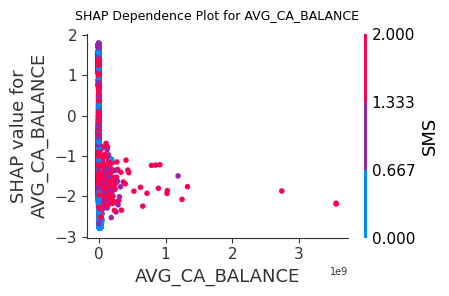


===== SAVED FILES =====
xgboost_ros_cv_results.csv
xgboost_ros_test_results.csv
decile_table_xgboost_ros.csv
precision_at_k_xgboost_ros.csv
shap_feature_importance_xgboost_ros.csv

Figures saved in folder: paper_figures


In [ ]:
# ==========================================================
# XGBOOST + ROS WITH PAPER-READY FIGURES
# TARGET: COUNT_CREDITCARD
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, recall_score, f1_score, accuracy_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler

# ==========================================================
# FIGURE SETTINGS FOR JOURNAL PAPER
# ==========================================================

FIG_DIR = "paper_figures"
os.makedirs(FIG_DIR, exist_ok=True)

DPI = 600

FIG_SMALL = (3.0, 2.2)     # ROC, Decile, Lift, Precision@K
FIG_MEDIUM = (4.5, 3.0)    # SHAP bar, SHAP dependence
FIG_LARGE = (5.0, 3.5)     # SHAP summary

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

def save_fig(filename):
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, filename),
        dpi=DPI,
        bbox_inches="tight",
        pad_inches=0.02
    )
    plt.show()


# ==========================================================
# 1. LOAD DATA
# ==========================================================

df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)

df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# ==========================================================
# 2. TARGET
# ==========================================================

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# ==========================================================
# 3. FEATURES
# ==========================================================

drop_cols = [c for c in [id_col, target_col] if c in df.columns]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# ==========================================================
# 4. HARMONIZE COLUMN TYPES
# ==========================================================

for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# ==========================================================
# 5. TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================================================
# 6. MODEL: XGBOOST + ROS
# ==========================================================

model_name = "XGBoost + RandomOverSampling (ROS)"

def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

ros = RandomOverSampler(random_state=42)

# ==========================================================
# 7. PREPROCESS FUNCTION
# ==========================================================

def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    encoder = None

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# ==========================================================
# 8. CROSS-VALIDATION FOR XGBOOST + ROS
# ==========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

recall_scores = []
f1_scores = []
auc_scores = []
acc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):

    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[val_idx].copy()
    y_tr = y_train.iloc[train_idx].copy()
    y_val = y_train.iloc[val_idx].copy()

    X_tr_prep, X_val_prep, _, _ = fit_preprocess(X_tr, X_val, cat_cols)

    X_tr_res, y_tr_res = ros.fit_resample(X_tr_prep, y_tr)

    model = get_xgb_model()
    model.fit(X_tr_res, y_tr_res)

    y_val_prob = model.predict_proba(X_val_prep)[:, 1]

    threshold = 0.5
    y_val_pred = (y_val_prob >= threshold).astype(int)

    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_val_prob)
    acc = accuracy_score(y_val, y_val_pred)

    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)
    acc_scores.append(acc)

    print(
        f"Fold {fold} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f} | "
        f"AUC={auc:.4f} | "
        f"Accuracy={acc:.4f}"
    )

cv_summary = pd.DataFrame([{
    "Model": model_name,
    "CV Recall": np.mean(recall_scores),
    "CV F1-score": np.mean(f1_scores),
    "CV AUC": np.mean(auc_scores),
    "CV Accuracy": np.mean(acc_scores),
    "Std (CV AUC)": np.std(auc_scores)
}])

print("\n===== CV RESULTS: XGBOOST + ROS =====")
print(cv_summary)

cv_summary.to_csv("xgboost_ros_cv_results.csv", index=False)

# ==========================================================
# 9. FINAL TRAINING ON FULL TRAINING SET
# ==========================================================

X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

final_model = get_xgb_model()
final_model.fit(X_train_res, y_train_res)

# ==========================================================
# 10. TEST EVALUATION
# ==========================================================

y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]

threshold = 0.5
y_test_pred = (y_test_prob >= threshold).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

test_summary = pd.DataFrame([{
    "Model": model_name,
    "Decision Threshold": threshold,
    "Test Recall": test_recall,
    "Test F1-score": test_f1,
    "Test AUC": test_auc,
    "Test Accuracy": test_acc
}])

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print(test_summary)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

test_summary.to_csv("xgboost_ros_test_results.csv", index=False)

# ==========================================================
# 11. ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    fpr,
    tpr,
    linewidth=1.8,
    label=f"XGBoost + ROS (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

save_fig("roc_curve_xgboost_ros.png")

# ==========================================================
# 12. DECILE ANALYSIS
# ==========================================================

def create_decile_table(y_true, y_prob, n_groups=10):
    decile_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    decile_df["Decile"] = pd.qcut(
        decile_df.index + 1,
        q=n_groups,
        labels=[f"D{i}" for i in range(1, n_groups + 1)]
    )

    decile_summary = decile_df.groupby("Decile", observed=False).agg(
        Customers=("y_true", "count"),
        Positives=("y_true", "sum"),
        Adoption_Rate=("y_true", "mean"),
        Avg_Pred_Prob=("y_prob", "mean")
    ).reset_index()

    overall_rate = decile_df["y_true"].mean()
    decile_summary["Lift"] = decile_summary["Adoption_Rate"] / overall_rate

    return decile_summary, overall_rate

decile_table_df, overall_rate = create_decile_table(y_test, y_test_prob)

print("\n===== DECILE TABLE: XGBOOST + ROS =====")
print(decile_table_df)

decile_table_df.to_csv("decile_table_xgboost_ros.csv", index=False)

# Adoption rate by decile
plt.figure(figsize=FIG_SMALL)

plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Adoption_Rate"],
    marker="o",
    linewidth=1.8,
    markersize=4,
    label="XGBoost + ROS"
)

plt.axhline(
    y=overall_rate,
    linestyle="--",
    linewidth=1,
    label=f"Overall rate = {overall_rate:.3f}"
)

plt.xlabel("Decile")
plt.ylabel("Adoption Rate")
plt.title("Adoption Rate by Decile")
plt.legend()
plt.grid(alpha=0.3)

save_fig("decile_adoption_rate_xgboost_ros.png")

# Lift by decile
plt.figure(figsize=FIG_SMALL)

plt.plot(
    decile_table_df["Decile"],
    decile_table_df["Lift"],
    marker="o",
    linewidth=1.8,
    markersize=4,
    label="XGBoost + ROS"
)

plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1,
    label="Baseline lift = 1"
)

plt.xlabel("Decile")
plt.ylabel("Lift")
plt.title("Lift by Decile")
plt.legend()
plt.grid(alpha=0.3)

save_fig("decile_lift_xgboost_ros.png")

# ==========================================================
# 13. PRECISION@TOP-K
# ==========================================================

def precision_at_k(y_true, y_prob, top_rates=[0.10, 0.20, 0.30]):
    result_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    rows = []
    n = len(result_df)

    for rate in top_rates:
        k = int(np.ceil(n * rate))
        top_df = result_df.iloc[:k]

        rows.append({
            "Model": model_name,
            "Top_K": f"Top {int(rate * 100)}%",
            "Customers": k,
            "Precision": top_df["y_true"].mean(),
            "Captured_Positives": top_df["y_true"].sum(),
            "Capture_Rate": top_df["y_true"].sum() / result_df["y_true"].sum()
        })

    return pd.DataFrame(rows)

precision_k_df = precision_at_k(y_test, y_test_prob)

print("\n===== PRECISION@TOP-K: XGBOOST + ROS =====")
print(precision_k_df)

precision_k_df.to_csv("precision_at_k_xgboost_ros.csv", index=False)

plt.figure(figsize=FIG_SMALL)

plt.bar(
    precision_k_df["Top_K"],
    precision_k_df["Precision"]
)

plt.ylim(0, 1)
plt.xlabel("Targeting Threshold")
plt.ylabel("Precision")
plt.title("Precision@Top-K")

for i, v in enumerate(precision_k_df["Precision"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=7)

save_fig("precision_at_k_xgboost_ros.png")

# ==========================================================
# 14. SHAP ANALYSIS
# ==========================================================

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_prep)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test_prep,
    show=False,
    plot_size=FIG_LARGE
)

plt.title("SHAP Summary Plot", pad=10)
save_fig("shap_summary_xgboost_ros.png")

# SHAP bar plot
shap.summary_plot(
    shap_values,
    X_test_prep,
    plot_type="bar",
    show=False,
    plot_size=FIG_MEDIUM
)

plt.title("Global SHAP Feature Importance", pad=10)
save_fig("shap_bar_xgboost_ros.png")

# Mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_prep.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n===== TOP SHAP FEATURES: XGBOOST + ROS =====")
print(shap_importance_df.head(10))

shap_importance_df.to_csv("shap_feature_importance_xgboost_ros.csv", index=False)

# SHAP dependence plot for top feature
top_feature = shap_importance_df.iloc[0]["Feature"]
print("\nTop SHAP feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_prep,
    show=False
)

plt.gcf().set_size_inches(*FIG_MEDIUM)
plt.title(f"SHAP Dependence Plot for {top_feature}", pad=10)

save_fig(f"shap_dependence_{top_feature}_xgboost_ros.png")

# ==========================================================
# 15. SAVED FILES
# ==========================================================

print("\n===== SAVED FILES =====")
print("xgboost_ros_cv_results.csv")
print("xgboost_ros_test_results.csv")
print("decile_table_xgboost_ros.csv")
print("precision_at_k_xgboost_ros.csv")
print("shap_feature_importance_xgboost_ros.csv")
print(f"\nFigures saved in folder: {FIG_DIR}")

Precision@K with 95% CI + Decile CI

In [ ]:
# ==========================================================
# XGBOOST + ROS + BOOTSTRAP 95% CI
# TARGET: COUNT_CREDITCARD
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score

from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler

# ==========================================================
# 1. LOAD DATA
# ==========================================================

df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# ==========================================================
# 2. TARGET
# ==========================================================

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# ==========================================================
# 3. FEATURES
# ==========================================================

drop_cols = [c for c in [id_col, target_col] if c in df.columns]

X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# ==========================================================
# 4. HANDLE DATA TYPES
# ==========================================================

for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        original_non_null = X[col].notna().sum()
        converted_non_null = converted.notna().sum()

        if original_non_null > 0 and converted_non_null / original_non_null >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# ==========================================================
# 5. TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ==========================================================
# 6. PREPROCESSING FUNCTION
# ==========================================================

def fit_preprocess(X_tr, X_te, cat_cols):
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    if len(cat_cols) > 0:
        for col in cat_cols:
            X_tr[col] = X_tr[col].astype("string")
            X_te[col] = X_te[col].astype("string")

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = encoder.transform(X_te[cat_cols])
    else:
        encoder = None

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_te = pd.DataFrame(
        imputer.transform(X_te),
        columns=X_te.columns,
        index=X_te.index
    )

    return X_tr, X_te, imputer, encoder

X_train_prep, X_test_prep, imputer, encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

# ==========================================================
# 7. RANDOM OVERSAMPLING
# ==========================================================

ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_prep,
    y_train
)

# ==========================================================
# 8. TRAIN XGBOOST
# ==========================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

# ==========================================================
# 9. TEST PREDICTION
# ==========================================================

y_test_prob = model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("\n===== TEST PERFORMANCE =====")
print("Recall  :", round(recall_score(y_test, y_test_pred), 4))
print("F1-score:", round(f1_score(y_test, y_test_pred), 4))
print("AUC     :", round(roc_auc_score(y_test, y_test_prob), 4))
print("Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))

# Save prediction-level file
prediction_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": y_test_prob
})

prediction_df.to_csv(
    "xgboost_ros_test_predictions.csv",
    index=False
)

# ==========================================================
# 10. DECILE TABLE
# ==========================================================

def create_decile_table(y_true, y_prob):
    df_rank = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    df_rank["Decile"] = pd.qcut(
        df_rank.index + 1,
        q=10,
        labels=[f"D{i}" for i in range(1, 11)]
    )

    overall_rate = df_rank["y_true"].mean()

    decile_table = (
        df_rank
        .groupby("Decile", observed=False)
        .agg(
            Customers=("y_true", "count"),
            Positives=("y_true", "sum"),
            Adoption_Rate=("y_true", "mean"),
            Avg_Pred_Prob=("y_prob", "mean")
        )
        .reset_index()
    )

    decile_table["Lift"] = decile_table["Adoption_Rate"] / overall_rate

    return decile_table, overall_rate

decile_table, overall_rate = create_decile_table(y_test, y_test_prob)

print("\n===== DECILE TABLE =====")
print(decile_table)

decile_table.to_csv(
    "decile_table_xgboost_ros.csv",
    index=False
)

# ==========================================================
# 11. PRECISION@K
# ==========================================================

def precision_at_k(y_true, y_prob, top_rates=[0.10, 0.20, 0.30]):
    df_rank = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    n = len(df_rank)
    total_positives = df_rank["y_true"].sum()

    rows = []

    for rate in top_rates:
        k = int(np.ceil(n * rate))
        top_df = df_rank.iloc[:k]

        rows.append({
            "Metric": f"Precision@{int(rate * 100)}%",
            "Top_K": f"Top {int(rate * 100)}%",
            "Customers": k,
            "Estimate": top_df["y_true"].mean(),
            "Captured_Positives": top_df["y_true"].sum(),
            "Capture_Rate": top_df["y_true"].sum() / total_positives
        })

    return pd.DataFrame(rows)

precision_k = precision_at_k(y_test, y_test_prob)

print("\n===== PRECISION@K =====")
print(precision_k)

precision_k.to_csv(
    "precision_at_k_xgboost_ros.csv",
    index=False
)

# ==========================================================
# 12. BOOTSTRAP 95% CI
# ==========================================================

def bootstrap_ranking_ci(
    y_true,
    y_prob,
    top_rates=[0.10, 0.20, 0.30],
    n_bootstrap=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    decile_boot = {f"D{i}": [] for i in range(1, 11)}
    precision_boot = {
        f"Precision@{int(rate * 100)}%": []
        for rate in top_rates
    }

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)

        boot_df = pd.DataFrame({
            "y_true": y_true[idx],
            "y_prob": y_prob[idx]
        }).sort_values("y_prob", ascending=False).reset_index(drop=True)

        boot_df["Decile"] = pd.qcut(
            boot_df.index + 1,
            q=10,
            labels=[f"D{i}" for i in range(1, 11)]
        )

        decile_rates = (
            boot_df
            .groupby("Decile", observed=False)["y_true"]
            .mean()
        )

        for d in decile_boot:
            decile_boot[d].append(decile_rates.loc[d])

        for rate in top_rates:
            k = int(np.ceil(n * rate))
            metric = f"Precision@{int(rate * 100)}%"
            precision_boot[metric].append(
                boot_df.iloc[:k]["y_true"].mean()
            )

    # Original estimates
    original_decile, _ = create_decile_table(y_true, y_prob)
    original_precision = precision_at_k(y_true, y_prob, top_rates)

    # Decile CI
    decile_ci_rows = []

    for d in decile_boot:
        values = np.array(decile_boot[d])

        estimate = original_decile.loc[
            original_decile["Decile"] == d,
            "Adoption_Rate"
        ].values[0]

        decile_ci_rows.append({
            "Decile": d,
            "Adoption_Rate": estimate,
            "CI_95_Lower": np.percentile(values, 2.5),
            "CI_95_Upper": np.percentile(values, 97.5)
        })

    decile_ci = pd.DataFrame(decile_ci_rows)

    # Precision CI
    precision_ci_rows = []

    for metric in precision_boot:
        values = np.array(precision_boot[metric])

        estimate = original_precision.loc[
            original_precision["Metric"] == metric,
            "Estimate"
        ].values[0]

        precision_ci_rows.append({
            "Metric": metric,
            "Estimate": estimate,
            "CI_95_Lower": np.percentile(values, 2.5),
            "CI_95_Upper": np.percentile(values, 97.5)
        })

    precision_ci = pd.DataFrame(precision_ci_rows)

    return decile_ci, precision_ci

decile_ci, precision_ci = bootstrap_ranking_ci(
    y_true=y_test,
    y_prob=y_test_prob,
    top_rates=[0.10, 0.20, 0.30],
    n_bootstrap=1000,
    random_state=42
)

# ==========================================================
# 13. FORMAT TABLES FOR PAPER
# ==========================================================

decile_ci_paper = decile_ci.copy()
precision_ci_paper = precision_ci.copy()

for col in ["Adoption_Rate", "CI_95_Lower", "CI_95_Upper"]:
    decile_ci_paper[col] = (decile_ci_paper[col] * 100).round(2)

for col in ["Estimate", "CI_95_Lower", "CI_95_Upper"]:
    precision_ci_paper[col] = precision_ci_paper[col].round(4)

print("\n===== DECILE ADOPTION RATE WITH 95% CI (%) =====")
print(decile_ci_paper)

print("\n===== PRECISION@K WITH 95% CI =====")
print(precision_ci_paper)

decile_ci_paper.to_csv(
    "decile_adoption_rate_bootstrap_ci.csv",
    index=False
)

precision_ci_paper.to_csv(
    "precision_at_k_bootstrap_ci.csv",
    index=False
)

print("\n===== SAVED FILES =====")
print("xgboost_ros_test_predictions.csv")
print("decile_table_xgboost_ros.csv")
print("precision_at_k_xgboost_ros.csv")
print("decile_adoption_rate_bootstrap_ci.csv")
print("precision_at_k_bootstrap_ci.csv")


===== TEST PERFORMANCE =====
Recall  : 0.9297
F1-score: 0.6912
AUC     : 0.9512
Accuracy: 0.8715

===== DECILE TABLE =====
  Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob      Lift
0     D1       2550       1994       0.781961       0.942680  5.055477
1     D2       2549       1229       0.482150       0.828917  3.117161
2     D3       2549        572       0.224402       0.542442  1.450786
3     D4       2549         95       0.037270       0.145080  0.240952
4     D5       2549         24       0.009415       0.046865  0.060872
5     D6       2549         16       0.006277       0.022127  0.040581
6     D7       2549         12       0.004708       0.011137  0.030436
7     D8       2549          1       0.000392       0.006098  0.002536
8     D9       2549          0       0.000000       0.003001  0.000000
9    D10       2550          0       0.000000       0.000645  0.000000

===== PRECISION@K =====
          Metric    Top_K  Customers  Estimate  Captured_Positives  \


SHAP

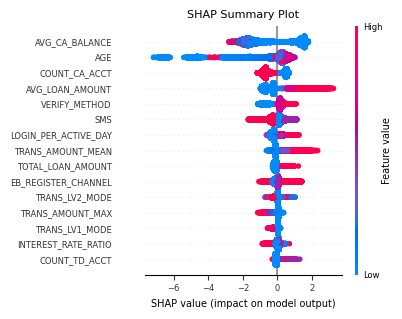

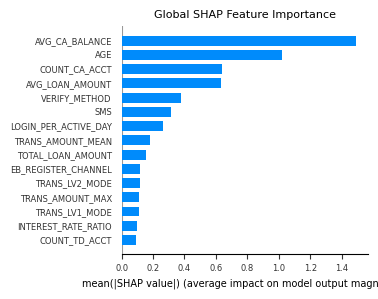


===== TOP 15 SHAP FEATURES: XGBOOST + ROS =====
                 Feature  MeanAbsSHAP
12        AVG_CA_BALANCE     1.493691
4                    AGE     1.023381
11         COUNT_CA_ACCT     0.635745
16       AVG_LOAN_AMOUNT     0.633748
3          VERIFY_METHOD     0.375662
2                    SMS     0.311380
5   LOGIN_PER_ACTIVE_DAY     0.260939
10     TRANS_AMOUNT_MEAN     0.181686
17     TOTAL_LOAN_AMOUNT     0.157301
1    EB_REGISTER_CHANNEL     0.117651
8         TRANS_LV2_MODE     0.114552
9       TRANS_AMOUNT_MAX     0.113803
7         TRANS_LV1_MODE     0.113182
6    INTEREST_RATE_RATIO     0.100120
13         COUNT_TD_ACCT     0.090522

Top SHAP feature: AVG_CA_BALANCE


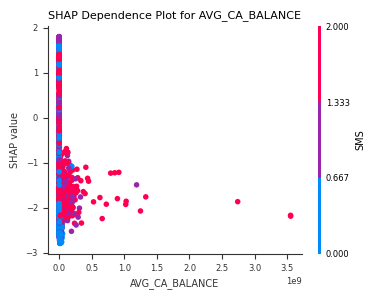

In [ ]:
# ==========================================================
# 14. SHAP ANALYSIS - JOURNAL 2-COLUMN VERSION, TOP 15
# ==========================================================

import os
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = "paper_figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6
})

DPI = 600

# Kích thước phù hợp để đặt 2 hình trên một hàng
SHAP_SUMMARY_SIZE = (4.2, 3.2)
SHAP_BAR_SIZE = (3.8, 3.0)
SHAP_DEP_SIZE = (3.8, 3.0)

MAX_DISPLAY = 15

# =========================
# COMPUTE SHAP VALUES
# =========================
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_prep)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# =========================
# SHAP SUMMARY PLOT - TOP 15
# =========================
shap.summary_plot(
    shap_values,
    X_test_prep,
    show=False,
    plot_size=SHAP_SUMMARY_SIZE,
    max_display=MAX_DISPLAY
)

fig = plt.gcf()
fig.set_size_inches(*SHAP_SUMMARY_SIZE)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)

plt.title("SHAP Summary Plot", fontsize=8, pad=6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "shap_summary_xgboost_ros_top15.png"),
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

# =========================
# SHAP BAR PLOT - TOP 15
# =========================
shap.summary_plot(
    shap_values,
    X_test_prep,
    plot_type="bar",
    show=False,
    plot_size=SHAP_BAR_SIZE,
    max_display=MAX_DISPLAY
)

fig = plt.gcf()
fig.set_size_inches(*SHAP_BAR_SIZE)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)

plt.title("Global SHAP Feature Importance", fontsize=8, pad=6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "shap_bar_xgboost_ros_top15.png"),
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

# =========================
# MEAN ABSOLUTE SHAP IMPORTANCE - TOP 15
# =========================
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_prep.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n===== TOP 15 SHAP FEATURES: XGBOOST + ROS =====")
print(shap_importance_df.head(MAX_DISPLAY))

shap_importance_df.to_csv(
    "shap_feature_importance_xgboost_ros_top15.csv",
    index=False
)

# =========================
# SHAP DEPENDENCE PLOT
# =========================
top_feature = shap_importance_df.iloc[0]["Feature"]
print("\nTop SHAP feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_prep,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(*SHAP_DEP_SIZE)

for ax in fig.axes:
    ax.tick_params(axis="both", labelsize=6)
    ax.xaxis.label.set_size(7)
    ax.yaxis.label.set_size(7)

plt.xlabel(top_feature, fontsize=7)
plt.ylabel("SHAP value", fontsize=7)
plt.title(f"SHAP Dependence Plot for {top_feature}", fontsize=8, pad=6)

plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, f"shap_dependence_{top_feature}_xgboost_ros.png"),
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()

Extended SHAP Analysis

/tmp/ipykernel_2490/1912756343.py:39: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("final_dataset_no_auto_job.csv")


===== XGBoost + Random Oversampling =====
Recall   : 0.9285
F1-score : 0.6907
AUC      : 0.9510
Accuracy : 0.8714
Brier    : 0.08987
Model and imputer saved successfully.


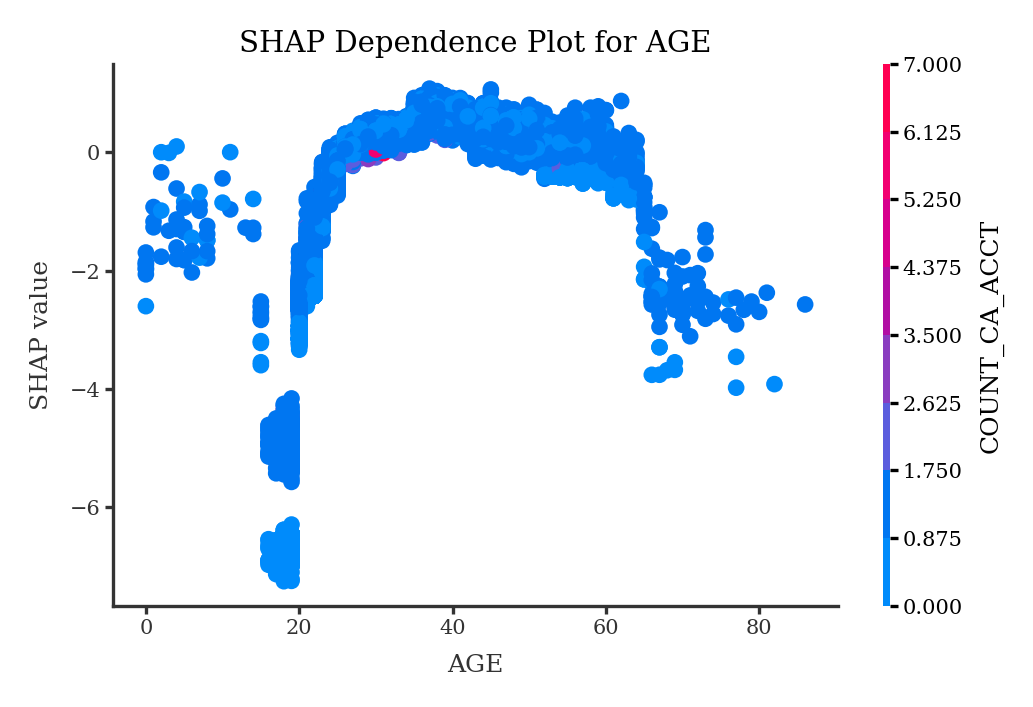

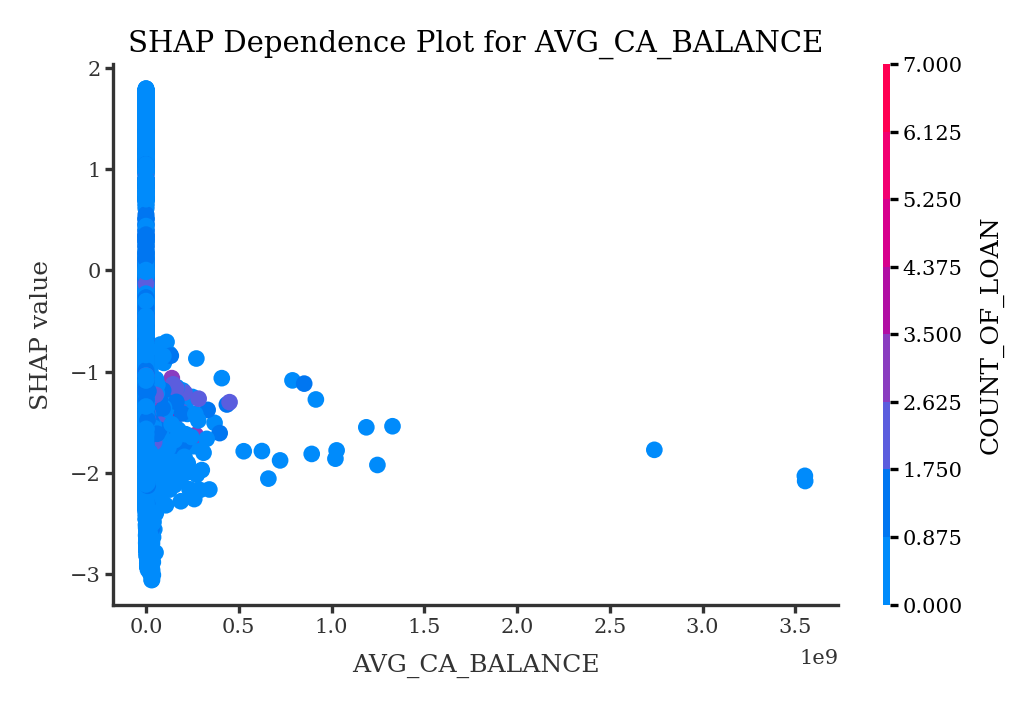

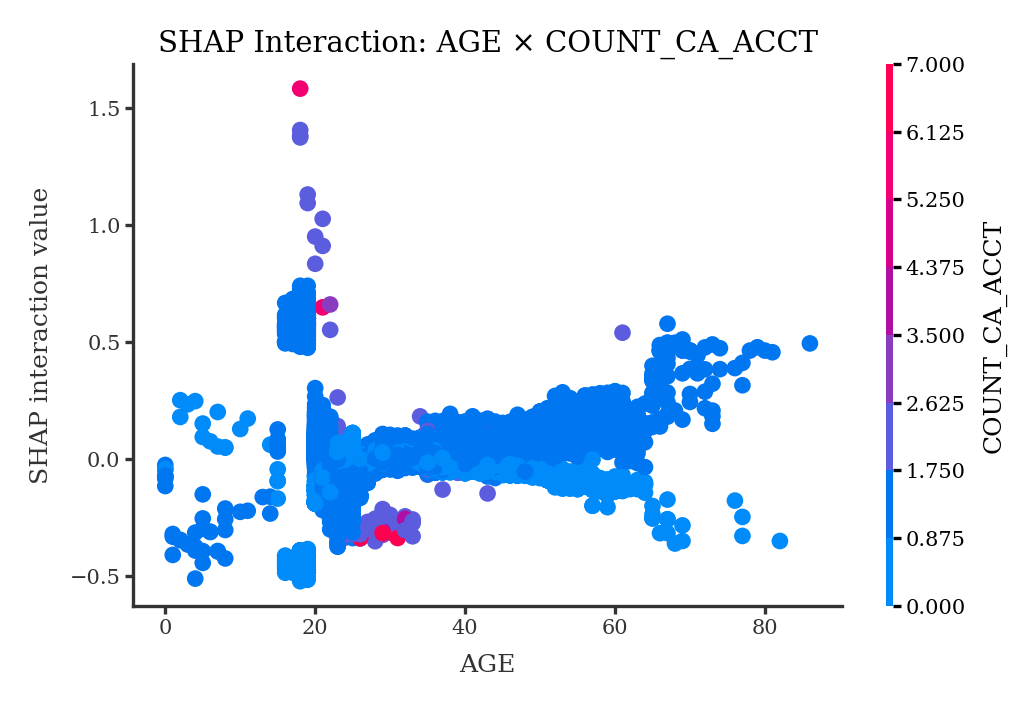

SHAP values and figures saved successfully.


In [ ]:
# ==========================================================
# FULL CODE: XGBOOST + RANDOM OVERSAMPLING + SHAP FIGURES
# IEEE ACCESS SINGLE-COLUMN FORMAT
# ==========================================================

# =========================
# 0. INSTALL IF NEEDED
# =========================
# !pip install shap xgboost imbalanced-learn joblib -q

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    brier_score_loss
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# ==========================================================
# 2. LOAD DATA
# ==========================================================

df = pd.read_csv("final_dataset_no_auto_job.csv")
df.columns = df.columns.str.strip()

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# Binary target: 1 if customer owns at least one credit card
y = (df[target_col] > 0).astype(int)

X = df.drop(columns=[target_col])

if id_col in X.columns:
    X = X.drop(columns=[id_col])

# Encode categorical variables
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes


# ==========================================================
# 3. TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ==========================================================
# 4. IMPUTATION
#    Fit on train only, transform train and test
# ==========================================================

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# ==========================================================
# 5. RANDOM OVERSAMPLING
#    Apply only on training data
# ==========================================================

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_imp,
    y_train
)


# ==========================================================
# 6. TRAIN XGBOOST MODEL
# ==========================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_ros, y_train_ros)


# ==========================================================
# 7. TEST SET EVALUATION
# ==========================================================

y_prob = xgb_model.predict_proba(X_test_imp)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("===== XGBoost + Random Oversampling =====")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Brier    : {brier_score_loss(y_test, y_prob):.5f}")


# ==========================================================
# 8. SAVE MODEL AND IMPUTER
#    Useful if Colab disconnects
# ==========================================================

joblib.dump(xgb_model, "xgb_ros_model.pkl")
joblib.dump(imputer, "median_imputer.pkl")

print("Model and imputer saved successfully.")


# ==========================================================
# 9. COMPUTE SHAP VALUES
#    Use test set after imputation, not oversampled data
# ==========================================================

X_shap = X_test_imp.copy()

# Optional: reduce sample size if SHAP is slow
# X_shap = X_test_imp.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

# For binary classification, some SHAP versions return list
if isinstance(shap_values, list):
    shap_values = shap_values[1]


# ==========================================================
# 10. IEEE FIGURE SETTINGS
# ==========================================================

DPI = 300
FIG_SINGLE = (3.35, 2.20)   # IEEE one-column size

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "figure.dpi": DPI,
    "savefig.dpi": DPI
})


def format_shap_figure(title, xlabel=None, ylabel="SHAP value"):
    fig = plt.gcf()
    fig.set_size_inches(FIG_SINGLE)

    ax = plt.gca()

    ax.set_title(title, fontsize=7, pad=3)

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=6)

    ax.set_ylabel(ylabel, fontsize=6)

    ax.tick_params(
        axis="both",
        labelsize=5,
        length=2,
        pad=1
    )

    # Format SHAP colorbar
    for cb_ax in fig.axes:
        if cb_ax is not ax:
            cb_ax.tick_params(labelsize=5, length=2, pad=1)
            cb_ax.yaxis.label.set_size(6)

    plt.tight_layout(pad=0.25)

    return fig, ax


# ==========================================================
# 11. FIG. 9(a): SHAP DEPENDENCE PLOT FOR AGE
#     interaction_index = COUNT_CA_ACCT
# ==========================================================

plt.close("all")

shap.dependence_plot(
    "AGE",
    shap_values,
    X_shap,
    interaction_index="COUNT_CA_ACCT",
    show=False
)

fig, ax = format_shap_figure(
    title="SHAP Dependence Plot for AGE",
    xlabel="AGE",
    ylabel="SHAP value"
)

fig.savefig(
    "Fig_9a_SHAP_Dependence_AGE.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ==========================================================
# 12. FIG. 9(b): SHAP DEPENDENCE PLOT FOR AVG_CA_BALANCE
#     interaction_index = COUNT_OF_LOAN
# ==========================================================

plt.close("all")

shap.dependence_plot(
    "AVG_CA_BALANCE",
    shap_values,
    X_shap,
    interaction_index="COUNT_OF_LOAN",
    show=False
)

fig, ax = format_shap_figure(
    title="SHAP Dependence Plot for AVG_CA_BALANCE",
    xlabel="AVG_CA_BALANCE",
    ylabel="SHAP value"
)

fig.savefig(
    "Fig_9b_SHAP_Dependence_AVG_CA_BALANCE.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ==========================================================
# 13. FIG. 9(c): SHAP INTERACTION PLOT AGE × COUNT_CA_ACCT
# ==========================================================

plt.close("all")

shap_interaction_values = explainer.shap_interaction_values(X_shap)

if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[1]

shap.dependence_plot(
    ("AGE", "COUNT_CA_ACCT"),
    shap_interaction_values,
    X_shap,
    show=False
)

fig, ax = format_shap_figure(
    title="SHAP Interaction: AGE × COUNT_CA_ACCT",
    xlabel="AGE",
    ylabel="SHAP interaction value"
)

fig.savefig(
    "Fig_9c_SHAP_Interaction_AGE_COUNT_CA_ACCT.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ==========================================================
# 14. OPTIONAL: SAVE SHAP VALUES
# ==========================================================

np.save("shap_values_xgb_ros.npy", shap_values)
X_shap.to_csv("X_shap_test_imp.csv", index=False)

print("SHAP values and figures saved successfully.")

# FULL PIPELINE: TRAIN + ROC + PRECISION@K + CALIBRATION


===== BASIC METRICS =====
Decision threshold: 0.5
AUC: 0.951179
[[18551  2998]
 [  277  3666]]
              precision    recall  f1-score   support

           0     0.9853    0.8609    0.9189     21549
           1     0.5501    0.9297    0.6912      3943

    accuracy                         0.8715     25492
   macro avg     0.7677    0.8953    0.8051     25492
weighted avg     0.9180    0.8715    0.8837     25492



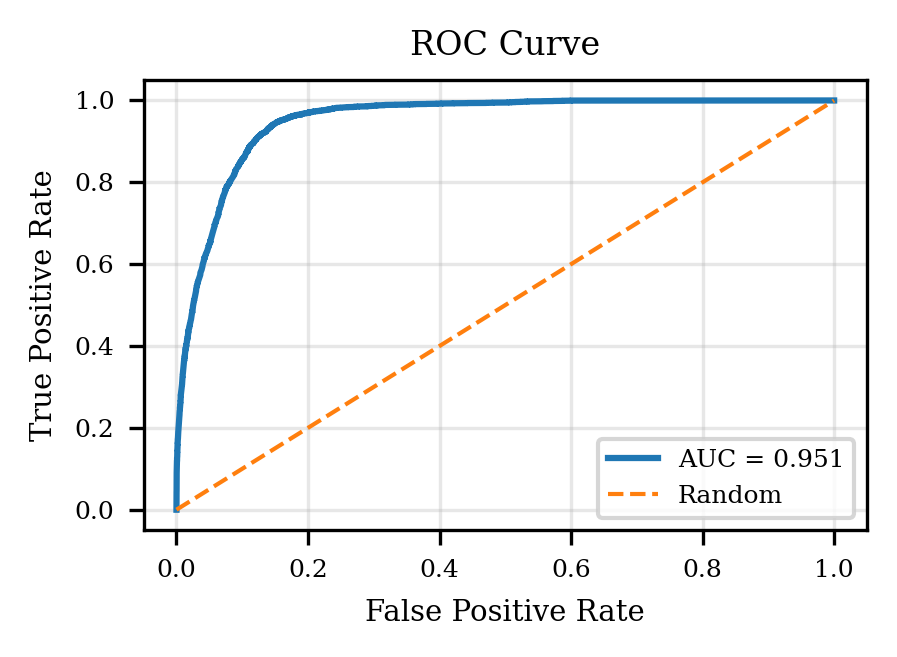


===== PRECISION@TOP-K =====
Top 10% (2549): 0.7819
Top 20% (5098): 0.6322
Top 30% (7647): 0.4963


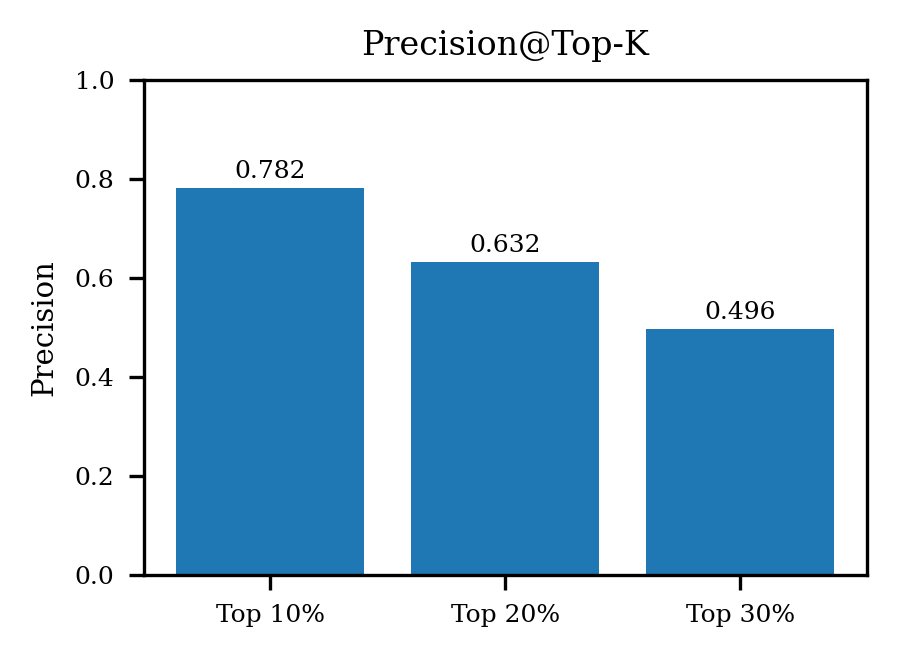


===== CALIBRATION =====
Brier Score: 0.089691


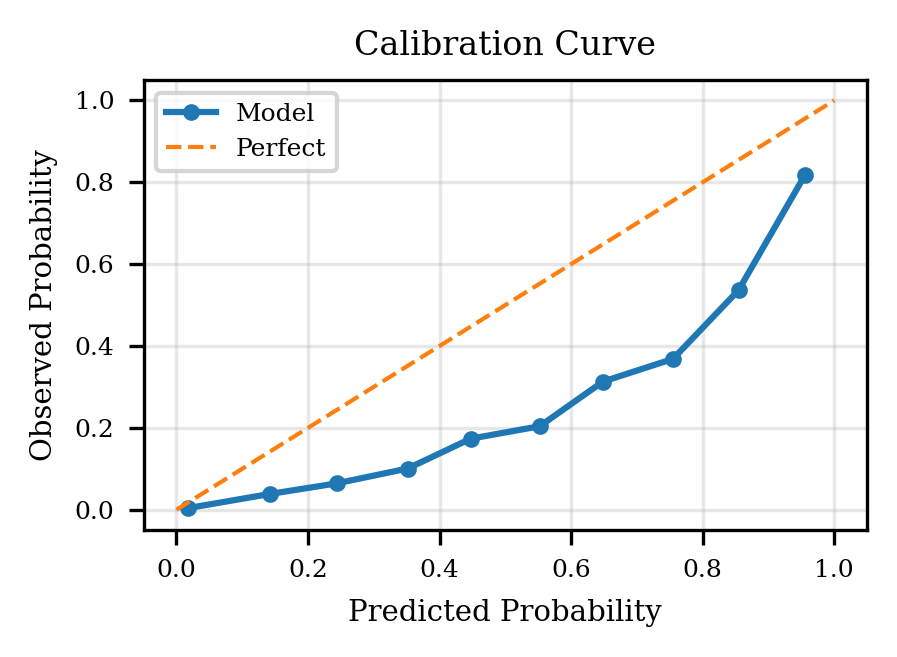


===== SAVED FILES =====
roc.png
precision_at_k.csv
precision_at_k.png
calibration_curve.png


In [ ]:
# =========================
# FULL PIPELINE: TRAIN + ROC + PRECISION@K + CALIBRATION
# PAPER-READY FIGURES FOR 2-COLUMN JOURNAL
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    brier_score_loss
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler


# =========================
# FIGURE SETTINGS FOR JOURNAL PAPER
# =========================
DPI = 600
FIG_SMALL = (3.0, 2.2)

plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6
})


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)


# =========================
# 2. TARGET
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()

df[target_col] = (df[target_col] > 0).astype(int)


# =========================
# 3. FEATURES
# =========================
drop_cols = [c for c in [id_col, target_col] if c in df.columns]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()


# =========================
# 4. TYPE HANDLING
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        if converted.notna().sum() / max(1, X[col].notna().sum()) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()


# =========================
# 5. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 6. PREPROCESS
# =========================
def preprocess(X_tr, X_te, cat_cols):
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_te[col] = X_te[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = encoder.transform(X_te[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns
    )

    X_te = pd.DataFrame(
        imputer.transform(X_te),
        columns=X_te.columns
    )

    return X_tr, X_te


X_train_prep, X_test_prep = preprocess(X_train, X_test, cat_cols)


# =========================
# 7. RESAMPLE
# =========================
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)


# =========================
# 8. MODEL
# =========================
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)


# =========================
# 9. PREDICT
# =========================
y_test_prob = model.predict_proba(X_test_prep)[:, 1]

threshold = 0.5
y_test_pred = (y_test_prob >= threshold).astype(int)

auc_value = roc_auc_score(y_test, y_test_prob)

print("\n===== BASIC METRICS =====")
print("Decision threshold:", threshold)
print("AUC:", round(auc_value, 6))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, digits=4))


# =========================
# 10. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    fpr,
    tpr,
    linewidth=1.5,
    label=f"AUC = {auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1,
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "roc.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()


# =========================
# 11. PRECISION@TOP-K
# =========================
df_eval = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "y_prob": np.asarray(y_test_prob)
}).sort_values("y_prob", ascending=False).reset_index(drop=True)


def top_precision(df, pct):
    n = max(1, int(len(df) * pct))
    return df.iloc[:n]["y_true"].mean(), n


p10, n10 = top_precision(df_eval, 0.10)
p20, n20 = top_precision(df_eval, 0.20)
p30, n30 = top_precision(df_eval, 0.30)

print("\n===== PRECISION@TOP-K =====")
print(f"Top 10% ({n10}): {p10:.4f}")
print(f"Top 20% ({n20}): {p20:.4f}")
print(f"Top 30% ({n30}): {p30:.4f}")

precision_table = pd.DataFrame({
    "Top (%)": [10, 20, 30],
    "Precision": [p10, p20, p30]
})

precision_table.to_csv("precision_at_k.csv", index=False)


# =========================
# 12. PRECISION@TOP-K FIGURE
# =========================
plt.figure(figsize=FIG_SMALL)

bars = plt.bar(
    ["Top 10%", "Top 20%", "Top 30%"],
    [p10, p20, p30]
)

plt.ylim(0, 1)
plt.ylabel("Precision")
plt.title("Precision@Top-K")

for i, v in enumerate([p10, p20, p30]):
    plt.text(
        i,
        v + 0.02,
        f"{v:.3f}",
        ha="center",
        fontsize=6
    )

plt.tight_layout()
plt.savefig(
    "precision_at_k.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()


# =========================
# 13. CALIBRATION (BRIER)
# =========================
brier = brier_score_loss(y_test, y_test_prob)

print("\n===== CALIBRATION =====")
print(f"Brier Score: {brier:.6f}")


# =========================
# 14. CALIBRATION CURVE
# =========================
prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10
)

plt.figure(figsize=FIG_SMALL)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1,
    label="Perfect"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "calibration_curve.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.02
)
plt.show()


print("\n===== SAVED FILES =====")
print("roc.png")
print("precision_at_k.csv")
print("precision_at_k.png")
print("calibration_curve.png")

TRỰC QUAN HÓA CỘT NHÃN

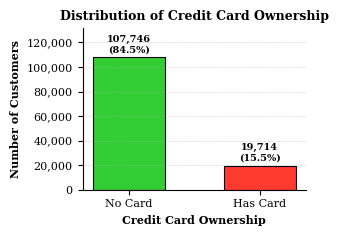

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

# ==========================================================
# TARGET COLUMN
# ==========================================================
target = "COUNT_CREDITCARD"

# Chuyển về nhãn nhị phân
df["Credit_Card_Ownership"] = (df[target] > 0).astype(int)

counts = df["Credit_Card_Ownership"].value_counts().sort_index()
percentages = counts / counts.sum() * 100

# ==========================================================
# IEEE STYLE SETTINGS
# ==========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ==========================================================
# IEEE SINGLE-COLUMN FIGURE
# ==========================================================
fig, ax = plt.subplots(figsize=(3.2, 2.4))

# Xanh tươi - Đỏ tươi
colors = ["#32CD32", "#FF3B30"]

bars = ax.bar(
    counts.index.astype(str),
    counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

# ==========================================================
# BAR LABELS
# ==========================================================
y_max = counts.max() * 1.22
ax.set_ylim(0, y_max)

for i, bar in enumerate(bars):
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + counts.max() * 0.025,
        f"{counts.iloc[i]:,}\n({percentages.iloc[i]:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=7,
        fontweight="bold"
    )

# ==========================================================
# TITLE & AXES
# ==========================================================
ax.set_title(
    "Distribution of Credit Card Ownership",
    fontweight="bold",
    pad=6
)

ax.set_xlabel(
    "Credit Card Ownership",
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Customers",
    fontweight="bold"
)

# ==========================================================
# CUSTOM X LABELS
# ==========================================================
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Card", "Has Card"])

# ==========================================================
# FORMAT Y AXIS
# ==========================================================
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ==========================================================
# CLEAN IEEE STYLE
# ==========================================================
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ==========================================================
# SAVE FIGURE
# ==========================================================
plt.savefig(
    "Figure_Class_Distribution_IEEE.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_Class_Distribution_IEEE.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
from google.colab import drive
from pathlib import Path

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Tìm đúng file trên toàn bộ MyDrive
exact_matches = list(
    Path("/content/drive/MyDrive").rglob(
        "final_dataset_no_auto_job.csv"
    )
)

if exact_matches:
    print("Tìm thấy file:")

    for i, path in enumerate(exact_matches):
        print(f"[{i}] {path}")

    data_path = exact_matches[0]
    print("\nSử dụng:", data_path)

else:
    # Tìm tên gần giống nếu file đã được đổi tên
    similar_matches = list(
        Path("/content/drive/MyDrive").rglob(
            "*final*dataset*.csv"
        )
    )

    print("Không tìm thấy tên chính xác.")
    print("Các file có tên gần giống:")

    for i, path in enumerate(similar_matches):
        print(f"[{i}] {path}")

    raise FileNotFoundError(
        "Hãy kiểm tra danh sách phía trên và chọn đúng file."
    )

Mounted at /content/drive
Tìm thấy file:
[0] /content/drive/MyDrive/Fintect/final_dataset_no_auto_job.csv
[1] /content/drive/MyDrive/ELAPSPLACEBO/final_dataset_no_auto_job.csv

Sử dụng: /content/drive/MyDrive/Fintect/final_dataset_no_auto_job.csv


In [ ]:
# ==========================================================
# RUN THIS CELL BEFORE THE PERMUTATION CELL
# ==========================================================

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder


# 1. Xác định đường dẫn dữ liệu
possible_paths = [
    Path("/content/final_dataset_no_auto_job.csv"),
    Path("final_dataset_no_auto_job.csv"),
    Path(
        "/content/drive/MyDrive/Fintect/"
        "final_dataset_no_auto_job.csv"
    )
]

data_path = next(
    (p for p in possible_paths if p.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "Không tìm thấy final_dataset_no_auto_job.csv. "
        "Hãy mount Google Drive và kiểm tra lại đường dẫn."
    )

print("Đang đọc:", data_path)


# 2. Đọc dữ liệu
df_perm = pd.read_csv(
    data_path,
    low_memory=False
)

df_perm.columns = df_perm.columns.str.strip()

df_perm = df_perm.replace(
    [
        "", " ", "NA", "N/A", "na",
        "null", "NULL", "None", "none"
    ],
    np.nan
)


# 3. Tạo target
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df_perm[target_col] = pd.to_numeric(
    df_perm[target_col],
    errors="coerce"
)

df_perm = df_perm.dropna(
    subset=[target_col]
).copy()

df_perm[target_col] = (
    df_perm[target_col] > 0
).astype(int)


# 4. Tạo X và y
drop_cols = [
    c for c in [id_col, target_col]
    if c in df_perm.columns
]

X_perm = df_perm.drop(
    columns=drop_cols
).copy()

y_perm = df_perm[target_col].copy()


# 5. Đồng nhất kiểu dữ liệu
for col in X_perm.columns:

    if X_perm[col].dtype == "object":

        converted = pd.to_numeric(
            X_perm[col],
            errors="coerce"
        )

        original_non_null = (
            X_perm[col].notna().sum()
        )

        converted_non_null = (
            converted.notna().sum()
        )

        if (
            original_non_null > 0
            and converted_non_null / original_non_null >= 0.8
        ):
            X_perm[col] = converted

        else:
            X_perm[col] = (
                X_perm[col].astype("string")
            )


cat_cols_perm = X_perm.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


# 6. Train/test split — đúng seed của ELAPS
X_train_raw, X_test_raw, y_train, y_test = (
    train_test_split(
        X_perm,
        y_perm,
        test_size=0.20,
        stratify=y_perm,
        random_state=42
    )
)


# 7. Ordinal encoding
X_train_encoded = X_train_raw.copy()
X_test_encoded = X_test_raw.copy()

if cat_cols_perm:

    for col in cat_cols_perm:
        X_train_encoded[col] = (
            X_train_encoded[col].astype("string")
        )

        X_test_encoded[col] = (
            X_test_encoded[col].astype("string")
        )

    perm_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1
    )

    X_train_encoded[cat_cols_perm] = (
        perm_encoder.fit_transform(
            X_train_encoded[cat_cols_perm]
        )
    )

    X_test_encoded[cat_cols_perm] = (
        perm_encoder.transform(
            X_test_encoded[cat_cols_perm]
        )
    )


# 8. Imputation
perm_imputer = SimpleImputer(
    strategy="median"
)

X_train_prep = pd.DataFrame(
    perm_imputer.fit_transform(
        X_train_encoded
    ),
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)

X_test_prep = pd.DataFrame(
    perm_imputer.transform(
        X_test_encoded
    ),
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)


# 9. Kiểm tra kết quả
print("\nĐÃ TẠO ĐỦ BỐN BIẾN:")
print("X_train_prep:", X_train_prep.shape)
print("X_test_prep :", X_test_prep.shape)
print("y_train     :", y_train.shape)
print("y_test      :", y_test.shape)

print(
    "Train prevalence:",
    round(float(np.mean(y_train)), 6)
)

print(
    "Test prevalence:",
    round(float(np.mean(y_test)), 6)
)

assert len(X_train_prep) == len(y_train)
assert len(X_test_prep) == len(y_test)
assert np.unique(y_train).size == 2
assert np.unique(y_test).size == 2

print("\n✓ Có thể chạy cell label permutation.")

Đang đọc: /content/drive/MyDrive/Fintect/final_dataset_no_auto_job.csv

ĐÃ TẠO ĐỦ BỐN BIẾN:
X_train_prep: (101968, 18)
X_test_prep : (25492, 18)
y_train     : (101968,)
y_test      : (25492,)
Train prevalence: 0.154666
Test prevalence: 0.154676

✓ Có thể chạy cell label permutation.


Label shuffle 100–1.000 lần hoán vị

OBSERVED MODEL
Observed test AUC: 0.951179


Label permutations:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_1450/3963998567.py:246: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  permutation_results = pd.concat(



LABEL-PERMUTATION TEST
                configuration  n_permutations  observed_auc  null_mean_auc  null_sd_auc  null_median_auc  null_q025  null_q975  null_min_auc  null_max_auc  count_null_ge_observed  permutation_p_value  minimum_attainable_p
XGBoost + Random Oversampling             100      0.951179       0.513894     0.047168         0.516067   0.420163   0.603155      0.394898      0.624051                       0             0.009901              0.009901

Paper-ready result:
Observed AUC = 0.9512; null mean = 0.5139; SD = 0.0472; 95% null interval = [0.4202, 0.6032]; 0/100 null AUCs >= observed; Monte Carlo p = 0.009901.


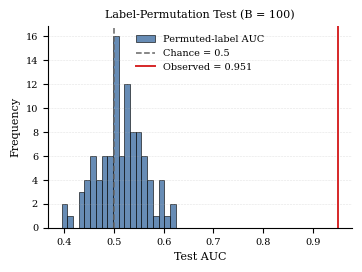


Saved files:
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_null_auc.csv
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_permutation_summary.csv
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_null_auc_distribution.png
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_null_auc_distribution.pdf


In [ ]:
# ==========================================================
# LABEL-PERMUTATION TEST — XGBOOST + ROS
# Correct order:
# permute y_train -> rerun ROS -> refit model -> fixed test set
# ==========================================================

from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


# ==========================================================
# 1. CONFIGURATION
# ==========================================================

N_PERMUTATIONS = 100
# Có thể đổi thành 500 hoặc 1000 sau khi chạy thành công 100 lần.

BASE_SEED = 20260825
MODEL_SEED = 42
CHECKPOINT_EVERY = 10

# Tự lưu vào Google Drive nếu thư mục Fintect đã được mount.
drive_project = Path("/content/drive/MyDrive/Fintect")

if drive_project.exists():
    output_dir = drive_project / "label_permutation_results"
else:
    output_dir = Path("label_permutation_results")

output_dir.mkdir(parents=True, exist_ok=True)

scores_file = output_dir / "xgb_ros_null_auc.csv"
summary_file = output_dir / "xgb_ros_permutation_summary.csv"
figure_png = output_dir / "xgb_ros_null_auc_distribution.png"
figure_pdf = output_dir / "xgb_ros_null_auc_distribution.pdf"


# ==========================================================
# 2. MODEL FACTORY
# Phải trùng với cấu hình XGBoost trong ELAPS
# ==========================================================

def make_xgb_model():

    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=MODEL_SEED,
        n_jobs=-1
    )


# ==========================================================
# 3. VALIDATE INPUTS
# ==========================================================

required_variables = [
    "X_train_prep",
    "X_test_prep",
    "y_train",
    "y_test"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise NameError(
        "Hãy chạy các cell tiền xử lý trước. Thiếu biến: "
        + ", ".join(missing_variables)
    )


y_train_array = np.asarray(y_train, dtype=int).ravel()
y_test_array = np.asarray(y_test, dtype=int).ravel()

if np.unique(y_train_array).size != 2:

    raise ValueError("y_train phải chứa đủ hai lớp 0 và 1.")

if np.unique(y_test_array).size != 2:

    raise ValueError("y_test phải chứa đủ hai lớp 0 và 1.")


# ==========================================================
# 4. OBSERVED AUC
# Refit cấu hình thật để tránh model bị ghi đè bởi cell cũ
# ==========================================================

observed_ros = RandomOverSampler(
    random_state=MODEL_SEED
)

X_train_observed, y_train_observed = observed_ros.fit_resample(
    X_train_prep,
    y_train_array
)

observed_model = make_xgb_model()

observed_model.fit(
    X_train_observed,
    y_train_observed
)

observed_probability = observed_model.predict_proba(
    X_test_prep
)[:, 1]

observed_auc = roc_auc_score(
    y_test_array,
    observed_probability
)

print("=" * 70)
print("OBSERVED MODEL")
print("=" * 70)
print(f"Observed test AUC: {observed_auc:.6f}")


# ==========================================================
# 5. LOAD CHECKPOINT
# ==========================================================

if scores_file.exists():

    permutation_results = pd.read_csv(scores_file)

    permutation_results = (
        permutation_results
        .drop_duplicates(
            subset="permutation",
            keep="last"
        )
        .sort_values("permutation")
        .reset_index(drop=True)
    )

    print(
        f"Loaded {len(permutation_results)} "
        "completed permutations."
    )

else:

    permutation_results = pd.DataFrame(
        columns=[
            "permutation",
            "seed",
            "auc"
        ]
    )


completed_permutations = set(
    permutation_results["permutation"]
    .astype(int)
    .tolist()
)

new_results = []


# ==========================================================
# 6. LABEL PERMUTATIONS
# ==========================================================

for permutation_index in tqdm(
    range(1, N_PERMUTATIONS + 1),
    desc="Label permutations"
):

    if permutation_index in completed_permutations:
        continue

    permutation_seed = (
        BASE_SEED + permutation_index
    )

    rng = np.random.default_rng(
        permutation_seed
    )

    # Hoán vị nhãn huấn luyện gốc.
    # Tuyệt đối không hoán vị y_test.
    y_train_permuted = rng.permutation(
        y_train_array
    )

    # Quan trọng: chạy lại ROS sau khi hoán vị nhãn.
    permutation_ros = RandomOverSampler(
        random_state=MODEL_SEED
    )

    X_train_null, y_train_null = (
        permutation_ros.fit_resample(
            X_train_prep,
            y_train_permuted
        )
    )

    permutation_model = make_xgb_model()

    permutation_model.fit(
        X_train_null,
        y_train_null
    )

    null_probability = (
        permutation_model.predict_proba(
            X_test_prep
        )[:, 1]
    )

    null_auc = roc_auc_score(
        y_test_array,
        null_probability
    )

    new_results.append({
        "permutation": permutation_index,
        "seed": permutation_seed,
        "auc": null_auc
    })

    # Lưu checkpoint để không mất kết quả nếu Colab ngắt.
    if len(new_results) >= CHECKPOINT_EVERY:

        permutation_results = pd.concat(
            [
                permutation_results,
                pd.DataFrame(new_results)
            ],
            ignore_index=True
        )

        permutation_results = (
            permutation_results
            .drop_duplicates(
                subset="permutation",
                keep="last"
            )
            .sort_values("permutation")
            .reset_index(drop=True)
        )

        permutation_results.to_csv(
            scores_file,
            index=False
        )

        new_results.clear()

    del (
        permutation_model,
        permutation_ros,
        X_train_null,
        y_train_null,
        y_train_permuted,
        null_probability
    )

    gc.collect()


# Lưu nhóm kết quả cuối cùng.
if new_results:

    permutation_results = pd.concat(
        [
            permutation_results,
            pd.DataFrame(new_results)
        ],
        ignore_index=True
    )


permutation_results = (
    permutation_results[
        permutation_results["permutation"]
        <= N_PERMUTATIONS
    ]
    .drop_duplicates(
        subset="permutation",
        keep="last"
    )
    .sort_values("permutation")
    .reset_index(drop=True)
)

permutation_results.to_csv(
    scores_file,
    index=False
)

if len(permutation_results) != N_PERMUTATIONS:

    raise RuntimeError(
        f"Cần {N_PERMUTATIONS} permutations, "
        f"nhưng hiện chỉ có {len(permutation_results)}."
    )


# ==========================================================
# 7. PERMUTATION STATISTICS
# ==========================================================

null_aucs = permutation_results[
    "auc"
].to_numpy(dtype=float)

count_ge_observed = int(
    np.sum(null_aucs >= observed_auc)
)

# Plus-one correction:
# p-value không được báo cáo bằng 0.
permutation_p_value = (
    count_ge_observed + 1
) / (
    N_PERMUTATIONS + 1
)

null_mean = np.mean(null_aucs)
null_sd = np.std(null_aucs, ddof=1)

null_q025, null_q975 = np.quantile(
    null_aucs,
    [0.025, 0.975]
)


summary = pd.DataFrame([{

    "configuration":
        "XGBoost + Random Oversampling",

    "n_permutations":
        N_PERMUTATIONS,

    "observed_auc":
        observed_auc,

    "null_mean_auc":
        null_mean,

    "null_sd_auc":
        null_sd,

    "null_median_auc":
        np.median(null_aucs),

    "null_q025":
        null_q025,

    "null_q975":
        null_q975,

    "null_min_auc":
        np.min(null_aucs),

    "null_max_auc":
        np.max(null_aucs),

    "count_null_ge_observed":
        count_ge_observed,

    "permutation_p_value":
        permutation_p_value,

    "minimum_attainable_p":
        1 / (N_PERMUTATIONS + 1)

}])

summary.to_csv(
    summary_file,
    index=False
)


print("\n" + "=" * 70)
print("LABEL-PERMUTATION TEST")
print("=" * 70)

print(summary.to_string(index=False))

print(
    "\nPaper-ready result:\n"
    f"Observed AUC = {observed_auc:.4f}; "
    f"null mean = {null_mean:.4f}; "
    f"SD = {null_sd:.4f}; "
    f"95% null interval = "
    f"[{null_q025:.4f}, {null_q975:.4f}]; "
    f"{count_ge_observed}/{N_PERMUTATIONS} "
    f"null AUCs >= observed; "
    f"Monte Carlo p = {permutation_p_value:.6f}."
)


# ==========================================================
# 8. IEEE-STYLE NULL DISTRIBUTION
# ==========================================================

plt.rcParams.update({

    "font.family": "serif",

    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],

    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42

})


fig, ax = plt.subplots(
    figsize=(3.5, 2.6)
)

number_of_bins = max(
    10,
    min(
        30,
        int(np.sqrt(N_PERMUTATIONS) * 2)
    )
)

ax.hist(

    null_aucs,

    bins=number_of_bins,

    color="#4C78A8",

    edgecolor="black",

    linewidth=0.5,

    alpha=0.85,

    label="Permuted-label AUC"
)

ax.axvline(

    0.5,

    color="#666666",

    linestyle="--",

    linewidth=1.1,

    label="Chance = 0.5"
)

ax.axvline(

    observed_auc,

    color="#D62728",

    linewidth=1.4,

    label=f"Observed = {observed_auc:.3f}"
)

ax.set_xlabel("Test AUC")
ax.set_ylabel("Frequency")

ax.set_title(
    f"Label-Permutation Test "
    f"(B = {N_PERMUTATIONS})"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.4,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    frameon=False
)

fig.tight_layout(pad=0.35)

fig.savefig(
    figure_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

fig.savefig(
    figure_pdf,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


print("\nSaved files:")

for saved_file in [
    scores_file,
    summary_file,
    figure_png,
    figure_pdf
]:

    print(saved_file)

Lable shuffle 1000-5000

OBSERVED MODEL
Observed test AUC: 0.951179
Loaded 100 completed permutations.
Target B = 1,000; đã có 100; còn chạy 900.


Label permutations:   0%|          | 0/1000 [00:00<?, ?it/s]


LABEL-PERMUTATION TEST
                configuration  n_permutations  observed_auc  null_mean_auc  null_sd_auc  null_median_auc  null_q025  null_q975  null_min_auc  null_max_auc  count_null_ge_observed  permutation_p_value  minimum_attainable_p
XGBoost + Random Oversampling            1000      0.951179        0.52229     0.045503         0.521871   0.437877   0.607651      0.394898      0.637315                       0             0.000999              0.000999

Paper-ready result:
Observed AUC = 0.9512; null mean = 0.5223; SD = 0.0455; 95% null interval = [0.4379, 0.6077]; 0/1000 null AUCs >= observed; Monte Carlo p = 0.000999.


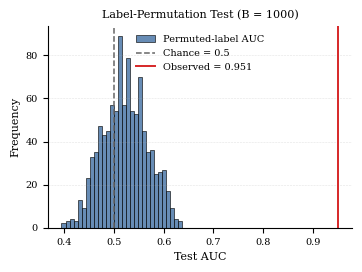


Saved files:
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_null_auc.csv
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_permutation_summary_B1000.csv
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_null_auc_distribution_B1000.png
/content/drive/MyDrive/Fintect/label_permutation_results/xgb_ros_null_auc_distribution_B1000.pdf


In [ ]:
# ==========================================================
# LABEL-PERMUTATION TEST — XGBOOST + ROS
# Correct order:
# permute y_train -> rerun ROS -> refit model -> fixed test set
# ==========================================================

from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


# ==========================================================
# 1. CONFIGURATION
# ==========================================================

# Chọn 1_000 cho bản chính; đổi thành 5_000 để chạy kiểm tra mở rộng.
# Checkpoint hiện có sẽ được tái sử dụng, không chạy lại các lần đã hoàn thành.
N_PERMUTATIONS = 1_000
# N_PERMUTATIONS = 5_000

if not isinstance(N_PERMUTATIONS, int) or N_PERMUTATIONS < 1:
    raise ValueError("N_PERMUTATIONS phải là số nguyên dương.")

BASE_SEED = 20260825
MODEL_SEED = 42
CHECKPOINT_EVERY = 10

# Tự lưu vào Google Drive nếu thư mục Fintect đã được mount.
drive_project = Path("/content/drive/MyDrive/Fintect")

if drive_project.exists():
    output_dir = drive_project / "label_permutation_results"
else:
    output_dir = Path("label_permutation_results")

output_dir.mkdir(parents=True, exist_ok=True)

# Một tệp checkpoint chung cho phép chạy nối tiếp 100 -> 1.000 -> 5.000.
scores_file = output_dir / "xgb_ros_null_auc.csv"

# Bảng và hình được tách theo B để kết quả 1.000 không bị bản 5.000 ghi đè.
summary_file = (
    output_dir
    / f"xgb_ros_permutation_summary_B{N_PERMUTATIONS}.csv"
)
figure_png = (
    output_dir
    / f"xgb_ros_null_auc_distribution_B{N_PERMUTATIONS}.png"
)
figure_pdf = (
    output_dir
    / f"xgb_ros_null_auc_distribution_B{N_PERMUTATIONS}.pdf"
)


# ==========================================================
# 2. MODEL FACTORY
# Phải trùng với cấu hình XGBoost trong ELAPS
# ==========================================================

def make_xgb_model():

    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=MODEL_SEED,
        n_jobs=-1
    )


# ==========================================================
# 3. VALIDATE INPUTS
# ==========================================================

required_variables = [
    "X_train_prep",
    "X_test_prep",
    "y_train",
    "y_test"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:

    raise NameError(
        "Hãy chạy các cell tiền xử lý trước. Thiếu biến: "
        + ", ".join(missing_variables)
    )


y_train_array = np.asarray(y_train, dtype=int).ravel()
y_test_array = np.asarray(y_test, dtype=int).ravel()

if np.unique(y_train_array).size != 2:

    raise ValueError("y_train phải chứa đủ hai lớp 0 và 1.")

if np.unique(y_test_array).size != 2:

    raise ValueError("y_test phải chứa đủ hai lớp 0 và 1.")


# ==========================================================
# 4. OBSERVED AUC
# Refit cấu hình thật để tránh model bị ghi đè bởi cell cũ
# ==========================================================

observed_ros = RandomOverSampler(
    random_state=MODEL_SEED
)

X_train_observed, y_train_observed = observed_ros.fit_resample(
    X_train_prep,
    y_train_array
)

observed_model = make_xgb_model()

observed_model.fit(
    X_train_observed,
    y_train_observed
)

observed_probability = observed_model.predict_proba(
    X_test_prep
)[:, 1]

observed_auc = roc_auc_score(
    y_test_array,
    observed_probability
)

print("=" * 70)
print("OBSERVED MODEL")
print("=" * 70)
print(f"Observed test AUC: {observed_auc:.6f}")


# ==========================================================
# 5. LOAD CHECKPOINT
# ==========================================================

if scores_file.exists():

    permutation_results = pd.read_csv(scores_file)

    permutation_results = (
        permutation_results
        .drop_duplicates(
            subset="permutation",
            keep="last"
        )
        .sort_values("permutation")
        .reset_index(drop=True)
    )

    print(
        f"Loaded {len(permutation_results)} "
        "completed permutations."
    )

else:

    # Khai báo dtype rõ ràng để tránh FutureWarning khi nối batch đầu tiên.
    permutation_results = pd.DataFrame({
        "permutation": pd.Series(dtype="int64"),
        "seed": pd.Series(dtype="int64"),
        "auc": pd.Series(dtype="float64")
    })


completed_permutations = set(
    permutation_results["permutation"]
    .astype(int)
    .tolist()
)

completed_for_target = sum(
    1 <= index <= N_PERMUTATIONS
    for index in completed_permutations
)

print(
    f"Target B = {N_PERMUTATIONS:,}; "
    f"đã có {completed_for_target:,}; "
    f"còn chạy {N_PERMUTATIONS - completed_for_target:,}."
)

new_results = []


# ==========================================================
# 6. LABEL PERMUTATIONS
# ==========================================================

for permutation_index in tqdm(
    range(1, N_PERMUTATIONS + 1),
    desc="Label permutations"
):

    if permutation_index in completed_permutations:
        continue

    permutation_seed = (
        BASE_SEED + permutation_index
    )

    rng = np.random.default_rng(
        permutation_seed
    )

    # Hoán vị nhãn huấn luyện gốc.
    # Tuyệt đối không hoán vị y_test.
    y_train_permuted = rng.permutation(
        y_train_array
    )

    # Quan trọng: chạy lại ROS sau khi hoán vị nhãn.
    permutation_ros = RandomOverSampler(
        random_state=MODEL_SEED
    )

    X_train_null, y_train_null = (
        permutation_ros.fit_resample(
            X_train_prep,
            y_train_permuted
        )
    )

    permutation_model = make_xgb_model()

    permutation_model.fit(
        X_train_null,
        y_train_null
    )

    null_probability = (
        permutation_model.predict_proba(
            X_test_prep
        )[:, 1]
    )

    null_auc = roc_auc_score(
        y_test_array,
        null_probability
    )

    new_results.append({
        "permutation": permutation_index,
        "seed": permutation_seed,
        "auc": null_auc
    })

    # Lưu checkpoint để không mất kết quả nếu Colab ngắt.
    if len(new_results) >= CHECKPOINT_EVERY:

        batch_df = pd.DataFrame(new_results)

        if permutation_results.empty:
            permutation_results = batch_df
        else:
            permutation_results = pd.concat(
                [permutation_results, batch_df],
                ignore_index=True
            )

        permutation_results = (
            permutation_results
            .drop_duplicates(
                subset="permutation",
                keep="last"
            )
            .sort_values("permutation")
            .reset_index(drop=True)
        )

        permutation_results.to_csv(
            scores_file,
            index=False
        )

        new_results.clear()

    del (
        permutation_model,
        permutation_ros,
        X_train_null,
        y_train_null,
        y_train_permuted,
        null_probability
    )

    gc.collect()


# Lưu nhóm kết quả cuối cùng.
if new_results:

    batch_df = pd.DataFrame(new_results)

    if permutation_results.empty:
        permutation_results = batch_df
    else:
        permutation_results = pd.concat(
            [permutation_results, batch_df],
            ignore_index=True
        )


permutation_results = (
    permutation_results
    .drop_duplicates(
        subset="permutation",
        keep="last"
    )
    .sort_values("permutation")
    .reset_index(drop=True)
)

permutation_results.to_csv(
    scores_file,
    index=False
)

# Không xóa checkpoint lớn hơn B nếu người dùng chạy lại với B nhỏ hơn.
analysis_results = (
    permutation_results[
        permutation_results["permutation"].between(
            1,
            N_PERMUTATIONS
        )
    ]
    .sort_values("permutation")
    .reset_index(drop=True)
)

available_indices = set(
    analysis_results["permutation"]
    .astype(int)
    .tolist()
)

missing_indices = sorted(
    set(range(1, N_PERMUTATIONS + 1))
    - available_indices
)

if missing_indices:

    raise RuntimeError(
        f"Thiếu {len(missing_indices)} permutations trong phạm vi "
        f"1..{N_PERMUTATIONS}. Các chỉ số đầu tiên bị thiếu: "
        f"{missing_indices[:10]}"
    )


# ==========================================================
# 7. PERMUTATION STATISTICS
# ==========================================================

null_aucs = analysis_results[
    "auc"
].to_numpy(dtype=float)

count_ge_observed = int(
    np.sum(null_aucs >= observed_auc)
)

# Plus-one correction:
# p-value không được báo cáo bằng 0.
permutation_p_value = (
    count_ge_observed + 1
) / (
    N_PERMUTATIONS + 1
)

null_mean = np.mean(null_aucs)
null_sd = np.std(null_aucs, ddof=1)

null_q025, null_q975 = np.quantile(
    null_aucs,
    [0.025, 0.975]
)


summary = pd.DataFrame([{

    "configuration":
        "XGBoost + Random Oversampling",

    "n_permutations":
        N_PERMUTATIONS,

    "observed_auc":
        observed_auc,

    "null_mean_auc":
        null_mean,

    "null_sd_auc":
        null_sd,

    "null_median_auc":
        np.median(null_aucs),

    "null_q025":
        null_q025,

    "null_q975":
        null_q975,

    "null_min_auc":
        np.min(null_aucs),

    "null_max_auc":
        np.max(null_aucs),

    "count_null_ge_observed":
        count_ge_observed,

    "permutation_p_value":
        permutation_p_value,

    "minimum_attainable_p":
        1 / (N_PERMUTATIONS + 1)

}])

summary.to_csv(
    summary_file,
    index=False
)


print("\n" + "=" * 70)
print("LABEL-PERMUTATION TEST")
print("=" * 70)

print(summary.to_string(index=False))

print(
    "\nPaper-ready result:\n"
    f"Observed AUC = {observed_auc:.4f}; "
    f"null mean = {null_mean:.4f}; "
    f"SD = {null_sd:.4f}; "
    f"95% null interval = "
    f"[{null_q025:.4f}, {null_q975:.4f}]; "
    f"{count_ge_observed}/{N_PERMUTATIONS} "
    f"null AUCs >= observed; "
    f"Monte Carlo p = {permutation_p_value:.6f}."
)


# ==========================================================
# 8. IEEE-STYLE NULL DISTRIBUTION
# ==========================================================

plt.rcParams.update({

    "font.family": "serif",

    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],

    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42

})


fig, ax = plt.subplots(
    figsize=(3.5, 2.6)
)

number_of_bins = max(
    10,
    min(
        30,
        int(np.sqrt(N_PERMUTATIONS) * 2)
    )
)

ax.hist(

    null_aucs,

    bins=number_of_bins,

    color="#4C78A8",

    edgecolor="black",

    linewidth=0.5,

    alpha=0.85,

    label="Permuted-label AUC"
)

ax.axvline(

    0.5,

    color="#666666",

    linestyle="--",

    linewidth=1.1,

    label="Chance = 0.5"
)

ax.axvline(

    observed_auc,

    color="#D62728",

    linewidth=1.4,

    label=f"Observed = {observed_auc:.3f}"
)

ax.set_xlabel("Test AUC")
ax.set_ylabel("Frequency")

ax.set_title(
    f"Label-Permutation Test "
    f"(B = {N_PERMUTATIONS})"
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.4,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    frameon=False
)

fig.tight_layout(pad=0.35)

fig.savefig(
    figure_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

fig.savefig(
    figure_pdf,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


print("\nSaved files:")

for saved_file in [
    scores_file,
    summary_file,
    figure_png,
    figure_pdf
]:

    print(saved_file)

TẠO BẢNG THỐNG KÊ COUNT_CA_ACCT

In [ ]:
import pandas as pd
import numpy as np

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)

# ==========================================================
# CREATE BINARY TARGET
# ==========================================================
df["HAS_CREDITCARD"] = (df["COUNT_CREDITCARD"] > 0).astype(int)

# ==========================================================
# TABLE 1: CREDIT CARD OWNERSHIP RATE BY COUNT_CA_ACCT
# ==========================================================
summary = (
    df.groupby("COUNT_CA_ACCT")
      .agg(
          Customers=("COUNT_CA_ACCT", "size"),
          Card_Holders=("HAS_CREDITCARD", "sum")
      )
      .reset_index()
)

summary["Customer_%"] = (
    summary["Customers"] /
    summary["Customers"].sum() * 100
)

summary["Card_Ownership_Rate_%"] = (
    summary["Card_Holders"] /
    summary["Customers"] * 100
)

summary["Customer_%"] = summary["Customer_%"].round(2)
summary["Card_Ownership_Rate_%"] = summary["Card_Ownership_Rate_%"].round(2)

print("\n" + "="*80)
print("TABLE 1. CREDIT CARD OWNERSHIP RATE BY COUNT_CA_ACCT")
print("="*80)
print(summary)

# ==========================================================
# TABLE 2: PROFILE COMPARISON
# COUNT_CA_ACCT = 0 vs COUNT_CA_ACCT > 0
# ==========================================================
profile = (
    df.assign(
        CA_GROUP=np.where(
            df["COUNT_CA_ACCT"] == 0,
            "COUNT_CA_ACCT = 0",
            "COUNT_CA_ACCT > 0"
        )
    )
    .groupby("CA_GROUP")
    .agg(
        Customers=("CA_GROUP", "size"),
        Credit_Card_Rate=("HAS_CREDITCARD", "mean"),
        Avg_Loan_Count=("COUNT_OF_LOAN", "mean"),
        Avg_Loan_Amount=("AVG_LOAN_AMOUNT", "mean"),
        Avg_Login_Per_Active_Day=("LOGIN_PER_ACTIVE_DAY", "mean"),
        Avg_Age=("AGE", "mean")
    )
)

profile["Credit_Card_Rate"] = (
    profile["Credit_Card_Rate"] * 100
)

profile = profile.round(2)

print("\n" + "="*80)
print("TABLE 2. PROFILE COMPARISON OF CUSTOMERS")
print("="*80)
print(profile)

# ==========================================================
# SAVE RESULTS
# ==========================================================
summary.to_csv(
    "count_ca_acct_summary.csv",
    index=False
)

profile.to_csv(
    "count_ca_acct_profile.csv"
)

print("\nFiles saved:")
print(" - count_ca_acct_summary.csv")
print(" - count_ca_acct_profile.csv")


TABLE 1. CREDIT CARD OWNERSHIP RATE BY COUNT_CA_ACCT
   COUNT_CA_ACCT  Customers  Card_Holders  Customer_%  Card_Ownership_Rate_%
0              0      35573         16147       27.91                  45.39
1              1      91366          3543       71.68                   3.88
2              2        447            24        0.35                   5.37
3              3         21             0        0.02                   0.00
4              4          7             0        0.01                   0.00
5              5          4             0        0.00                   0.00
6              6         17             0        0.01                   0.00
7              7         23             0        0.02                   0.00
8              8          1             0        0.00                   0.00
9             10          1             0        0.00                   0.00

TABLE 2. PROFILE COMPARISON OF CUSTOMERS
                   Customers  Credit_Card_Rate  Avg_Loan_

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier


# =========================
# CONFIG
# =========================
data_path = "final_dataset_no_auto_job.csv"

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

account_features = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# =========================
# METRICS
# =========================
def ks_score(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def ranking_metrics(y_true, y_prob):
    df_rank = pd.DataFrame({
        "y": np.asarray(y_true),
        "prob": np.asarray(y_prob)
    })

    df_rank = df_rank.sort_values(
        "prob",
        ascending=False
    ).reset_index(drop=True)

    base_rate = df_rank["y"].mean()
    total_positive = df_rank["y"].sum()
    n = len(df_rank)

    top10_n = int(np.ceil(0.10 * n))
    top10 = df_rank.iloc[:top10_n]

    precision_10 = top10["y"].mean()
    capture_10 = top10["y"].sum() / total_positive
    lift_d1 = precision_10 / base_rate

    return precision_10, capture_10, lift_d1


# =========================
# RUN ONE EXPERIMENT
# =========================
def run_xgb_ros(data_path, feature_set_name, remove_features=None):
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.strip()

    y = (df[target_col] > 0).astype(int)

    X = df.drop(
        columns=[target_col, id_col],
        errors="ignore"
    ).copy()

    if remove_features is None:
        remove_features = []

    missing_features = [
        col for col in remove_features
        if col not in X.columns
    ]

    if missing_features:
        print(f"Warning: features not found and ignored: {missing_features}")

    X = X.drop(
        columns=remove_features,
        errors="ignore"
    )

    print("=" * 70)
    print("Experiment:", feature_set_name)
    print("Removed features:", remove_features if remove_features else "None")
    print("Number of features used:", X.shape[1])
    print("COUNT_CA_ACCT in X:", "COUNT_CA_ACCT" in X.columns)
    print("=" * 70)

    # Encode categorical variables
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype("category").cat.codes

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("ros", RandomOverSampler(random_state=42)),
        ("xgb", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    precision_10, capture_10, lift_d1 = ranking_metrics(
        y_test.values,
        y_prob
    )

    return {
        "Feature Set": feature_set_name,
        "No. Features": X.shape[1],
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "KS": ks_score(y_test, y_prob),
        "Precision@10%": precision_10,
        "Capture@10%": capture_10,
        "Lift@D1": lift_d1
    }


# =========================
# RUN E2 ABLATION
# =========================
results = []

results.append(
    run_xgb_ros(
        data_path=data_path,
        feature_set_name="Full Model",
        remove_features=None
    )
)

results.append(
    run_xgb_ros(
        data_path=data_path,
        feature_set_name="Without COUNT_CA_ACCT",
        remove_features=["COUNT_CA_ACCT"]
    )
)

results.append(
    run_xgb_ros(
        data_path=data_path,
        feature_set_name="Without Account Features",
        remove_features=account_features
    )
)

results_df = pd.DataFrame(results)

metric_cols = [
    "AUC",
    "Recall",
    "F1",
    "Accuracy",
    "KS",
    "Precision@10%",
    "Capture@10%",
    "Lift@D1"
]

results_df[metric_cols] = results_df[metric_cols].round(6)

print("\nE2 Ablation Results:")
print(results_df)

results_df.to_csv(
    "E2_Ablation_Results.csv",
    index=False
)

print("\nSaved file: E2_Ablation_Results.csv")

/tmp/ipykernel_2490/1597733348.py:73: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Experiment: Full Model
Removed features: None
Number of features used: 18
COUNT_CA_ACCT in X: True


/tmp/ipykernel_2490/1597733348.py:73: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Experiment: Without COUNT_CA_ACCT
Removed features: ['COUNT_CA_ACCT']
Number of features used: 17
COUNT_CA_ACCT in X: False


/tmp/ipykernel_2490/1597733348.py:73: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Experiment: Without Account Features
Removed features: ['COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE']
Number of features used: 14
COUNT_CA_ACCT in X: False

E2 Ablation Results:
                Feature Set  No. Features       AUC    Recall        F1  \
0                Full Model            18  0.950990  0.928481  0.690690   
1     Without COUNT_CA_ACCT            17  0.950794  0.927466  0.689155   
2  Without Account Features            14  0.860773  0.823231  0.487241   

   Accuracy        KS  Precision@10%  Capture@10%   Lift@D1  
0  0.871371  0.793023       0.778824     0.503677  5.035194  
1  0.870587  0.792951       0.780000     0.504438  5.042800  
2  0.731994  0.541882       0.627451     0.405782  4.056551  

Saved file: E2_Ablation_Results.csv


FAIRNESS

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    recall_score,
    f1_score,
    accuracy_score
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# =========================
# 2. TARGET
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"
sex_col = "CLIENT_SEX"
age_col = "AGE"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()

# Tạo nhãn nhị phân
df[target_col] = (df[target_col] > 0).astype(int)

# =========================
# 3. FEATURES
# =========================
drop_cols = [id_col, target_col]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# =========================
# 4. HARMONIZE COLUMN TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Dataset shape:", df.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 6. PREPROCESS FUNCTION
# =========================
def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])
    else:
        encoder = None

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# =========================
# 7. PREPROCESS TRAIN / TEST
# =========================
X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

# =========================
# 8. RANDOM OVERSAMPLING ONLY TRAIN
# =========================
ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_prep,
    y_train
)

# =========================
# 9. TRAIN XGBOOST + ROS
# =========================
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_res, y_train_res)

# =========================
# 10. TEST PREDICTION
# =========================
y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print("AUC      :", roc_auc_score(y_test, y_test_prob))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("Accuracy :", accuracy_score(y_test, y_test_pred))

# =========================
# 11. CREATE FAIRNESS TEST DATA
# =========================
fair_df = X_test.copy()
fair_df["y_true"] = y_test.values
fair_df["y_prob"] = y_test_prob

fair_df[age_col] = pd.to_numeric(fair_df[age_col], errors="coerce")

# Giới tính
fair_df["SEX_GROUP"] = fair_df[sex_col].astype(str)

# Nhóm tuổi
fair_df["AGE_GROUP"] = pd.cut(
    fair_df[age_col],
    bins=[0, 30, 45, 60, np.inf],
    labels=["Age<30", "30–45", "46–60", ">60"],
    right=False
)

# =========================
# 12. GROUP-WISE PERFORMANCE FUNCTION
# =========================
def group_performance(data, group_col, top_rate=0.20):
    rows = []

    for group_name, g in data.groupby(group_col, observed=False):
        g = g.copy()

        n = len(g)
        positives = g["y_true"].sum()

        base_rate = g["y_true"].mean()

        auc = (
            roc_auc_score(g["y_true"], g["y_prob"])
            if g["y_true"].nunique() == 2
            else np.nan
        )

        brier = brier_score_loss(g["y_true"], g["y_prob"])

        k = max(1, int(np.ceil(n * top_rate)))
        top_g = g.sort_values("y_prob", ascending=False).head(k)

        tpr_top20 = (
            top_g["y_true"].sum() / positives
            if positives > 0
            else np.nan
        )

        selection_rate = len(top_g) / n

        rows.append({
            "Group": group_name,
            "n": n,
            "Base rate": base_rate,
            "AUC": auc,
            "Brier": brier,
            "TPR@top-20%": tpr_top20,
            "Selection rate@top-20%": selection_rate
        })

    return pd.DataFrame(rows)

# =========================
# 13. TABLE 11
# =========================
sex_perf = group_performance(fair_df, "SEX_GROUP")
age_perf = group_performance(fair_df, "AGE_GROUP")

table11 = pd.concat(
    [sex_perf, age_perf],
    ignore_index=True
)

table11_fmt = table11.copy()

for col in [
    "Base rate",
    "AUC",
    "Brier",
    "TPR@top-20%",
    "Selection rate@top-20%"
]:
    table11_fmt[col] = table11_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 14. TABLE 12
# =========================
def fairness_summary(perf_df, comparison_name):
    return {
        "Comparison": comparison_name,
        "DI ratio": (
            perf_df["Selection rate@top-20%"].min()
            / perf_df["Selection rate@top-20%"].max()
        ),
        "ΔTPR (Equal Opp.)": (
            perf_df["TPR@top-20%"].max()
            - perf_df["TPR@top-20%"].min()
        ),
        "ΔAUC": (
            perf_df["AUC"].max()
            - perf_df["AUC"].min()
        )
    }

table12 = pd.DataFrame([
    fairness_summary(sex_perf, "Sex"),
    fairness_summary(age_perf, "Age (max–min pair)")
])

table12_fmt = table12.copy()

for col in ["DI ratio", "ΔTPR (Equal Opp.)", "ΔAUC"]:
    table12_fmt[col] = table12_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 15. PRINT TABLES
# =========================
print("\nTABLE 11. Group-wise performance of the selected model (VIB test set)")
print(table11_fmt)

print("\nTABLE 12. Fairness summary metrics")
print(table12_fmt)

# =========================
# 16. EXPORT FILE
# =========================
with pd.ExcelWriter("fairness_tables_xgboost_ros.xlsx") as writer:
    table11_fmt.to_excel(writer, sheet_name="Table 11", index=False)
    table12_fmt.to_excel(writer, sheet_name="Table 12", index=False)
    fair_df.to_excel(writer, sheet_name="Fairness test data", index=False)

table11_fmt.to_csv("table11_groupwise_performance.csv", index=False)
table12_fmt.to_csv("table12_fairness_summary.csv", index=False)

print("\nĐã xuất:")
print("fairness_tables_xgboost_ros.xlsx")
print("table11_groupwise_performance.csv")
print("table12_fairness_summary.csv")

Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']
Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']
Dataset shape: (127460, 20)
Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64

===== TEST RESULTS: XGBOOST + ROS =====
AUC      : 0.9511793933664704
Recall   : 0.9297489221405022
F1-score : 0.6912416328839446
Accuracy : 0.8715283226110152

TABLE 11. Group-wise performance of the selected model (VIB test set)
    Group      n Base rate    AUC  Brier TPR@top-20% Selection rate@top-20%
0       0      4     1.000         0.000       0.250                  0.250
1       F  10905     0.155  0.950  0.090       0.820                  0.200
2       M  14583     0.154  0.951  0.089       0.817

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    recall_score,
    f1_score,
    accuracy_score
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

# =========================
# 2. DEFINE COLUMNS
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"
sex_col = "CLIENT_SEX"
age_col = "AGE"

# =========================
# 3. TARGET
# =========================
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

# =========================
# 4. FEATURES
# =========================
drop_cols = [id_col, target_col]
X = df.drop(columns=drop_cols).copy()
y = df[target_col].copy()

# =========================
# 5. HARMONIZE COLUMN TYPES
# =========================
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
            X[col] = converted
        else:
            X[col] = X[col].astype("string")

cat_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# 7. PREPROCESS FUNCTION
# =========================
def fit_preprocess(X_tr, X_val, cat_cols):
    X_tr = X_tr.copy()
    X_val = X_val.copy()

    for col in cat_cols:
        X_tr[col] = X_tr[col].astype("string")
        X_val[col] = X_val[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )
        X_tr[cat_cols] = encoder.fit_transform(X_tr[cat_cols])
        X_val[cat_cols] = encoder.transform(X_val[cat_cols])
    else:
        encoder = None

    imputer = SimpleImputer(strategy="median")

    X_tr = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )

    X_val = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    return X_tr, X_val, imputer, encoder

# =========================
# 8. PREPROCESS
# =========================
X_train_prep, X_test_prep, final_imputer, final_encoder = fit_preprocess(
    X_train,
    X_test,
    cat_cols
)

# =========================
# 9. RANDOM OVERSAMPLING ONLY TRAIN
# =========================
ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(
    X_train_prep,
    y_train
)

# =========================
# 10. TRAIN XGBOOST + ROS
# =========================
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_res, y_train_res)

# =========================
# 11. TEST PREDICTION
# =========================
threshold = 0.5

y_test_prob = final_model.predict_proba(X_test_prep)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)

print("\n===== TEST RESULTS: XGBOOST + ROS =====")
print("AUC      :", roc_auc_score(y_test, y_test_prob))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("Accuracy :", accuracy_score(y_test, y_test_pred))

# =========================
# 12. FAIRNESS TEST DATA
# =========================
fair_df = X_test.copy()
fair_df["y_true"] = y_test.values
fair_df["y_prob"] = y_test_prob
fair_df["y_pred"] = y_test_pred

fair_df[age_col] = pd.to_numeric(fair_df[age_col], errors="coerce")

# =========================
# 13. CLEAN SEX GROUP
# =========================
fair_df[sex_col] = (
    fair_df[sex_col]
    .replace({
        0: np.nan,
        "0": np.nan,
        "Male": "M",
        "Female": "F",
        "male": "M",
        "female": "F"
    })
)

sex_fair_df = fair_df[fair_df[sex_col].isin(["M", "F"])].copy()
sex_fair_df["SEX_GROUP"] = sex_fair_df[sex_col]

# =========================
# 14. AGE GROUP: <30, 30–45, ≥46
# =========================
age_fair_df = fair_df.dropna(subset=[age_col]).copy()

age_fair_df["AGE_GROUP"] = pd.cut(
    age_fair_df[age_col],
    bins=[0, 30, 45, 200],
    labels=["<30", "30–45", "≥46"],
    right=False
)

age_fair_df = age_fair_df.dropna(subset=["AGE_GROUP"]).copy()

# =========================
# 15. GROUP PERFORMANCE FUNCTION
# =========================
def group_performance(data, group_col, top_rate=0.20):
    rows = []

    for group_name, g in data.groupby(group_col, observed=False):
        g = g.copy()

        n = len(g)
        positives = g["y_true"].sum()
        base_rate = g["y_true"].mean()

        auc = (
            roc_auc_score(g["y_true"], g["y_prob"])
            if g["y_true"].nunique() == 2
            else np.nan
        )

        brier = brier_score_loss(g["y_true"], g["y_prob"])

        selection_rate_threshold = g["y_pred"].mean()

        tpr_threshold = (
            ((g["y_true"] == 1) & (g["y_pred"] == 1)).sum() / positives
            if positives > 0
            else np.nan
        )

        # Ranking metric: Top 20% within each group
        k = max(1, int(np.ceil(n * top_rate)))
        top_g = g.sort_values("y_prob", ascending=False).head(k)

        tpr_top20 = (
            top_g["y_true"].sum() / positives
            if positives > 0
            else np.nan
        )

        rows.append({
            "Group": group_name,
            "n": n,
            "Base rate": base_rate,
            "AUC": auc,
            "Brier": brier,
            "TPR@threshold": tpr_threshold,
            "Selection rate@threshold": selection_rate_threshold,
            "TPR@top-20%": tpr_top20
        })

    return pd.DataFrame(rows)

# =========================
# 16. TABLE 11
# =========================
sex_perf = group_performance(sex_fair_df, "SEX_GROUP")
age_perf = group_performance(age_fair_df, "AGE_GROUP")

table11 = pd.concat(
    [sex_perf, age_perf],
    ignore_index=True
)

table11_fmt = table11.copy()

for col in [
    "Base rate",
    "AUC",
    "Brier",
    "TPR@threshold",
    "Selection rate@threshold",
    "TPR@top-20%"
]:
    table11_fmt[col] = table11_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 17. TABLE 12
# =========================
def fairness_summary(perf_df, comparison_name):
    return {
        "Comparison": comparison_name,
        "DI ratio": (
            perf_df["Selection rate@threshold"].min()
            / perf_df["Selection rate@threshold"].max()
        ),
        "ΔTPR (Equal Opp.)": (
            perf_df["TPR@threshold"].max()
            - perf_df["TPR@threshold"].min()
        ),
        "ΔAUC": (
            perf_df["AUC"].max()
            - perf_df["AUC"].min()
        )
    }

table12 = pd.DataFrame([
    fairness_summary(sex_perf, "Sex"),
    fairness_summary(age_perf, "Age (<30 / 30–45 / ≥46)")
])

table12_fmt = table12.copy()

for col in ["DI ratio", "ΔTPR (Equal Opp.)", "ΔAUC"]:
    table12_fmt[col] = table12_fmt[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.3f}"
    )

# =========================
# 18. PRINT TABLES
# =========================
print("\nTABLE 11. Group-wise performance of the selected model (VIB test set)")
print(table11_fmt)

print("\nTABLE 12. Fairness summary metrics")
print(table12_fmt)

# =========================
# 19. EXPORT
# =========================
with pd.ExcelWriter("fairness_tables_xgboost_ros_cleaned.xlsx") as writer:
    table11_fmt.to_excel(writer, sheet_name="Table 11", index=False)
    table12_fmt.to_excel(writer, sheet_name="Table 12", index=False)
    sex_fair_df.to_excel(writer, sheet_name="Sex fairness data", index=False)
    age_fair_df.to_excel(writer, sheet_name="Age fairness data", index=False)

table11_fmt.to_csv("table11_groupwise_performance_cleaned.csv", index=False)
table12_fmt.to_csv("table12_fairness_summary_cleaned.csv", index=False)

print("\nĐã xuất:")
print("fairness_tables_xgboost_ros_cleaned.xlsx")
print("table11_groupwise_performance_cleaned.csv")
print("table12_fairness_summary_cleaned.csv")


===== TEST RESULTS: XGBOOST + ROS =====
AUC      : 0.9511793933664704
Recall   : 0.9297489221405022
F1-score : 0.6912416328839446
Accuracy : 0.8715283226110152

TABLE 11. Group-wise performance of the selected model (VIB test set)
   Group      n Base rate    AUC  Brier TPR@threshold  \
0      F  10905     0.155  0.950  0.090         0.930   
1      M  14583     0.154  0.951  0.089         0.929   
2    <30  15159     0.093  0.962  0.063         0.907   
3  30–45   8107     0.266  0.927  0.132         0.951   
4    ≥46   2226     0.168  0.925  0.115         0.893   

  Selection rate@threshold TPR@top-20%  
0                    0.262       0.820  
1                    0.261       0.817  
2                    0.168       0.948  
3                    0.419       0.587  
4                    0.322       0.709  

TABLE 12. Fairness summary metrics
                Comparison DI ratio ΔTPR (Equal Opp.)   ΔAUC
0                      Sex    0.997             0.001  0.001
1  Age (<30 / 30–45 /

LOẠI BỎ AGE. SEX

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score,
    accuracy_score, brier_score_loss, roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

y = df[target_col].copy()


# =========================
# 2. COMMON TRAIN TEST SPLIT
# =========================
all_features = df.drop(columns=[id_col, target_col]).copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    all_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 3. PREPROCESS FUNCTION
# =========================
def harmonize_types(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in X_train.columns:
        if X_train[col].dtype == "object":
            converted_train = pd.to_numeric(X_train[col], errors="coerce")
            non_null_original = X_train[col].notna().sum()
            non_null_converted = converted_train.notna().sum()

            if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
                X_train[col] = converted_train
                X_test[col] = pd.to_numeric(X_test[col], errors="coerce")
            else:
                X_train[col] = X_train[col].astype("string")
                X_test[col] = X_test[col].astype("string")

    return X_train, X_test


def fit_preprocess(X_train, X_test):
    X_train, X_test = harmonize_types(X_train, X_test)

    cat_cols = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].astype("string")
        X_test[col] = X_test[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = encoder.transform(X_test[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_train_prep = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_prep = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_prep, X_test_prep


# =========================
# 4. MODEL FUNCTION
# =========================
def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


# =========================
# 5. METRIC FUNCTIONS
# =========================
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def precision_lift_at_k(y_true, y_prob, rates=[0.10, 0.20, 0.30]):
    result = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    overall_rate = result["y_true"].mean()
    n = len(result)

    metrics = {}

    for rate in rates:
        k = int(np.ceil(n * rate))
        top_df = result.iloc[:k]

        precision = top_df["y_true"].mean()
        lift = precision / overall_rate

        metrics[f"Precision@{int(rate*100)}%"] = precision
        metrics[f"Lift@{int(rate*100)}%"] = lift

    return metrics


def evaluate_model(setting_name, X_train, X_test, y_train, y_test):
    # Preprocess
    X_train_prep, X_test_prep = fit_preprocess(X_train, X_test)

    # ROS only on train
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

    # Train
    model = get_xgb_model()
    model.fit(X_train_res, y_train_res)

    # Predict
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    ranking_metrics = precision_lift_at_k(y_test, y_prob)

    row = {
        "Setting": setting_name,
        "No. Features": X_train.shape[1],
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Brier": brier_score_loss(y_test, y_prob),
        "KS": ks_statistic(y_test, y_prob),
        "Precision@10%": ranking_metrics["Precision@10%"],
        "Precision@20%": ranking_metrics["Precision@20%"],
        "Precision@30%": ranking_metrics["Precision@30%"],
        "Lift@D1": ranking_metrics["Lift@10%"],
        "Lift@20%": ranking_metrics["Lift@20%"],
        "Lift@30%": ranking_metrics["Lift@30%"]
    }

    return row


# =========================
# 6. RUN ABLATION SETTINGS
# =========================
settings = {
    "Full model": [],
    "Without CLIENT_SEX": ["CLIENT_SEX"],
    "Without AGE": ["AGE"],
    "Without AGE + CLIENT_SEX": ["AGE", "CLIENT_SEX"]
}

rows = []

for setting_name, drop_features in settings.items():
    print(f"\nRunning: {setting_name}")

    X_train = X_train_base.drop(
        columns=[c for c in drop_features if c in X_train_base.columns]
    ).copy()

    X_test = X_test_base.drop(
        columns=[c for c in drop_features if c in X_test_base.columns]
    ).copy()

    row = evaluate_model(
        setting_name,
        X_train,
        X_test,
        y_train,
        y_test
    )

    rows.append(row)

    print(row)


# =========================
# 7. CREATE RESULT TABLE
# =========================
ablation_results = pd.DataFrame(rows)

# Add differences from baseline
baseline = ablation_results.iloc[0]

for col in [
    "AUC", "Recall", "F1", "Accuracy", "Brier", "KS",
    "Precision@10%", "Precision@20%", "Precision@30%",
    "Lift@D1"
]:
    ablation_results[f"Δ{col}"] = ablation_results[col] - baseline[col]


# Format for paper
ablation_results_fmt = ablation_results.copy()

num_cols = ablation_results_fmt.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if col == "No. Features":
        ablation_results_fmt[col] = ablation_results_fmt[col].astype(int)
    else:
        ablation_results_fmt[col] = ablation_results_fmt[col].map(lambda x: f"{x:.4f}")


# =========================
# 8. SAVE FILES
# =========================
ablation_results.to_csv(
    "demographic_ablation_xgboost_ros_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

ablation_results_fmt.to_csv(
    "demographic_ablation_xgboost_ros_formatted.csv",
    index=False,
    encoding="utf-8-sig"
)

with pd.ExcelWriter("demographic_ablation_xgboost_ros.xlsx") as writer:
    ablation_results.to_excel(writer, sheet_name="Raw results", index=False)
    ablation_results_fmt.to_excel(writer, sheet_name="Formatted", index=False)

print("\n===== DEMOGRAPHIC ABLATION RESULTS =====")
print(ablation_results_fmt)

print("\nĐã xuất:")
print("demographic_ablation_xgboost_ros.xlsx")
print("demographic_ablation_xgboost_ros_raw.csv")
print("demographic_ablation_xgboost_ros_formatted.csv")


Running: Full model
{'Setting': 'Full model', 'No. Features': 18, 'AUC': np.float64(0.9511793933664704), 'Recall': 0.9297489221405022, 'F1': 0.6912416328839446, 'Accuracy': 0.8715283226110152, 'Brier': np.float64(0.08969062530789555), 'KS': np.float64(0.7946949303927904), 'Precision@10%': np.float64(0.7819607843137255), 'Precision@20%': np.float64(0.6320847224946068), 'Precision@30%': np.float64(0.4962081589958159), 'Lift@D1': np.float64(5.055476620270224), 'Lift@20%': np.float64(4.086508685222551), 'Lift@30%': np.float64(3.208049299802521)}

Running: Without CLIENT_SEX
{'Setting': 'Without CLIENT_SEX', 'No. Features': 17, 'AUC': np.float64(0.950701500041657), 'Recall': 0.930002536139995, 'F1': 0.6942446043165468, 'Accuracy': 0.8732935823003295, 'Brier': np.float64(0.09025796863596057), 'KS': np.float64(0.79467441671693), 'Precision@10%': np.float64(0.7729411764705882), 'Precision@20%': np.float64(0.6328691900372622), 'Precision@30%': np.float64(0.4962081589958159), 'Lift@D1': np.floa

TẠO BIẾN THỜI GIAN QUAN HỆ VỚI NGÂN HÀNG

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. LOAD DATA
# =========================
final_df = pd.read_csv("final_dataset_no_auto_job.csv", low_memory=False)
customer = pd.read_csv("1.Data_Customer.csv", low_memory=False)
card = pd.read_excel("6.Data_Card.xlsx", sheet_name="in")

final_df.columns = final_df.columns.str.strip()
customer.columns = customer.columns.str.strip()
card.columns = card.columns.str.strip()

# =========================
# 2. DATE COLUMNS
# =========================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(
    customer["CLIENT_CREATE_DATE"],
    errors="coerce"
)

card["MONTH"] = pd.to_datetime(
    card["MONTH"],
    errors="coerce"
)

card["COUNT_CREDITCARD"] = pd.to_numeric(
    card["COUNT_CREDITCARD"],
    errors="coerce"
).fillna(0)

# =========================
# 3. CREATE CUSTOMER-SPECIFIC CUTOFF τ(c)
# =========================
def get_cutoff(g):
    max_card = g["COUNT_CREDITCARD"].max()

    if max_card > 0:
        # adopter: first month/date with credit card
        cutoff = g.loc[g["COUNT_CREDITCARD"] > 0, "MONTH"].min()
    else:
        # non-adopter: end of observation window
        cutoff = g["MONTH"].max()

    return pd.Series({
        "COUNT_CREDITCARD_MAX": max_card,
        "cutoff_date": cutoff
    })

cutoff_df = (
    card.groupby("CUSTOMER_NUMBER")
        .apply(get_cutoff)
        .reset_index()
)

# =========================
# 4. MERGE RELATIONSHIP START + CUTOFF
# =========================
tenure_df = (
    final_df[["CUSTOMER_NUMBER"]]
    .merge(
        customer[["CUSTOMER_NUMBER", "CLIENT_CREATE_DATE"]],
        on="CUSTOMER_NUMBER",
        how="left"
    )
    .merge(
        cutoff_df[["CUSTOMER_NUMBER", "cutoff_date"]],
        on="CUSTOMER_NUMBER",
        how="left"
    )
)

# =========================
# 5. COMPUTE tenure_at_cutoff
# =========================
tenure_df["tenure_at_cutoff"] = (
    tenure_df["cutoff_date"] - tenure_df["CLIENT_CREATE_DATE"]
).dt.days

# Xử lý giá trị lỗi
tenure_df["tenure_at_cutoff"] = tenure_df["tenure_at_cutoff"].clip(lower=0)

# =========================
# 6. ADD TO FINAL DATASET
# =========================
final_with_tenure = final_df.merge(
    tenure_df[["CUSTOMER_NUMBER", "tenure_at_cutoff"]],
    on="CUSTOMER_NUMBER",
    how="left"
)

final_with_tenure.to_csv(
    "final_dataset_with_tenure_at_cutoff.csv",
    index=False,
    encoding="utf-8-sig"
)

print(final_with_tenure[["CUSTOMER_NUMBER", "tenure_at_cutoff"]].head())
print(final_with_tenure["tenure_at_cutoff"].describe())

/tmp/ipykernel_2490/23855543.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_cutoff)


   CUSTOMER_NUMBER  tenure_at_cutoff
0           639362               252
1           452440               354
2           326290               218
3            20802                49
4           106192               257
count    127460.000000
mean        146.533085
std         102.975475
min           0.000000
25%          56.000000
50%         131.000000
75%         233.000000
max         364.000000
Name: tenure_at_cutoff, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score,
    accuracy_score, brier_score_loss, roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("final_dataset_with_tenure_at_cutoff.csv", low_memory=False)
df.columns = df.columns.str.strip()

df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = (df[target_col] > 0).astype(int)

y = df[target_col].copy()


# =========================
# 2. COMMON TRAIN TEST SPLIT
# =========================
all_features = df.drop(columns=[id_col, target_col]).copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    all_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =========================
# 3. PREPROCESS FUNCTION
# =========================
def harmonize_types(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in X_train.columns:
        if X_train[col].dtype == "object":
            converted_train = pd.to_numeric(X_train[col], errors="coerce")
            non_null_original = X_train[col].notna().sum()
            non_null_converted = converted_train.notna().sum()

            if non_null_original > 0 and (non_null_converted / non_null_original) >= 0.8:
                X_train[col] = converted_train
                X_test[col] = pd.to_numeric(X_test[col], errors="coerce")
            else:
                X_train[col] = X_train[col].astype("string")
                X_test[col] = X_test[col].astype("string")

    return X_train, X_test


def fit_preprocess(X_train, X_test):
    X_train, X_test = harmonize_types(X_train, X_test)

    cat_cols = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].astype("string")
        X_test[col] = X_test[col].astype("string")

    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1
        )

        X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
        X_test[cat_cols] = encoder.transform(X_test[cat_cols])

    imputer = SimpleImputer(strategy="median")

    X_train_prep = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_prep = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_prep, X_test_prep


# =========================
# 4. MODEL FUNCTION
# =========================
def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


# =========================
# 5. METRIC FUNCTIONS
# =========================
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def precision_lift_at_k(y_true, y_prob, rates=[0.10, 0.20, 0.30]):
    result = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob)
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    overall_rate = result["y_true"].mean()
    n = len(result)

    metrics = {}

    for rate in rates:
        k = int(np.ceil(n * rate))
        top_df = result.iloc[:k]

        precision = top_df["y_true"].mean()
        lift = precision / overall_rate

        metrics[f"Precision@{int(rate*100)}%"] = precision
        metrics[f"Lift@{int(rate*100)}%"] = lift

    return metrics


def evaluate_model(setting_name, X_train, X_test, y_train, y_test):
    # Preprocess
    X_train_prep, X_test_prep = fit_preprocess(X_train, X_test)

    # ROS only on train
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train_prep, y_train)

    # Train
    model = get_xgb_model()
    model.fit(X_train_res, y_train_res)

    # Predict
    y_prob = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Metrics
    ranking_metrics = precision_lift_at_k(y_test, y_prob)

    row = {
        "Setting": setting_name,
        "No. Features": X_train.shape[1],
        "AUC": roc_auc_score(y_test, y_prob),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Brier": brier_score_loss(y_test, y_prob),
        "KS": ks_statistic(y_test, y_prob),
        "Precision@10%": ranking_metrics["Precision@10%"],
        "Precision@20%": ranking_metrics["Precision@20%"],
        "Precision@30%": ranking_metrics["Precision@30%"],
        "Lift@D1": ranking_metrics["Lift@10%"],
        "Lift@20%": ranking_metrics["Lift@20%"],
        "Lift@30%": ranking_metrics["Lift@30%"]
    }

    return row


# =========================
# 6. RUN ABLATION SETTINGS
# =========================
settings = {
    "Full model": [],
    "Without CLIENT_SEX": ["CLIENT_SEX"],
    "Without AGE": ["AGE"],
    "Without AGE + CLIENT_SEX": ["AGE", "CLIENT_SEX"]
}

rows = []

for setting_name, drop_features in settings.items():
    print(f"\nRunning: {setting_name}")

    X_train = X_train_base.drop(
        columns=[c for c in drop_features if c in X_train_base.columns]
    ).copy()

    X_test = X_test_base.drop(
        columns=[c for c in drop_features if c in X_test_base.columns]
    ).copy()

    row = evaluate_model(
        setting_name,
        X_train,
        X_test,
        y_train,
        y_test
    )

    rows.append(row)

    print(row)


# =========================
# 7. CREATE RESULT TABLE
# =========================
ablation_results = pd.DataFrame(rows)

# Add differences from baseline
baseline = ablation_results.iloc[0]

for col in [
    "AUC", "Recall", "F1", "Accuracy", "Brier", "KS",
    "Precision@10%", "Precision@20%", "Precision@30%",
    "Lift@D1"
]:
    ablation_results[f"Δ{col}"] = ablation_results[col] - baseline[col]


# Format for paper
ablation_results_fmt = ablation_results.copy()

num_cols = ablation_results_fmt.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if col == "No. Features":
        ablation_results_fmt[col] = ablation_results_fmt[col].astype(int)
    else:
        ablation_results_fmt[col] = ablation_results_fmt[col].map(lambda x: f"{x:.4f}")


# =========================
# 8. SAVE FILES
# =========================
ablation_results.to_csv(
    "demographic_ablation_xgboost_ros_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

ablation_results_fmt.to_csv(
    "demographic_ablation_xgboost_ros_formatted.csv",
    index=False,
    encoding="utf-8-sig"
)

with pd.ExcelWriter("demographic_ablation_xgboost_ros.xlsx") as writer:
    ablation_results.to_excel(writer, sheet_name="Raw results", index=False)
    ablation_results_fmt.to_excel(writer, sheet_name="Formatted", index=False)

print("\n===== DEMOGRAPHIC ABLATION RESULTS =====")
print(ablation_results_fmt)

print("\nĐã xuất:")
print("demographic_ablation_xgboost_ros.xlsx")
print("demographic_ablation_xgboost_ros_raw.csv")
print("demographic_ablation_xgboost_ros_formatted.csv")


Running: Full model
{'Setting': 'Full model', 'No. Features': 19, 'AUC': np.float64(0.9742012338875992), 'Recall': 0.9294953081410093, 'F1': 0.7680217937971501, 'Accuracy': 0.9131492232857367, 'Brier': np.float64(0.06263726608078993), 'KS': np.float64(0.8427929919304519), 'Precision@10%': np.float64(0.9054901960784314), 'Precision@20%': np.float64(0.6944498921357128), 'Precision@30%': np.float64(0.5050993723849372), 'Lift@D1': np.float64(5.854110088367075), 'Lift@20%': np.float64(4.489707494375753), 'Lift@30%': np.float64(3.265532133105965)}

Running: Without CLIENT_SEX
{'Setting': 'Without CLIENT_SEX', 'No. Features': 18, 'AUC': np.float64(0.9737863527375171), 'Recall': 0.9297489221405022, 'F1': 0.7682313495389773, 'Accuracy': 0.9132276792719285, 'Brier': np.float64(0.06299420270224848), 'KS': np.float64(0.8425329048834989), 'Precision@10%': np.float64(0.9031372549019608), 'Precision@20%': np.float64(0.6944498921357128), 'Precision@30%': np.float64(0.5047071129707112), 'Lift@D1': np.

TRAINING NOSAMPLING + XGBOOST

DATA INFORMATION

Categorical columns: ['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']

Numerical columns: ['AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']

Dataset shape: (127460, 20)

Number of features: 18

Target counts:
COUNT_CREDITCARD
0    107746
1     19714
Name: count, dtype: int64

Target distribution:
COUNT_CREDITCARD
0    0.845332
1    0.154668
Name: proportion, dtype: float64

TRAIN / TEST SPLIT
Train size: 101968
Test size: 25492
Train positive rate: 0.1547
Test positive rate: 0.1547

5-FOLD CROSS-VALIDATION — XGBOOST + NO SAMPLING
Fold 1 | Recall=0.6539 | Precision=0.7211 | F1=0.6858 | AUC=0.9530 | Accuracy=0.9073 | Brier=0.0616
Fold 2 | Recall=0.6715 | Precision=0.6951 | F1=0.6831 | AUC=0.9503 | Accuracy=0.9036 | Brier=0.0631
Fold 3 | Recall=0.6709 |

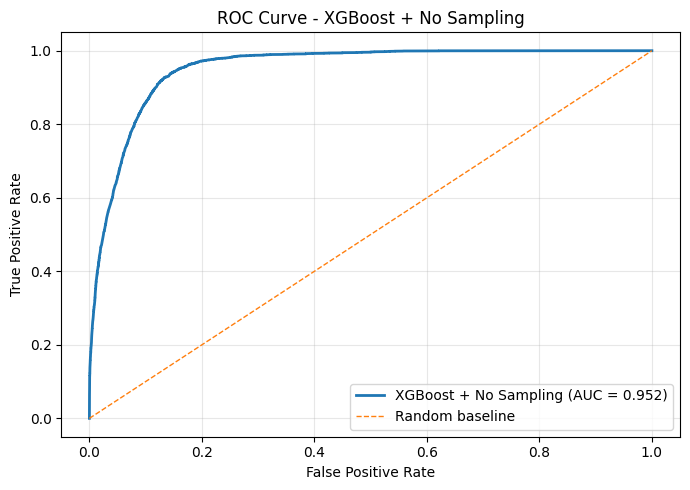


DECILE TABLE — XGBOOST + NO SAMPLING
Decile  Customers  Positives  Adoption_Rate  Avg_Pred_Prob     Lift  Cumulative_Positives  Cumulative_Capture
    D1       2550       1997       0.783137       0.781973 5.063083                  1997            0.506467
    D2       2549       1238       0.485681       0.484152 3.139988                  3235            0.820441
    D3       2549        563       0.220871       0.209448 1.427959                  3798            0.963226
    D4       2549         96       0.037662       0.035794 0.243489                  3894            0.987573
    D5       2549         20       0.007846       0.010768 0.050727                  3914            0.992645
    D6       2549         21       0.008239       0.005442 0.053263                  3935            0.997971
    D7       2549          8       0.003138       0.002863 0.020291                  3943            1.000000
    D8       2549          0       0.000000       0.001607 0.000000               

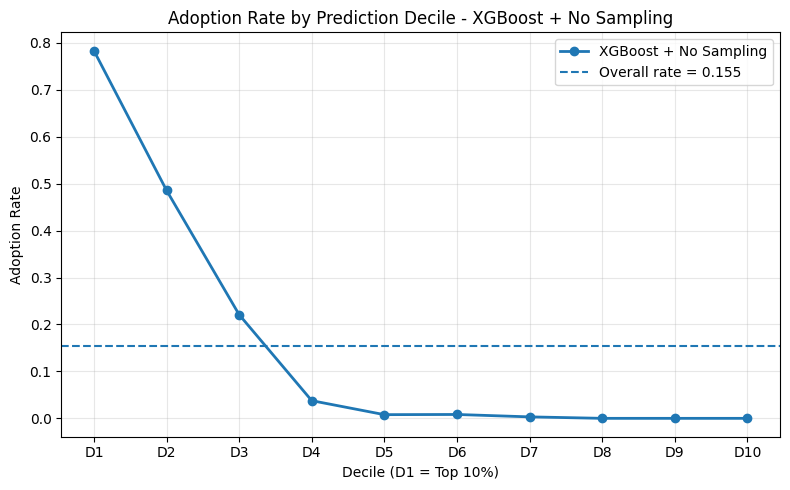

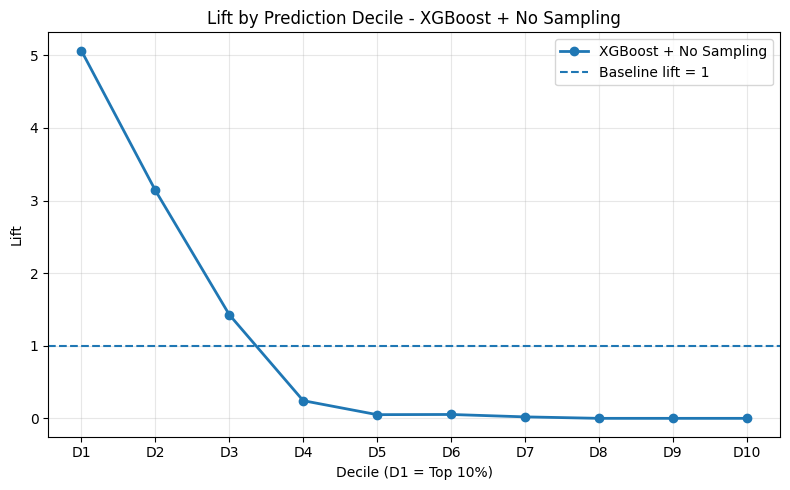


PRECISION@TOP-K — XGBOOST + NO SAMPLING
                Model   Top_K  Customers  Precision  Captured_Positives  Capture_Rate     Lift
XGBoost + No Sampling Top 10%       2550   0.783137                1997      0.506467 5.063083
XGBoost + No Sampling Top 20%       5099   0.634438                3235      0.820441 4.101724
XGBoost + No Sampling Top 30%       7648   0.496600                3798      0.963226 3.210585


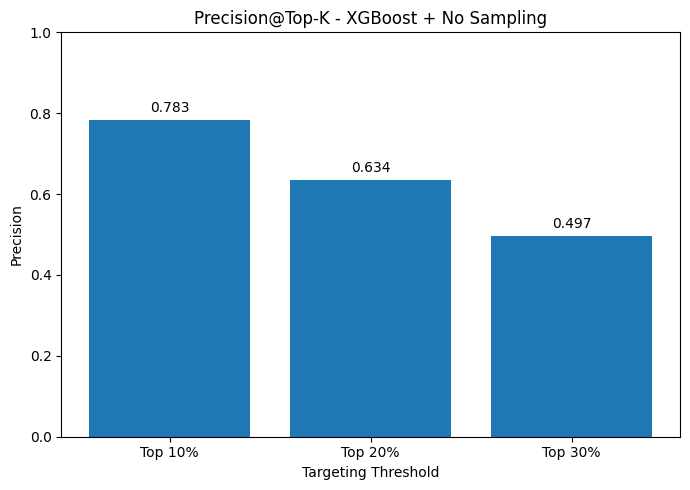


SHAP ANALYSIS — XGBOOST + NO SAMPLING


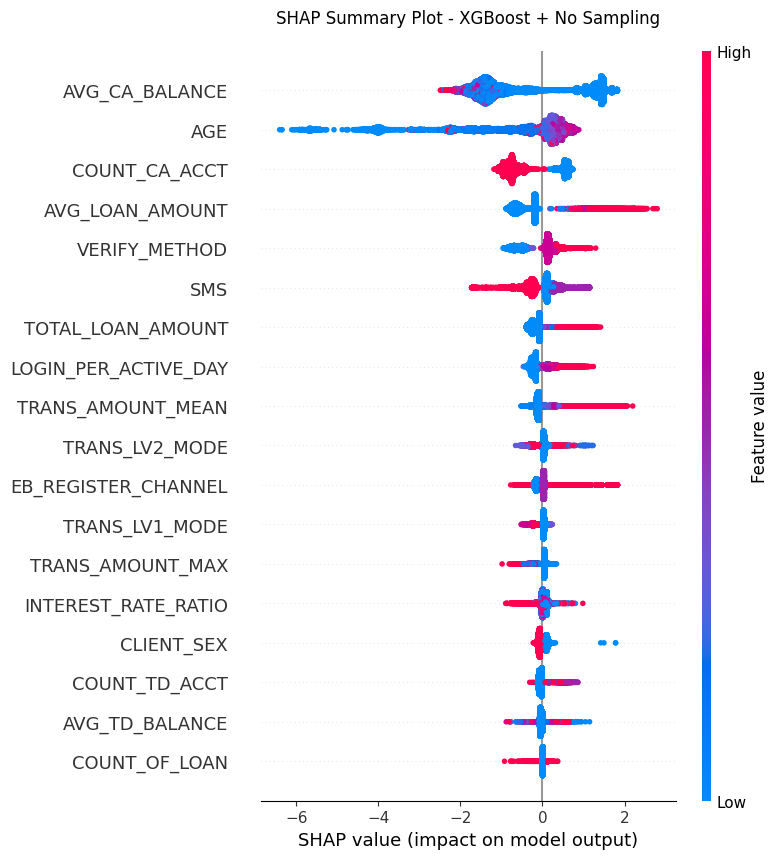

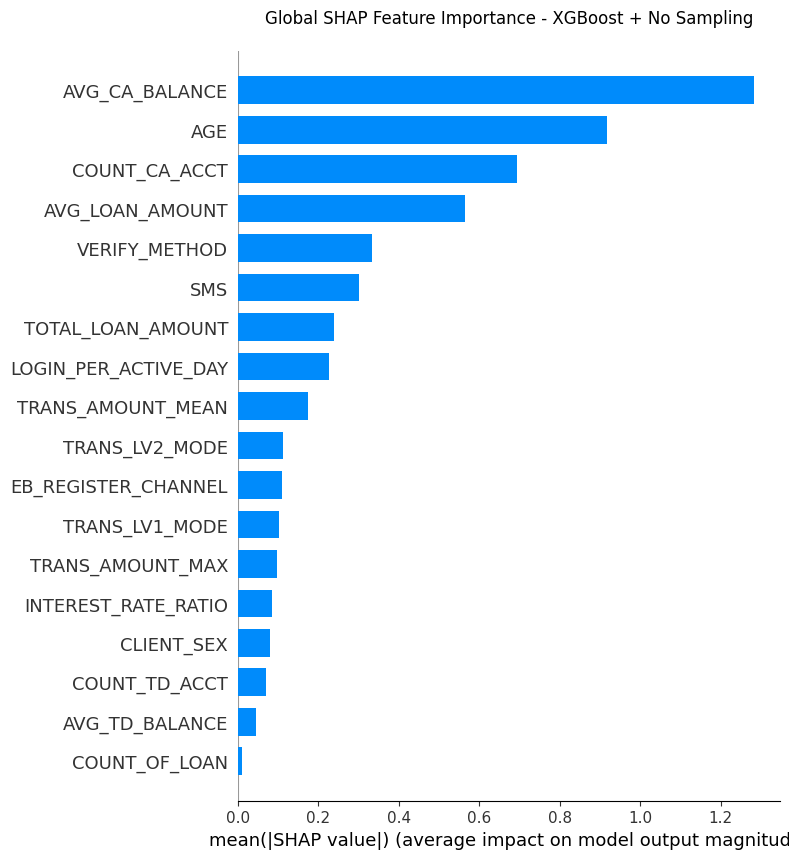


TOP SHAP FEATURES — XGBOOST + NO SAMPLING
             Feature  MeanAbsSHAP
      AVG_CA_BALANCE     1.283094
                 AGE     0.917515
       COUNT_CA_ACCT     0.693374
     AVG_LOAN_AMOUNT     0.563472
       VERIFY_METHOD     0.334291
                 SMS     0.301112
   TOTAL_LOAN_AMOUNT     0.238935
LOGIN_PER_ACTIVE_DAY     0.226094
   TRANS_AMOUNT_MEAN     0.173381
      TRANS_LV2_MODE     0.112691
 EB_REGISTER_CHANNEL     0.110535
      TRANS_LV1_MODE     0.102307
    TRANS_AMOUNT_MAX     0.096076
 INTEREST_RATE_RATIO     0.083639
          CLIENT_SEX     0.081138
       COUNT_TD_ACCT     0.071109
      AVG_TD_BALANCE     0.044443
       COUNT_OF_LOAN     0.010487

Top SHAP feature: AVG_CA_BALANCE


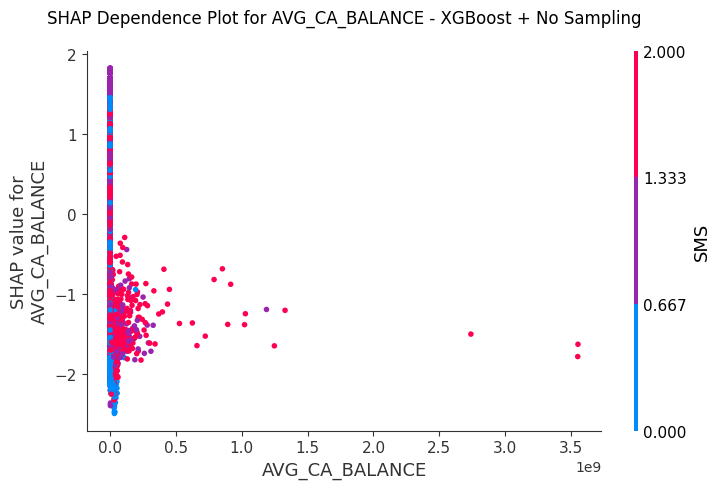


FINAL MODEL SUMMARY

Model      : XGBoost + No Sampling

CV AUC     : 0.9512 ± 0.0015
CV Recall  : 0.6615
CV F1      : 0.6823

Test AUC   : 0.9519
Recall     : 0.6579
Precision  : 0.7072
F1-score   : 0.6816
Accuracy   : 0.9050
Brier      : 0.0622


SAVED FILES

xgboost_no_sampling_cv_results.csv
xgboost_no_sampling_test_results.csv

roc_curve_xgboost_no_sampling.png

decile_table_xgboost_no_sampling.csv
decile_adoption_rate_xgboost_no_sampling.png
decile_lift_xgboost_no_sampling.png

precision_at_k_xgboost_no_sampling.csv
precision_at_k_xgboost_no_sampling.png

shap_summary_xgboost_no_sampling.png
shap_bar_xgboost_no_sampling.png
shap_feature_importance_xgboost_no_sampling.csv

shap_dependence_AVG_CA_BALANCE_xgboost_no_sampling.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier


# =========================================================
# 1. LOAD DATA
# =========================================================

# Dataset ELAPS đã loại AUTO-JOB
df = pd.read_csv(
    "final_dataset_no_auto_job.csv",
    low_memory=False
)

# Nếu dùng file gốc:
# df = pd.read_csv("final_dataset1.csv", low_memory=False)

df.columns = df.columns.str.strip()

# Chuẩn hóa missing values
df = df.replace(
    ["", " ", "NA", "N/A", "na", "null", "NULL", "None", "none"],
    np.nan
)


# =========================================================
# 2. TARGET
# =========================================================

target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

df[target_col] = pd.to_numeric(
    df[target_col],
    errors="coerce"
)

df = df.dropna(
    subset=[target_col]
).copy()

# Binary target:
# 1 = có mở ít nhất một credit card
# 0 = không mở credit card
df[target_col] = (
    df[target_col] > 0
).astype(int)


# =========================================================
# 3. FEATURES
# =========================================================

drop_cols = [
    c for c in [id_col, target_col]
    if c in df.columns
]

X = df.drop(
    columns=drop_cols
).copy()

y = df[target_col].copy()


# =========================================================
# 4. HARMONIZE COLUMN TYPES
# =========================================================

for col in X.columns:

    if X[col].dtype == "object":

        converted = pd.to_numeric(
            X[col],
            errors="coerce"
        )

        non_null_original = X[col].notna().sum()
        non_null_converted = converted.notna().sum()

        # Nếu >=80% dữ liệu có thể chuyển sang numeric
        # thì coi biến này là numeric
        if (
            non_null_original > 0
            and
            (
                non_null_converted
                / non_null_original
            ) >= 0.8
        ):
            X[col] = converted

        else:
            X[col] = X[col].astype("string")


cat_cols = X.select_dtypes(
    include=[
        "object",
        "string",
        "category"
    ]
).columns.tolist()

num_cols = [
    c for c in X.columns
    if c not in cat_cols
]


print("=" * 100)
print("DATA INFORMATION")
print("=" * 100)

print(
    "\nCategorical columns:",
    cat_cols
)

print(
    "\nNumerical columns:",
    num_cols
)

print(
    "\nDataset shape:",
    df.shape
)

print(
    "\nNumber of features:",
    X.shape[1]
)

print(
    "\nTarget counts:"
)
print(
    y.value_counts()
)

print(
    "\nTarget distribution:"
)
print(
    y.value_counts(normalize=True)
)


# =========================================================
# 5. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


print("\n" + "=" * 100)
print("TRAIN / TEST SPLIT")
print("=" * 100)

print(
    "Train size:",
    len(X_train)
)

print(
    "Test size:",
    len(X_test)
)

print(
    f"Train positive rate: {y_train.mean():.4f}"
)

print(
    f"Test positive rate: {y_test.mean():.4f}"
)


# =========================================================
# 6. MODEL: XGBOOST + NO SAMPLING
# =========================================================

model_name = "XGBoost + No Sampling"


def get_xgb_model():

    return XGBClassifier(

        n_estimators=300,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        eval_metric="logloss",

        random_state=42,

        n_jobs=-1
    )


# =========================================================
# 7. PREPROCESS FUNCTION
# =========================================================

def fit_preprocess(
    X_tr,
    X_val,
    cat_cols
):

    X_tr = X_tr.copy()
    X_val = X_val.copy()

    # ------------------------------------------
    # Categorical preprocessing
    # ------------------------------------------

    for col in cat_cols:

        X_tr[col] = X_tr[col].astype(
            "string"
        )

        X_val[col] = X_val[col].astype(
            "string"
        )


    encoder = None

    if len(cat_cols) > 0:

        encoder = OrdinalEncoder(

            handle_unknown="use_encoded_value",

            unknown_value=-1,

            encoded_missing_value=-1
        )

        X_tr[cat_cols] = encoder.fit_transform(
            X_tr[cat_cols]
        )

        X_val[cat_cols] = encoder.transform(
            X_val[cat_cols]
        )


    # ------------------------------------------
    # Missing-value imputation
    # ------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_tr = pd.DataFrame(

        imputer.fit_transform(
            X_tr
        ),

        columns=X_tr.columns,

        index=X_tr.index
    )


    X_val = pd.DataFrame(

        imputer.transform(
            X_val
        ),

        columns=X_val.columns,

        index=X_val.index
    )


    return (
        X_tr,
        X_val,
        imputer,
        encoder
    )


# =========================================================
# 8. CROSS-VALIDATION
#    XGBOOST + NO SAMPLING
# =========================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


recall_scores = []
precision_scores = []
f1_scores = []
auc_scores = []
acc_scores = []
brier_scores = []


print("\n" + "=" * 100)
print("5-FOLD CROSS-VALIDATION — XGBOOST + NO SAMPLING")
print("=" * 100)


for fold, (
    train_idx,
    val_idx
) in enumerate(

    skf.split(
        X_train,
        y_train
    ),

    start=1
):


    # -----------------------------------------------------
    # Fold data
    # -----------------------------------------------------

    X_tr = X_train.iloc[
        train_idx
    ].copy()

    X_val = X_train.iloc[
        val_idx
    ].copy()

    y_tr = y_train.iloc[
        train_idx
    ].copy()

    y_val = y_train.iloc[
        val_idx
    ].copy()


    # -----------------------------------------------------
    # PREPROCESS
    # -----------------------------------------------------

    (
        X_tr_prep,
        X_val_prep,
        _,
        _
    ) = fit_preprocess(

        X_tr,
        X_val,
        cat_cols
    )


    # =====================================================
    # IMPORTANT:
    # NO RANDOM OVERSAMPLING HERE
    #
    # Với ROS trước đây:
    #
    # X_tr_res, y_tr_res =
    #     ros.fit_resample(X_tr_prep, y_tr)
    #
    # Bây giờ train trực tiếp trên original training fold.
    # =====================================================


    # -----------------------------------------------------
    # TRAIN
    # -----------------------------------------------------

    model = get_xgb_model()

    model.fit(
        X_tr_prep,
        y_tr
    )


    # -----------------------------------------------------
    # VALIDATION PREDICTION
    # -----------------------------------------------------

    y_val_prob = model.predict_proba(
        X_val_prep
    )[:, 1]


    y_val_pred = (
        y_val_prob >= 0.5
    ).astype(int)


    # -----------------------------------------------------
    # METRICS
    # -----------------------------------------------------

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )


    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )


    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )


    auc = roc_auc_score(
        y_val,
        y_val_prob
    )


    acc = accuracy_score(
        y_val,
        y_val_pred
    )


    brier = brier_score_loss(
        y_val,
        y_val_prob
    )


    recall_scores.append(
        recall
    )

    precision_scores.append(
        precision
    )

    f1_scores.append(
        f1
    )

    auc_scores.append(
        auc
    )

    acc_scores.append(
        acc
    )

    brier_scores.append(
        brier
    )


    print(
        f"Fold {fold} | "
        f"Recall={recall:.4f} | "
        f"Precision={precision:.4f} | "
        f"F1={f1:.4f} | "
        f"AUC={auc:.4f} | "
        f"Accuracy={acc:.4f} | "
        f"Brier={brier:.4f}"
    )


# =========================================================
# CV SUMMARY
# =========================================================

cv_summary = pd.DataFrame([{

    "Model":
        model_name,

    "CV Recall":
        np.mean(recall_scores),

    "CV Precision":
        np.mean(precision_scores),

    "CV F1-score":
        np.mean(f1_scores),

    "CV AUC":
        np.mean(auc_scores),

    "CV Accuracy":
        np.mean(acc_scores),

    "CV Brier":
        np.mean(brier_scores),

    "Std (CV AUC)":
        np.std(auc_scores),

    "Std (CV Recall)":
        np.std(recall_scores),

    "Std (CV F1)":
        np.std(f1_scores)

}])


print("\n" + "=" * 100)
print("CV RESULTS — XGBOOST + NO SAMPLING")
print("=" * 100)

print(
    cv_summary.to_string(
        index=False
    )
)


cv_summary.to_csv(
    "xgboost_no_sampling_cv_results.csv",
    index=False
)


# =========================================================
# 9. FINAL PREPROCESSING
# =========================================================

(
    X_train_prep,
    X_test_prep,
    final_imputer,
    final_encoder
) = fit_preprocess(

    X_train,
    X_test,
    cat_cols
)


# =========================================================
# 10. FINAL TRAINING
#     NO SAMPLING
# =========================================================

print("\n" + "=" * 100)
print("FINAL TRAINING — XGBOOST + NO SAMPLING")
print("=" * 100)


print(
    "Original training observations:",
    len(X_train_prep)
)

print(
    "Original positives:",
    y_train.sum()
)

print(
    "Original negatives:",
    len(y_train) - y_train.sum()
)

print(
    f"Original positive rate: {y_train.mean():.4f}"
)


# =========================================================
# IMPORTANT:
# KHÔNG fit_resample()
# =========================================================

final_model = get_xgb_model()

final_model.fit(
    X_train_prep,
    y_train
)


# =========================================================
# 11. TEST EVALUATION
# =========================================================

y_test_prob = final_model.predict_proba(
    X_test_prep
)[:, 1]


y_test_pred = (
    y_test_prob >= 0.5
).astype(int)


test_auc = roc_auc_score(
    y_test,
    y_test_prob
)


test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)


test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)


test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)


test_acc = accuracy_score(
    y_test,
    y_test_pred
)


test_brier = brier_score_loss(
    y_test,
    y_test_prob
)


cm = confusion_matrix(
    y_test,
    y_test_pred
)


test_summary = pd.DataFrame([{

    "Model":
        model_name,

    "Test Recall":
        test_recall,

    "Test Precision":
        test_precision,

    "Test F1-score":
        test_f1,

    "Test AUC":
        test_auc,

    "Test Accuracy":
        test_acc,

    "Test Brier":
        test_brier

}])


print("\n" + "=" * 100)
print("TEST RESULTS — XGBOOST + NO SAMPLING")
print("=" * 100)

print(
    test_summary.to_string(
        index=False
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    cm
)


print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)


test_summary.to_csv(
    "xgboost_no_sampling_test_results.csv",
    index=False
)


# =========================================================
# 12. ROC CURVE
# =========================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_prob
)


plt.figure(
    figsize=(7, 5)
)


plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=(
        f"XGBoost + No Sampling "
        f"(AUC = {test_auc:.3f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    linewidth=1,

    label="Random baseline"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - XGBoost + No Sampling"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    "roc_curve_xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# 13. DECILE ANALYSIS
# =========================================================

def create_decile_table(
    y_true,
    y_prob,
    n_groups=10
):


    decile_df = pd.DataFrame({

        "y_true":
            np.asarray(y_true),

        "y_prob":
            np.asarray(y_prob)

    }).sort_values(

        "y_prob",

        ascending=False

    ).reset_index(
        drop=True
    )


    decile_df[
        "Decile"
    ] = pd.qcut(

        decile_df.index + 1,

        q=n_groups,

        labels=[
            f"D{i}"
            for i in range(
                1,
                n_groups + 1
            )
        ]
    )


    decile_summary = (
        decile_df
        .groupby(
            "Decile",
            observed=False
        )
        .agg(

            Customers=(
                "y_true",
                "count"
            ),

            Positives=(
                "y_true",
                "sum"
            ),

            Adoption_Rate=(
                "y_true",
                "mean"
            ),

            Avg_Pred_Prob=(
                "y_prob",
                "mean"
            )

        )
        .reset_index()
    )


    overall_rate = (
        decile_df[
            "y_true"
        ].mean()
    )


    decile_summary[
        "Lift"
    ] = (

        decile_summary[
            "Adoption_Rate"
        ]
        /
        overall_rate
    )


    # Cumulative positives
    decile_summary[
        "Cumulative_Positives"
    ] = (
        decile_summary[
            "Positives"
        ].cumsum()
    )


    total_positive = (
        decile_df[
            "y_true"
        ].sum()
    )


    decile_summary[
        "Cumulative_Capture"
    ] = (

        decile_summary[
            "Cumulative_Positives"
        ]
        /
        total_positive
    )


    return (
        decile_summary,
        overall_rate
    )


decile_table_df, overall_rate = (
    create_decile_table(

        y_test,

        y_test_prob
    )
)


print("\n" + "=" * 100)
print("DECILE TABLE — XGBOOST + NO SAMPLING")
print("=" * 100)

print(
    decile_table_df.to_string(
        index=False
    )
)


decile_table_df.to_csv(

    "decile_table_xgboost_no_sampling.csv",

    index=False
)


# =========================================================
# Adoption Rate by Decile
# =========================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    decile_table_df[
        "Decile"
    ],

    decile_table_df[
        "Adoption_Rate"
    ],

    marker="o",

    linewidth=2,

    label="XGBoost + No Sampling"
)


plt.axhline(

    y=overall_rate,

    linestyle="--",

    label=(
        f"Overall rate = "
        f"{overall_rate:.3f}"
    )
)


plt.xlabel(
    "Decile (D1 = Top 10%)"
)

plt.ylabel(
    "Adoption Rate"
)

plt.title(
    "Adoption Rate by Prediction Decile - "
    "XGBoost + No Sampling"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    "decile_adoption_rate_xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# Lift by Decile
# =========================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    decile_table_df[
        "Decile"
    ],

    decile_table_df[
        "Lift"
    ],

    marker="o",

    linewidth=2,

    label="XGBoost + No Sampling"
)


plt.axhline(

    y=1.0,

    linestyle="--",

    label="Baseline lift = 1"
)


plt.xlabel(
    "Decile (D1 = Top 10%)"
)

plt.ylabel(
    "Lift"
)

plt.title(
    "Lift by Prediction Decile - "
    "XGBoost + No Sampling"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    "decile_lift_xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# 14. PRECISION@TOP-K
# =========================================================

def precision_at_k(
    y_true,
    y_prob,
    top_rates=[
        0.10,
        0.20,
        0.30
    ]
):


    result_df = pd.DataFrame({

        "y_true":
            np.asarray(y_true),

        "y_prob":
            np.asarray(y_prob)

    }).sort_values(

        "y_prob",

        ascending=False

    ).reset_index(
        drop=True
    )


    rows = []

    n = len(
        result_df
    )


    total_positives = (
        result_df[
            "y_true"
        ].sum()
    )


    overall_rate = (
        result_df[
            "y_true"
        ].mean()
    )


    for rate in top_rates:

        k = int(
            np.ceil(
                n * rate
            )
        )


        top_df = (
            result_df
            .iloc[:k]
        )


        precision = (
            top_df[
                "y_true"
            ].mean()
        )


        captured = (
            top_df[
                "y_true"
            ].sum()
        )


        capture_rate = (
            captured
            /
            total_positives
        )


        lift = (
            precision
            /
            overall_rate
        )


        rows.append({

            "Model":
                model_name,

            "Top_K":
                f"Top {int(rate * 100)}%",

            "Customers":
                k,

            "Precision":
                precision,

            "Captured_Positives":
                captured,

            "Capture_Rate":
                capture_rate,

            "Lift":
                lift

        })


    return pd.DataFrame(
        rows
    )


precision_k_df = precision_at_k(

    y_test,

    y_test_prob
)


print("\n" + "=" * 100)
print("PRECISION@TOP-K — XGBOOST + NO SAMPLING")
print("=" * 100)

print(
    precision_k_df.to_string(
        index=False
    )
)


precision_k_df.to_csv(

    "precision_at_k_xgboost_no_sampling.csv",

    index=False
)


# =========================================================
# Precision@K Plot
# =========================================================

plt.figure(
    figsize=(7, 5)
)


plt.bar(

    precision_k_df[
        "Top_K"
    ],

    precision_k_df[
        "Precision"
    ]
)


plt.ylim(
    0,
    1
)

plt.xlabel(
    "Targeting Threshold"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision@Top-K - "
    "XGBoost + No Sampling"
)


for i, v in enumerate(

    precision_k_df[
        "Precision"
    ]
):

    plt.text(

        i,

        v + 0.02,

        f"{v:.3f}",

        ha="center"
    )


plt.tight_layout()


plt.savefig(

    "precision_at_k_xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# 15. SHAP ANALYSIS
# =========================================================

print("\n" + "=" * 100)
print("SHAP ANALYSIS — XGBOOST + NO SAMPLING")
print("=" * 100)


explainer = shap.TreeExplainer(
    final_model
)


shap_values = explainer.shap_values(
    X_test_prep
)


if isinstance(
    shap_values,
    list
):

    shap_values = (
        shap_values[1]
    )


# =========================================================
# SHAP SUMMARY PLOT
# =========================================================

plt.figure()


shap.summary_plot(

    shap_values,

    X_test_prep,

    show=False
)


plt.title(

    "SHAP Summary Plot - "
    "XGBoost + No Sampling",

    pad=20
)


plt.tight_layout()


plt.savefig(

    "shap_summary_xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# SHAP BAR PLOT
# =========================================================

plt.figure()


shap.summary_plot(

    shap_values,

    X_test_prep,

    plot_type="bar",

    show=False
)


plt.title(

    "Global SHAP Feature Importance - "
    "XGBoost + No Sampling",

    pad=20
)


plt.tight_layout()


plt.savefig(

    "shap_bar_xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# 16. MEAN ABSOLUTE SHAP
# =========================================================

mean_abs_shap = (
    np.abs(
        shap_values
    ).mean(
        axis=0
    )
)


shap_importance_df = pd.DataFrame({

    "Feature":
        X_test_prep.columns,

    "MeanAbsSHAP":
        mean_abs_shap

}).sort_values(

    "MeanAbsSHAP",

    ascending=False
)


print("\n" + "=" * 100)
print("TOP SHAP FEATURES — XGBOOST + NO SAMPLING")
print("=" * 100)

print(
    shap_importance_df
    .head(20)
    .to_string(
        index=False
    )
)


shap_importance_df.to_csv(

    "shap_feature_importance_xgboost_no_sampling.csv",

    index=False
)


# =========================================================
# 17. SHAP DEPENDENCE PLOT
# =========================================================

top_feature = (
    shap_importance_df
    .iloc[0][
        "Feature"
    ]
)


print(
    "\nTop SHAP feature:",
    top_feature
)


shap.dependence_plot(

    top_feature,

    shap_values,

    X_test_prep,

    show=False
)


plt.title(

    f"SHAP Dependence Plot for "
    f"{top_feature} - "
    f"XGBoost + No Sampling",

    pad=20
)


plt.tight_layout()


safe_top_feature = str(
    top_feature
).replace(
    "/",
    "_"
).replace(
    " ",
    "_"
)


plt.savefig(

    f"shap_dependence_"
    f"{safe_top_feature}_"
    f"xgboost_no_sampling.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# =========================================================
# 18. FINAL RESULTS SUMMARY
# =========================================================

print("\n" + "=" * 100)
print("FINAL MODEL SUMMARY")
print("=" * 100)


print(
    f"""
Model      : {model_name}

CV AUC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}
CV Recall  : {np.mean(recall_scores):.4f}
CV F1      : {np.mean(f1_scores):.4f}

Test AUC   : {test_auc:.4f}
Recall     : {test_recall:.4f}
Precision  : {test_precision:.4f}
F1-score   : {test_f1:.4f}
Accuracy   : {test_acc:.4f}
Brier      : {test_brier:.4f}
"""
)


# =========================================================
# 19. SAVED FILES
# =========================================================

print("\n" + "=" * 100)
print("SAVED FILES")
print("=" * 100)


print(
    """
xgboost_no_sampling_cv_results.csv
xgboost_no_sampling_test_results.csv

roc_curve_xgboost_no_sampling.png

decile_table_xgboost_no_sampling.csv
decile_adoption_rate_xgboost_no_sampling.png
decile_lift_xgboost_no_sampling.png

precision_at_k_xgboost_no_sampling.csv
precision_at_k_xgboost_no_sampling.png

shap_summary_xgboost_no_sampling.png
shap_bar_xgboost_no_sampling.png
shap_feature_importance_xgboost_no_sampling.csv
"""
)

print(
    f"shap_dependence_{safe_top_feature}_"
    f"xgboost_no_sampling.png"
)

ROBUSTNESS TO DOMINANT FEATURE REMOVAL

In [ ]:
# ============================================================
# HIGH-IMPORTANCE FEATURE ABLATION
# XGBoost + Random Oversampling (ROS)
#
# Dataset:
#   /content/final_dataset_no_auto_job.csv
#
# Target:
#   COUNT_CREDITCARD
#
# Removed ID:
#   CUSTOMER_NUMBER
#
# Scenarios:
#   1. Full Model
#   2. Without AVG_CA_BALANCE
#   3. Without AGE
#   4. Without AVG_CA_BALANCE + AGE
#
# XGBoost configuration:
#   n_estimators      = 300
#   max_depth         = 6
#   learning_rate     = 0.05
#   subsample         = 0.8
#   colsample_bytree  = 0.8
#   eval_metric       = logloss
#   random_state      = 42
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install xgboost imbalanced-learn openpyxl


# ============================================================
# 1. IMPORT
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    roc_curve
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier


# ============================================================
# 2. CONFIGURATION
# ============================================================

INPUT_FILE = "/content/final_dataset_no_auto_job.csv"

TARGET_COL = "COUNT_CREDITCARD"
ID_COL = "CUSTOMER_NUMBER"

RANDOM_STATE = 42
TEST_SIZE = 0.20
THRESHOLD = 0.50

OUTPUT_DIR = "/content/"


# ============================================================
# 3. LOAD DATA
# ============================================================

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}"
    )

df = pd.read_csv(INPUT_FILE)

print("=" * 100)
print("DATA LOADED")
print("=" * 100)

print("Original shape:", df.shape)
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 4. CHECK TARGET
# ============================================================

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Không tìm thấy target: {TARGET_COL}"
    )


# ============================================================
# 5. CREATE BINARY TARGET
# COUNT_CREDITCARD > 0 -> 1
# COUNT_CREDITCARD = 0 -> 0
# ============================================================

target_numeric = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

valid_mask = target_numeric.notna()

df = (
    df.loc[valid_mask]
    .reset_index(drop=True)
)

target_numeric = (
    target_numeric.loc[valid_mask]
    .reset_index(drop=True)
)

y = (
    target_numeric > 0
).astype(int)


# ============================================================
# 6. REMOVE TARGET + CUSTOMER_NUMBER
# ============================================================

X = df.drop(
    columns=[
        TARGET_COL,
        ID_COL
    ],
    errors="ignore"
).copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


print("\n" + "=" * 100)
print("FEATURE MATRIX")
print("=" * 100)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print(
    "\nPositive rate:",
    round(y.mean(), 6)
)

print(
    "\nNumber of predictors:",
    X.shape[1]
)

print("\nPredictors:")
print(X.columns.tolist())


# Safety checks

assert TARGET_COL not in X.columns, \
    "ERROR: COUNT_CREDITCARD còn nằm trong X"

assert ID_COL not in X.columns, \
    "ERROR: CUSTOMER_NUMBER còn nằm trong X"

print("\n✓ COUNT_CREDITCARD used only as target")
print("✓ CUSTOMER_NUMBER removed")


# ============================================================
# 7. CHECK FEATURES USED IN ABLATION
# ============================================================

required_features = [
    "AVG_CA_BALANCE",
    "AGE"
]

for col in required_features:

    if col not in X.columns:
        raise ValueError(
            f"Không tìm thấy feature: {col}"
        )

print("\n✓ AVG_CA_BALANCE found")
print("✓ AGE found")


# ============================================================
# 8. DEFINE CATEGORICAL FEATURES
# ============================================================

FORCED_CATEGORICAL = [
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE"
]

categorical_cols = [
    c
    for c in FORCED_CATEGORICAL
    if c in X.columns
]

numeric_cols = [
    c
    for c in X.columns
    if c not in categorical_cols
]


# ============================================================
# 9. CLEAN DATA TYPES
# ============================================================

for col in numeric_cols:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


for col in categorical_cols:

    X[col] = (
        X[col]
        .fillna("MISSING")
        .astype(str)
    )


print("\nCategorical features:")
print(categorical_cols)

print("\nNumeric features:")
print(numeric_cols)


# ============================================================
# 10. FIXED TRAIN / TEST SPLIT
# SAME SPLIT FOR ALL SCENARIOS
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)


print("\n" + "=" * 100)
print("TRAIN / TEST SPLIT")
print("=" * 100)

print("Train shape:", X_train_raw.shape)
print("Test shape :", X_test_raw.shape)

print(
    "Train positive rate:",
    round(y_train.mean(), 6)
)

print(
    "Test positive rate:",
    round(y_test.mean(), 6)
)


# ============================================================
# 11. PREPROCESSOR
# ============================================================

def make_preprocessor(feature_list):

    current_numeric = [
        c
        for c in feature_list
        if c in numeric_cols
    ]

    current_categorical = [
        c
        for c in feature_list
        if c in categorical_cols
    ]

    # Numeric
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )

    # Categorical
    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    transformers = []

    if len(current_numeric) > 0:

        transformers.append(
            (
                "num",
                numeric_pipeline,
                current_numeric
            )
        )

    if len(current_categorical) > 0:

        transformers.append(
            (
                "cat",
                categorical_pipeline,
                current_categorical
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )


# ============================================================
# 12. XGBOOST MODEL
# EXACT CONFIGURATION USED IN THE STUDY
# ============================================================

def make_model():

    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


print("\n✓ make_model() created successfully")


# ============================================================
# 13. KS STATISTIC
# ============================================================

def calc_ks(
    y_true,
    y_prob
):

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    return np.max(
        tpr - fpr
    )


# ============================================================
# 14. CAPACITY / TOP-K METRICS
# ============================================================

def calc_top_k(
    y_true,
    y_prob,
    fraction
):

    tmp = pd.DataFrame({
        "actual": np.asarray(y_true),
        "prob": np.asarray(y_prob)
    })

    tmp = (
        tmp
        .sort_values(
            "prob",
            ascending=False
        )
        .reset_index(drop=True)
    )

    n_top = int(
        np.ceil(
            len(tmp) * fraction
        )
    )

    top = tmp.iloc[:n_top]

    # Precision@K
    precision_k = (
        top["actual"].mean()
    )

    # Base positive rate
    base_rate = (
        tmp["actual"].mean()
    )

    # Lift@K
    if base_rate > 0:

        lift_k = (
            precision_k /
            base_rate
        )

    else:

        lift_k = np.nan

    # Capture@K
    total_positive = (
        tmp["actual"].sum()
    )

    if total_positive > 0:

        capture_k = (
            top["actual"].sum()
            /
            total_positive
        )

    else:

        capture_k = np.nan

    return (
        precision_k,
        capture_k,
        lift_k
    )


# ============================================================
# 15. ABLATION SCENARIOS
# ============================================================

SCENARIOS = {

    "Full Model": [],

    "Without AVG_CA_BALANCE": [
        "AVG_CA_BALANCE"
    ],

    "Without AGE": [
        "AGE"
    ],

    "Without AVG_CA_BALANCE + AGE": [
        "AVG_CA_BALANCE",
        "AGE"
    ]
}


print("\n" + "=" * 100)
print("SCENARIOS")
print("=" * 100)

for setting, drop_cols in SCENARIOS.items():

    print(
        setting,
        "->",
        drop_cols
    )


# ============================================================
# 16. RUN ONE SCENARIO
# ============================================================

def run_scenario(
    setting,
    drop_features
):

    print("\n")
    print("=" * 110)
    print("RUNNING:", setting)
    print("=" * 110)

    # --------------------------------------------------------
    # Select feature subset
    # --------------------------------------------------------

    selected_features = [
        c
        for c in X.columns
        if c not in drop_features
    ]

    print(
        "No. Features:",
        len(selected_features)
    )

    print(
        "Dropped:",
        drop_features
        if len(drop_features) > 0
        else "None"
    )

    X_train = (
        X_train_raw[
            selected_features
        ].copy()
    )

    X_test = (
        X_test_raw[
            selected_features
        ].copy()
    )


    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    preprocessor = make_preprocessor(
        selected_features
    )

    X_train_proc = (
        preprocessor
        .fit_transform(
            X_train
        )
    )

    X_test_proc = (
        preprocessor
        .transform(
            X_test
        )
    )

    print(
        "Processed dimension:",
        X_train_proc.shape[1]
    )


    # --------------------------------------------------------
    # RANDOM OVERSAMPLING
    # ONLY ON TRAINING DATA
    # --------------------------------------------------------

    ros = RandomOverSampler(
        random_state=RANDOM_STATE
    )

    X_train_ros, y_train_ros = (
        ros.fit_resample(
            X_train_proc,
            y_train
        )
    )

    print(
        "Train after ROS:",
        X_train_ros.shape
    )

    print(
        "Positive rate after ROS:",
        round(
            np.mean(y_train_ros),
            4
        )
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model = make_model()

    model.fit(
        X_train_ros,
        y_train_ros
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_prob = (
        model.predict_proba(
            X_test_proc
        )[:, 1]
    )

    y_pred = (
        y_prob >= THRESHOLD
    ).astype(int)


    # --------------------------------------------------------
    # Standard metrics
    # --------------------------------------------------------

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    ks = calc_ks(
        y_test,
        y_prob
    )


    # --------------------------------------------------------
    # Top 10%
    # --------------------------------------------------------

    p10, c10, l10 = calc_top_k(
        y_test,
        y_prob,
        0.10
    )


    # --------------------------------------------------------
    # Top 20%
    # --------------------------------------------------------

    p20, c20, l20 = calc_top_k(
        y_test,
        y_prob,
        0.20
    )


    # --------------------------------------------------------
    # Top 30%
    # --------------------------------------------------------

    p30, c30, l30 = calc_top_k(
        y_test,
        y_prob,
        0.30
    )


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    result = {

        "Setting":
            setting,

        "No. Features":
            len(selected_features),

        "AUC":
            auc,

        "Recall":
            recall,

        "Precision":
            precision,

        "F1":
            f1,

        "Accuracy":
            accuracy,

        "Brier":
            brier,

        "KS":
            ks,

        "Precision@10%":
            p10,

        "Capture@10%":
            c10,

        "Lift@D1":
            l10,

        "Precision@20%":
            p20,

        "Capture@20%":
            c20,

        "Lift@20%":
            l20,

        "Precision@30%":
            p30,

        "Capture@30%":
            c30,

        "Lift@30%":
            l30
    }


    print("\nRESULT")

    for key, value in result.items():

        if isinstance(
            value,
            (float, np.floating)
        ):

            print(
                f"{key:20s}: "
                f"{value:.6f}"
            )

        else:

            print(
                f"{key:20s}: "
                f"{value}"
            )


    return result


# ============================================================
# 17. RUN ALL FOUR SCENARIOS
# ============================================================

results = []

for setting, drops in SCENARIOS.items():

    result = run_scenario(
        setting,
        drops
    )

    results.append(
        result
    )


# ============================================================
# 18. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 130)
print("HIGH-IMPORTANCE FEATURE ABLATION RESULTS")
print("=" * 130)

display(
    results_df.round(4)
)


# ============================================================
# 19. CALCULATE DELTA AGAINST FULL MODEL
# ============================================================

baseline = results_df.iloc[0]

delta_metrics = [

    "AUC",
    "Recall",
    "F1",
    "Accuracy",
    "Brier",
    "KS",

    "Precision@10%",
    "Capture@10%",
    "Lift@D1",

    "Precision@20%",
    "Capture@20%",
    "Lift@20%",

    "Precision@30%",
    "Capture@30%",
    "Lift@30%"
]


for metric in delta_metrics:

    results_df[
        "Δ" + metric
    ] = (
        results_df[metric]
        -
        baseline[metric]
    )


# ============================================================
# 20. PAPER TABLE
# 3 DECIMAL PLACES
# ============================================================

paper_columns = [

    "Setting",
    "No. Features",
    "AUC",
    "Recall",
    "F1",
    "KS",
    "Precision@10%",
    "Lift@D1"
]


paper_table = (
    results_df[
        paper_columns
    ].copy()
)


paper_display = (
    paper_table.copy()
)


for col in [

    "AUC",
    "Recall",
    "F1",
    "KS",
    "Precision@10%",
    "Lift@D1"

]:

    paper_display[col] = (
        paper_display[col]
        .map(
            lambda x:
            f"{x:.3f}"
        )
    )


print("\n")
print("=" * 115)
print("TABLE FOR MANUSCRIPT")
print("=" * 115)

print(
    paper_display.to_string(
        index=False
    )
)


# ============================================================
# 21. DELTA TABLE
# ============================================================

delta_table = results_df[
    [
        "Setting",
        "ΔAUC",
        "ΔRecall",
        "ΔF1",
        "ΔKS",
        "ΔPrecision@10%",
        "ΔLift@D1"
    ]
].copy()


for col in delta_table.columns[1:]:

    delta_table[col] = (
        delta_table[col]
        .map(
            lambda x:
            f"{x:+.4f}"
        )
    )


print("\n")
print("=" * 115)
print("CHANGE RELATIVE TO FULL MODEL")
print("=" * 115)

print(
    delta_table.to_string(
        index=False
    )
)


# ============================================================
# 22. EXPORT CSV
# ============================================================

raw_csv = os.path.join(
    OUTPUT_DIR,
    "high_importance_ablation_xgboost_ros_raw.csv"
)

formatted_csv = os.path.join(
    OUTPUT_DIR,
    "high_importance_ablation_xgboost_ros_formatted.csv"
)


results_df.to_csv(
    raw_csv,
    index=False
)

paper_display.to_csv(
    formatted_csv,
    index=False
)


# ============================================================
# 23. EXPORT EXCEL
# ============================================================

excel_file = os.path.join(
    OUTPUT_DIR,
    "high_importance_ablation_xgboost_ros.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    results_df.to_excel(
        writer,
        sheet_name="Raw Results",
        index=False
    )

    paper_display.to_excel(
        writer,
        sheet_name="Paper Table",
        index=False
    )

    delta_table.to_excel(
        writer,
        sheet_name="Delta",
        index=False
    )


# ============================================================
# 24. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 115)
print("FILES EXPORTED")
print("=" * 115)

print(raw_csv)
print(formatted_csv)
print(excel_file)


print("\n")
print("=" * 115)
print("FINAL TABLE FOR MANUSCRIPT")
print("=" * 115)

display(
    paper_display
)

DATA LOADED
Original shape: (127460, 20)
Number of columns: 20

Columns:
['CUSTOMER_NUMBER', 'CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'COUNT_CREDITCARD', 'AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']

FEATURE MATRIX
X shape: (127460, 18)
y shape: (127460,)

Target distribution:
COUNT_CREDITCARD
0    107746
1     19714
Name: count, dtype: int64

Positive rate: 0.154668

Number of predictors: 18

Predictors:
['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'TOTAL_LOAN_AMOUNT']

✓ COUNT_CREDITCARD used only as targe

,Setting,No. Features,AUC,Recall,Precision,F1,Accuracy,Brier,KS,Precision@10%,Capture@10%,Lift@D1,Precision@20%,Capture@20%,Lift@20%,Precision@30%,Capture@30%,Lift@30%
0,Full Model,18,0.9513,0.9328,0.5494,0.6915,0.8713,0.0899,0.7941,0.7820,0.5057,5.0555,0.6333,0.8189,4.0941,0.4963,0.9627,3.2089
1,Without AVG_CA_BALANCE,17,0.9493,0.9282,0.5440,0.6860,0.8685,0.0917,0.7894,0.7749,0.5011,5.0098,0.6307,0.8156,4.0776,0.4954,0.9609,3.2030
2,Without AGE,17,0.9316,0.9409,0.4700,0.6269,0.8268,0.1103,0.7502,0.7357,0.4758,4.7563,0.5701,0.7373,3.6858,0.4792,0.9295,3.0982
3,Without AVG_CA_BALANCE + AGE,16,0.9289,0.9356,0.4668,0.6228,0.8247,0.1119,0.7457,0.7247,0.4687,4.6853,0.5607,0.7251,3.6250,0.4762,0.9237,3.0787




TABLE FOR MANUSCRIPT
                     Setting  No. Features   AUC Recall    F1    KS Precision@10% Lift@D1
                  Full Model            18 0.951  0.933 0.692 0.794         0.782   5.055
      Without AVG_CA_BALANCE            17 0.949  0.928 0.686 0.789         0.775   5.010
                 Without AGE            17 0.932  0.941 0.627 0.750         0.736   4.756
Without AVG_CA_BALANCE + AGE            16 0.929  0.936 0.623 0.746         0.725   4.685


CHANGE RELATIVE TO FULL MODEL
                     Setting    ΔAUC ΔRecall     ΔF1     ΔKS ΔPrecision@10% ΔLift@D1
                  Full Model +0.0000 +0.0000 +0.0000 +0.0000        +0.0000  +0.0000
      Without AVG_CA_BALANCE -0.0020 -0.0046 -0.0056 -0.0047        -0.0071  -0.0456
                 Without AGE -0.0197 +0.0081 -0.0646 -0.0439        -0.0463  -0.2992
Without AVG_CA_BALANCE + AGE -0.0224 +0.0028 -0.0687 -0.0484        -0.0573  -0.3702


FILES EXPORTED
/content/high_importance_ablation_xgboost_ros_raw.csv

,Setting,No. Features,AUC,Recall,F1,KS,Precision@10%,Lift@D1
0,Full Model,18,0.951,0.933,0.692,0.794,0.782,5.055
1,Without AVG_CA_BALANCE,17,0.949,0.928,0.686,0.789,0.775,5.010
2,Without AGE,17,0.932,0.941,0.627,0.750,0.736,4.756
3,Without AVG_CA_BALANCE + AGE,16,0.929,0.936,0.623,0.746,0.725,4.685
